# Stratégie par ticker — avec purge des lots de plus de 2 ans

On ne copie plus des élus : **on note des titres**.

Chaque fin de mois : ce que le Congrès a acheté **net** sur le dernier mois, corroboré par **au moins 2 élus**,
acheté à **poids égaux**, tenu un mois.

**La purge.** Une vente d'une ligne détenue depuis plus de 2 ans n'est pas de l'insider trading : elle ne doit
pas compter comme signal négatif. Le portefeuille des membres est reconstruit **uniquement pour dater les lots vendus**.

| constante | valeur | rôle |
|---|---|---|
| $W$ | 21 j | fenêtre du flux (1 mois) |
| $\bar a$ | 504 j | âge au-delà duquel un lot vendu ne compte plus (2 ans) |
| $b_{\min}$ | 2 | acheteurs distincts exigés |

**Simplifications assumées** : date de **transaction** (donc **borne haute**, non réplicable) · pas de coûts ·
pas de plafond de poids · univers minimal.

## §1 — Le périmètre

In [1]:
import os, warnings
from collections import deque
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
VOL    = f"{RACINE}/00. S3S4 en cours/cache/volume_v1"
FIGS   = f"{RACINE}/00. S3S4 en cours/figs_nb11"
os.makedirs(FIGS, exist_ok=True)

W_REF, A_BAR, B_MIN = 21, 504, 2      # les trois constantes
W = W_REF                              # fenêtre courante (sera choisie en §7.4)
print(f"W = {W} j · ā = {A_BAR} j · b_min = {B_MIN}")

W = 21 j · ā = 504 j · b_min = 2


### 1.1 Choisir le sous-ensemble

**La table est déjà propre** — c'est le produit du pipeline S1/S2 : dédoublonnage, dates réparées,
tickers résolus, montants parsés. **On ne nettoie rien ici.** On choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, sens, milieu de fourchette.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics","flag_late_filing","party"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                             # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]   # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,buy,8000.5,2014-01-02,2014-01-27,False


### 1.2 Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### 1.3 Charger les prix, et re-prouver leur santé

Les garde-fous sont **ceux du 05b/09**, ré-appliqués ici parce que ce notebook est autonome — ce n'est
pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.4) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes.

In [4]:
PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(df.tk.unique()):
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # s_k : exécution τ (FIFO/γ)
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution δ : fenêtrage réplicable (§11)
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### 1.4 Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers est un **sous-ensemble** : actions seules,
2014-2026. L'inclusion doit donc être stricte.

In [6]:
t09 = pd.read_csv(f"{RACINE}/00. S3S4 en cours/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = set(PXV) - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"11 · titres chargés (actions 2014-2026)  : {len(PXV):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
11 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09


### 1.5 Le flux dans le temps

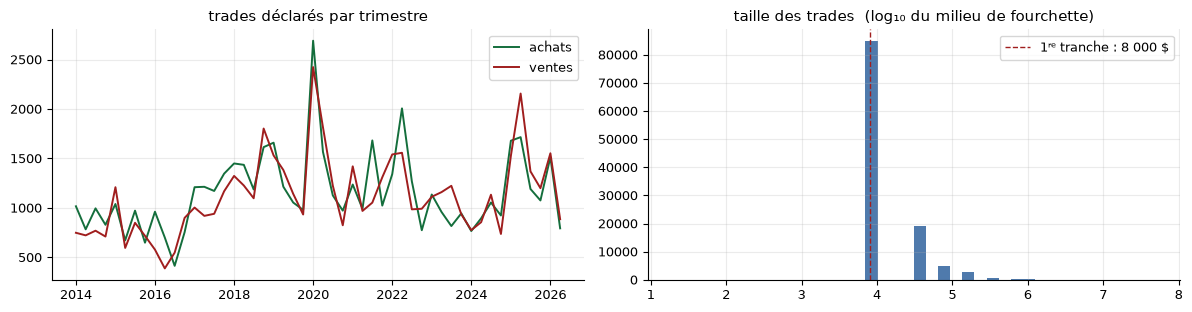

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
m = df.groupby([df.tau.dt.to_period("Q"), "op"]).size().unstack(fill_value=0)
m.index = m.index.to_timestamp()
ax[0].plot(m.index, m.get("buy", 0), color=VERT, lw=1.4, label="achats")
ax[0].plot(m.index, m.get("sell", 0), color=ROUGE, lw=1.4, label="ventes")
ax[0].set_title("trades déclarés par trimestre"); ax[0].legend()
ax[1].hist(np.log10(df.A.clip(lower=1)), bins=40, color=BLEU, alpha=.75)
ax[1].set_title("taille des trades  (log₁₀ du milieu de fourchette)")
ax[1].axvline(np.log10(8000.5), color=ROUGE, ls="--", lw=1, label="1ʳᵉ tranche : 8 000 $")
ax[1].legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/flux.png", dpi=150, bbox_inches="tight"); plt.show()

## §2 — L'univers ticker $\mathcal{U}_t$

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement 0 et risque 0.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # condition (b) : le titre cote DEJA (sa serie a commence) ET cote ENCORE (dernier cours <= 4 j)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4
mort = sum(1 for tk in PXV if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV):,} ({mort/len(PXV):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


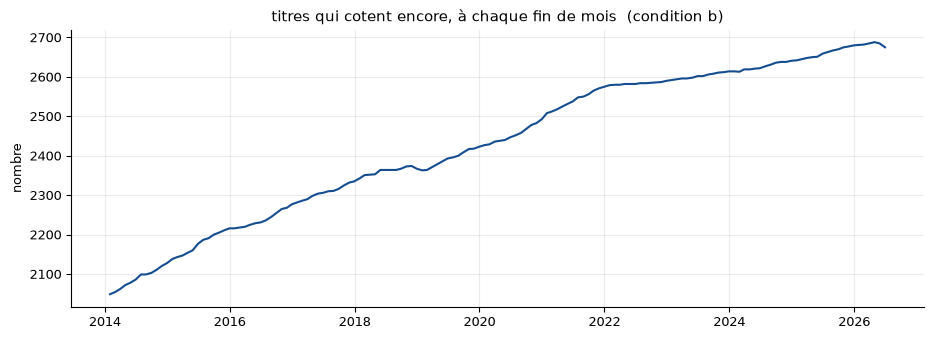

150 coupes mensuelles · 2014-01-31 → 2026-06-30


In [9]:
# les coupes commencent avec la donnée : premier mois de 2014, pas le début du calendrier de prix
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if W <= i < len(cal) - 1))
viv = [sum(vivant(tk, i) for tk in PXV) for i in coupes]
plt.plot([cal[i] for i in coupes], viv, color=BLEU, lw=1.5)
plt.title("titres qui cotent encore, à chaque fin de mois  (condition b)"); plt.ylabel("nombre"); plt.savefig(f"{FIGS}/univers.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")

## §3 — Le portefeuille des membres, pour dater les lots

Il **ne sert qu'à ça**. Par couple (membre, titre), file **FIFO** : un achat empile un lot
$(s_k,\, q_k)$ avec $q_k = A_k / P_{i_k}(s_k)$ ; une vente consomme les lots **les plus anciens**.

Chaque tranche $\ell$ consommée par la vente $k$ a été détenue
$$h_\ell \;=\; \#\bigl(\mathcal{C} \cap (\,s_\ell,\; s_k\,]\bigr) \quad \text{jours de bourse.}$$

In [10]:
def tranches_vendues(g):
    # pour chaque vente : la liste des (h, q) consommés, et la part non appariée
    lots, out = deque(), {}
    for idx, i0, op, A in zip(g.index.values, g.i0.values, g.op.values, g.A.values):
        p = PXV[g.tk.iat[0]][i0]
        if not np.isfinite(p) or p <= 0: continue
        q = A / p
        if op == "buy":
            lots.append([i0, q])
        else:
            reste, pieces = q, []
            while reste > 1e-12 and lots:
                s0, q0 = lots[0]
                pris = min(reste, q0); reste -= pris; lots[0][1] -= pris
                pieces.append((i0 - s0, pris))          # (h, q)
                if lots[0][1] <= 1e-12: lots.popleft()
            out[idx] = (pieces, reste)                  # reste = part non appariée
    return out

In [11]:
VENTES = {}
for (_, _), g in df.groupby(["bioguide_id","tk"], sort=False):
    VENTES.update(tranches_vendues(g))
n_v = (df.op == "sell").sum()
print(f"ventes traitées : {len(VENTES):,} / {n_v:,}")

ventes traitées : 55,061 / 55,924


### 3.1 Validation — un cas recalculé à la main, hors moteur

In [12]:
# on prend un membre×titre avec au moins 1 achat puis 1 vente
cand = (df.assign(b=(df.op=="buy").astype(int), s=(df.op=="sell").astype(int))
          .groupby(["bioguide_id","tk"])[["b","s"]].sum().query("b>=2 and s>=1"))
bid, tk = cand.index[0]
g = df[(df.bioguide_id == bid) & (df.tk == tk)]
print(f"{g.member_name.iat[0]} — {tk}")
display(g[["tau","op","A","i0"]])

# recalcul manuel
lots_m, res_m = [], {}
for idx, i0, op, A in zip(g.index, g.i0, g.op, g.A):
    q = A / PXV[tk][i0]
    if op == "buy": lots_m.append([i0, q])
    else:
        reste, pcs = q, []
        while reste > 1e-12 and lots_m:
            s0, q0 = lots_m[0]
            pris = min(reste, q0); reste -= pris; lots_m[0][1] -= pris
            pcs.append((i0 - s0, pris))
            if lots_m[0][1] <= 1e-12: lots_m.pop(0)
        res_m[idx] = (pcs, reste)
ok = all(np.allclose([x[0] for x in res_m[i][0]], [x[0] for x in VENTES[i][0]]) and
         np.allclose([x[1] for x in res_m[i][0]], [x[1] for x in VENTES[i][0]]) for i in res_m)
print(f"\n✅ recalcul manuel identique au moteur : {ok}")
for i in res_m: print(f"   vente {i} → tranches (h en jours, parts) : "
                      f"{[(int(h), round(q,2)) for h,q in res_m[i][0]]} · non apparié {res_m[i][1]:.2f}")

Richard W. Allen — ABT


,tau,op,A,i0
46306,2019-09-13,buy,32500.5,1936
46562,2019-09-27,buy,32500.5,1946
112088,2026-04-16,sell,32500.5,3591



✅ recalcul manuel identique au moteur : True
   vente 112088 → tranches (h en jours, parts) : [(1655, np.float64(340.43))] · non apparié 0.00


### 3.2 Les durées de détention observées

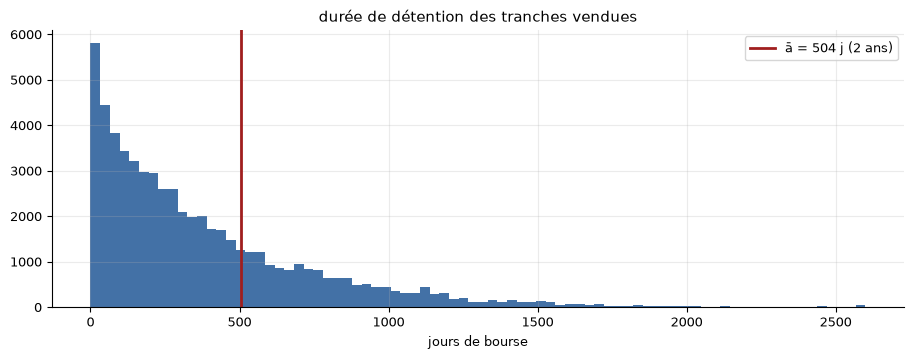

tranches vendues : 59,963 · médiane 268 j · part détenue > 2 ans : 27.3%


In [13]:
H = np.concatenate([[h for h, _ in p] for p, _ in VENTES.values() if p]) if VENTES else np.array([])
plt.hist(np.clip(H, 0, 2600), bins=80, color=BLEU, alpha=.8)
plt.axvline(A_BAR, color=ROUGE, lw=2, label=f"ā = {A_BAR} j (2 ans)")
plt.title("durée de détention des tranches vendues"); plt.xlabel("jours de bourse"); plt.legend(); plt.savefig(f"{FIGS}/durees.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"tranches vendues : {len(H):,} · médiane {np.median(H):.0f} j · "
      f"part détenue > 2 ans : {(H > A_BAR).mean():.1%}")

## §4 — La purge $\gamma$

$$\gamma_k \;=\; \frac{\sum_{\ell \subset k} \mathbf{1}\{h_\ell \le \bar a\}\, q_\ell}{\sum_{\ell \subset k} q_\ell}
\;\in\; [0,1]$$

= la part de la vente $k$ portant sur des lots détenus **moins de 2 ans**.

**achat $\Rightarrow \gamma_k = 1$** (un lot neuf n'a pas d'histoire) · **vente non appariée $\Rightarrow \gamma = 1$**
(on ne peut pas la dater, on ne l'invente pas vieille).

In [14]:
gam = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune = sum(q for h, q in pieces if h <= A_BAR) + reste     # le non apparié est conservé
    gam[idx] = jeune / tot
df["gamma"] = gam
v = df[df.op == "sell"]
print(f"ventes : γ = 1 (intactes) {100*(v.gamma > .999).mean():.1f}% · "
      f"γ = 0 (supprimées) {100*(v.gamma < .001).mean():.1f}% · "
      f"partielles {100*((v.gamma >= .001) & (v.gamma <= .999)).mean():.1f}%")
print(f"masse vendue conservée : {100*(v.A*v.gamma).sum()/v.A.sum():.1f}% des {v.A.sum()/1e9:.2f} Md$ déclarés")

ventes : γ = 1 (intactes) 79.9% · γ = 0 (supprimées) 17.1% · partielles 3.1%
masse vendue conservée : 89.5% des 2.11 Md$ déclarés


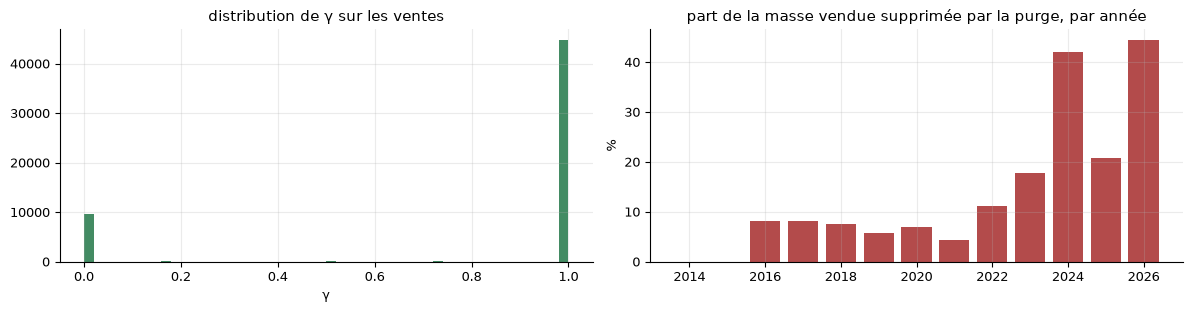

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].hist(v.gamma, bins=50, color=VERT, alpha=.8)
ax[0].set_title("distribution de γ sur les ventes"); ax[0].set_xlabel("γ")
part = v.assign(an=v.tau.dt.year).groupby("an").apply(lambda x: (x.A*x.gamma).sum()/x.A.sum())
ax[1].bar(part.index, 100*(1-part.values), color=ROUGE, alpha=.8)
ax[1].set_title("part de la masse vendue supprimée par la purge, par année"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig(f"{FIGS}/gamma.png", dpi=150, bbox_inches="tight"); plt.show()

## §5 — Le flux par ticker

$$\mathcal{K}_{i,t}(W) = \{\, k : i_k = i,\; t - W < s_k \le t \,\}$$
$$Buy_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k \mathbf{1}\{d_k = +1\}
\qquad
Sell^{\varphi}_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k\, \gamma_k\, \mathbf{1}\{d_k = -1\}$$
$$NetBuy^{\varphi}_{i,t} = \bigl[\, Buy_{i,t} - Sell^{\varphi}_{i,t} \,\bigr]^{+}
\qquad
nBuyers_{i,t} = \#\{\, m_k : k \in \mathcal{K}_{i,t},\; d_k = +1 \,\}$$

In [16]:
df["sgn"] = np.where(df.op == "buy", 1.0, -1.0)
df["Aeff"] = df.A * np.where(df.op == "buy", 1.0, df.gamma)     # A_k · γ_k pour les ventes
ordre = np.argsort(df.i0.values, kind="stable")
I0 = df.i0.values[ordre]
IW, ordreW = I0, ordre        # index de FENÊTRAGE — τ par défaut ; bascule sur δ au §11

def flux(i1, W=None):
    W = W or W_REF
    # le panel (Buy, Sell^phi, NetBuy^phi, nBuyers) a la coupe d'indice i1
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    if not len(g): return pd.DataFrame(columns=["Buy","Sell","NetBuy","nBuyers"])
    buy, sell = g[g.op == "buy"], g[g.op == "sell"]
    sell_r = sell[sell.gamma > 0]                                    # ventes de stock récent (γ>0)
    p = pd.DataFrame({"Buy":     buy.groupby("tk").A.sum(),
                      "Sell":    sell.groupby("tk").Aeff.sum(),      # Aeff = A·γ (purgé)
                      "nBuyers": buy.groupby("tk").bioguide_id.nunique(),
                      "nSellers":sell_r.groupby("tk").bioguide_id.nunique()}).fillna(0.0)
    p["NetBuy"] = (p.Buy - p.Sell).clip(lower=0)                     # long : partie positive
    p["Net"]    = p.Buy - p.Sell                                     # signé : peut être < 0
    return p[["Buy","Sell","NetBuy","Net","nBuyers","nSellers"]]

In [17]:
i_demo = coupes[len(coupes)//2]
P_demo = flux(i_demo)
print(f"coupe du {cal[i_demo].date()} — {len(P_demo)} titres touchés sur la fenêtre de {W} j")
P_demo.sort_values("NetBuy", ascending=False).head(8).round(0)

coupe du 2020-04-30 — 604 titres touchés sur la fenêtre de 21 j


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AVY,350001.0,8000.0,342000.0,342000.0,1.0,1.0
TRS,207501.0,0.0,207501.0,207501.0,1.0,0.0
WTM,207501.0,0.0,207501.0,207501.0,1.0,0.0
G,207501.0,0.0,207501.0,207501.0,1.0,0.0
CSL,207501.0,0.0,207501.0,207501.0,1.0,0.0
SWK,215002.0,16001.0,199001.0,199001.0,1.0,2.0
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
ALGN,175000.0,8000.0,167000.0,167000.0,1.0,1.0


## §6 — Le signal

$$S_t = \{\, i \in \mathcal{U}_t \;:\; NetBuy^{\varphi}_{i,t} > 0 \;\wedge\; nBuyers_{i,t} \ge b_{\min} = 2 \,\}$$

In [18]:
def selection(i1, W=None):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.NetBuy > 0) & (p.nBuyers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

SEL = {i: selection(i) for i in coupes}
taille = np.array([len(SEL[i]) for i in coupes])
print(f"|S_t| : médiane {np.median(taille):.0f} · q25 {np.percentile(taille,25):.0f} · "
      f"q75 {np.percentile(taille,75):.0f} · min {taille.min()} · max {taille.max()}")
print(f"mois où |S_t| = 0 : {(taille==0).sum()} · où |S_t| < 5 : {(taille<5).sum()} / {len(taille)}")

|S_t| : médiane 28 · q25 19 · q75 44 · min 1 · max 123
mois où |S_t| = 0 : 0 · où |S_t| < 5 : 2 / 150


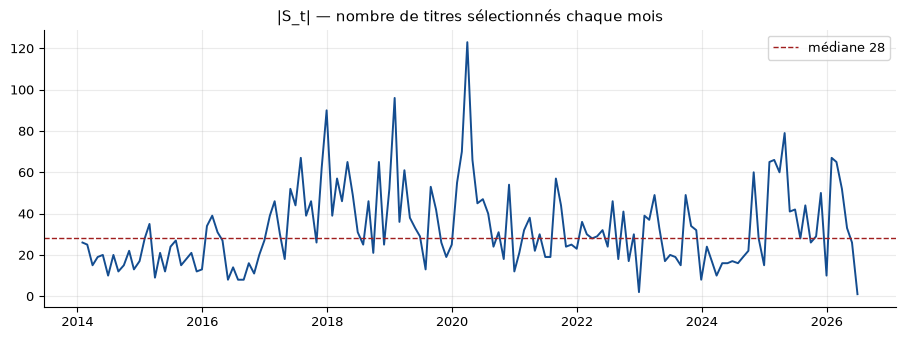

In [19]:
plt.plot([cal[i] for i in coupes], taille, color=BLEU, lw=1.4)
plt.axhline(np.median(taille), color=ROUGE, ls="--", lw=1, label=f"médiane {np.median(taille):.0f}")
plt.title("|S_t| — nombre de titres sélectionnés chaque mois"); plt.legend(); plt.savefig(f"{FIGS}/selection.png", dpi=150, bbox_inches="tight"); plt.show()

In [20]:
print(f"exemple — la sélection du {cal[i_demo].date()} ({len(SEL[i_demo])} titres) :")
P_demo.loc[SEL[i_demo]].sort_values("NetBuy", ascending=False).head(10).round(0)

exemple — la sélection du 2020-04-30 (66 titres) :


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
AON,115502.0,0.0,115502.0,115502.0,2.0,0.0
RHI,115502.0,7733.0,107769.0,107769.0,2.0,1.0
SHEL,91002.0,0.0,91002.0,91002.0,3.0,0.0
RIO,91002.0,0.0,91002.0,91002.0,2.0,0.0
SONY,97003.0,8000.0,89002.0,89002.0,2.0,1.0
VMC,83001.0,0.0,83001.0,83001.0,2.0,0.0
NFLX,123502.0,40501.0,83001.0,83001.0,3.0,2.0
SBGSY,83001.0,0.0,83001.0,83001.0,2.0,0.0


### 6.1 Qui a acheté quoi — la table $B_{m,t}$

Pour pondérer par membre (\S7) il faut, à chaque coupe, **qui** a acheté **quels** titres de $S_t$ :
$$\mathcal{M}_t = \{\, m : m \text{ a acheté au moins un titre de } S_t \,\}, \qquad K_t = |\mathcal{M}_t|$$
$$B_{m,t} = \{\, i \in S_t : m \text{ a acheté } i \text{ dans la fenêtre} \,\}$$

In [21]:
def acheteurs(i1, S, W=None):
    W = W or W_REF
    # rend {membre: [ses tickers de S]} sur la fenêtre de la coupe i1
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "buy") & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

ACH = {i: acheteurs(i, SEL[i]) for i in coupes}
K = np.array([len(ACH[i]) for i in coupes])
print(f"K_t (membres acheteurs) : médiane {np.median(K):.0f} · q25 {np.percentile(K,25):.0f} · "
      f"q75 {np.percentile(K,75):.0f} · min {K.min()} · max {K.max()}")
nB = np.array([len(v) for i in coupes for v in ACH[i].values()])
print(f"|B_m| (titres par membre) : médiane {np.median(nB):.0f} · q90 {np.percentile(nB,90):.0f} · max {nB.max()}")

K_t (membres acheteurs) : médiane 20 · q25 15 · q75 25 · min 2 · max 45
|B_m| (titres par membre) : médiane 2 · q90 8 · max 96


In [22]:
a = ACH[i_demo]
print(f"coupe du {cal[i_demo].date()} — {len(a)} membres acheteurs, {len(SEL[i_demo])} titres retenus\n")
apercu = pd.DataFrame([{"membre": df.loc[df.bioguide_id == m, "member_name"].iat[0],
                        "|B_m|": len(v), "poids par titre": 1/(len(a)*len(v)), "ses titres": ", ".join(v[:5])}
                       for m, v in list(a.items())[:8]])
apercu.round(4)

coupe du 2020-04-30 — 27 membres acheteurs, 66 titres retenus



,membre,|B_m|,poids par titre,ses titres
0,Cindy Axne,1,0.0370,MA
1,Mo Brooks,2,0.0185,"D, DUK"
2,Susan W. Brooks,3,0.0123,"AMZN, MA, QCOM"
3,James E. Banks,1,0.0370,SBUX
4,Thomas R Carper,4,0.0093,"DGX, LHX, QCOM, SBUX"
5,K. Michael Conaway,2,0.0185,"AMZN, DUK"
6,Katherine M. Clark,2,0.0185,"LHX, MOS"
7,Gilbert Cisneros,11,0.0034,"AON, GE, HQY, LHX, LUMN"


## §7 — Le portefeuille : **une voix par membre**

Chaque membre acheteur reçoit $1/K_t$ du capital, puis **répartit sa part également** entre les titres
qu'il a achetés :
$$\boxed{\;w_{i,t} \;=\; \frac{1}{K_t} \sum_{m \in \mathcal{M}_t} \frac{\mathbf{1}\{i \in B_{m,t}\}}{|B_{m,t}|}\;}$$

**Pourquoi ce poids.** Le montant $A_k$ n'y apparaît pas : les 11 M\$ d'un élu fortuné et les 15 k\$ d'un
autre pèsent **exactement $1/K$ chacun**. Le portefeuille cesse d'être piloté par la richesse.

**Trois propriétés, aucun paramètre :**
- $\sum_i w_{i,t} = \frac{1}{K}\sum_m \sum_{i \in B_m} \frac{1}{|B_m|} = \frac{1}{K}\sum_m 1 = 1$ — normalisation automatique
- $|B_m| = 1\ \forall m \Rightarrow w_i \propto b_i$ ; $\;|B_m| = |S_t|\ \forall m \Rightarrow w_i = 1/|S_t|$ (l'équipondéré)
  $\Rightarrow$ la règle se place **seule** entre les deux régimes
- un rééquilibrage de trust sur 133 lignes donne $1/(133K)$ par ligne $\Rightarrow$ **la délégation se dilue toute seule**

**À la coupe** $t_R$, exécution au close du jour suivant, puis buy-and-hold :
$$nbr_i = \frac{V(t_R{+}1)\, w_{i,t_R}}{P_i(t_R{+}1)}, \qquad
V(t) = \sum_{i} nbr_i\, P_i(t), \qquad r(t) = \frac{V(t)}{V(t-1)} - 1$$

In [23]:
def poids(i1, W=None, sel=None, ach=None):
    # w_i = (1/K) * somme_m 1{i dans B_m} / |B_m|   — restreint aux titres priçables à l'exécution
    S = [tk for tk in (sel if sel is not None else SEL[i1]) if np.isfinite(PXV[tk][i1 + 1])]
    if not S: return {}
    Sset = set(S)
    A = ach if ach is not None else ACH[i1]
    B = {m: [tk for tk in v if tk in Sset] for m, v in A.items()}
    B = {m: v for m, v in B.items() if v}
    if not B: return {}
    Kt = len(B)
    w = {}
    for m, v in B.items():
        part = 1.0 / (Kt * len(v))
        for tk in v: w[tk] = w.get(tk, 0.0) + part
    assert abs(sum(w.values()) - 1.0) < 1e-12, f"les poids ne somment pas à 1 : {sum(w.values())}"
    return w

WPO = {i: poids(i) for i in coupes[:-1]}
mx = np.array([max(v.values()) for v in WPO.values() if v])
print(f"poids max par mois : médiane {np.median(mx):.1%} · q90 {np.percentile(mx,90):.1%} · max {mx.max():.1%}")
print(f"mois où une ligne dépasse 10 % : {(mx > .10).sum()} / {len(mx)}  ({(mx > .10).mean():.0%})")

poids max par mois : médiane 11.0% · q90 18.1% · max 50.0%
mois où une ligne dépasse 10 % : 86 / 149  (58%)


In [24]:
def run():
    V = np.full(len(cal), np.nan); nbr = {}
    e0 = coupes[0] + 1
    V[e0] = 100.0
    bornes = [(coupes[j] + 1, coupes[j+1] + 1) for j in range(len(coupes) - 1)]
    for (e, e_next) in bornes:
        w = WPO.get(e - 1, {})                                       # poids « une voix par membre »
        nbr = {tk: V[e] * wi / PXV[tk][e] for tk, wi in w.items()}
        for t in range(e + 1, min(e_next, len(cal) - 1) + 1):
            V[t] = sum(q * PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t - 1]
    out = pd.Series(V, index=cal)
    span = out.loc[out.first_valid_index():out.last_valid_index()]
    assert span.notna().all(), f"trous dans la NAV : {span.isna().sum()} jours"
    return span

V = run()
r = V.pct_change().dropna()
V_ref, r_ref, mx_ref, tail_ref = V.copy(), r.copy(), mx.copy(), taille.copy()   # référence W = 21
print(f"série : {V.index[0].date()} → {V.index[-1].date()} · {len(r):,} jours · NAV finale {V.iloc[-1]:.1f}")

série : 2014-02-03 → 2026-07-01 · 3,120 jours · NAV finale 554.3


### 7.1 Vérification des deux régimes limites (propriété P2)

La formule doit redonner **$w \propto b_i$** si chaque membre n'achète qu'un titre, et **$1/|S_t|$** si
tous achètent tout. On le vérifie numériquement, sur une coupe réelle.

In [25]:
i1 = i_demo; S = [tk for tk in SEL[i1] if np.isfinite(PXV[tk][i1+1])]; Sset = set(S)
B0 = {m: [tk for tk in v if tk in Sset] for m, v in ACH[i1].items()}
B0 = {m: v for m, v in B0.items() if v}

def w_de(B):
    Kt = len(B); w = {}
    for m, v in B.items():
        for tk in v: w[tk] = w.get(tk, 0.0) + 1.0/(Kt*len(v))
    return w

# régime 1 : chaque membre n'achète qu'un titre  →  w ∝ b_i
B1 = {m: [v[0]] for m, v in B0.items()}
w1 = w_de(B1)
b1 = pd.Series({tk: sum(1 for v in B1.values() if tk in v) for tk in w1})
ok1 = np.allclose(pd.Series(w1)[b1.index].values, (b1/b1.sum()).values)

# régime 2 : tous les membres achètent tous les titres  →  w = 1/|S|
B2 = {m: S for m in B0}
w2 = w_de(B2)
ok2 = np.allclose(list(w2.values()), 1.0/len(S))

print(f"régime |B_m| = 1     →  w ∝ b_i      : {ok1}")
print(f"régime B_m = S_t     →  w = 1/|S_t|  : {ok2}   (1/{len(S)} = {1/len(S):.5f})")
assert ok1 and ok2
print("\n✅ la formule niche bien les deux régimes — sans paramètre")

régime |B_m| = 1     →  w ∝ b_i      : True
régime B_m = S_t     →  w = 1/|S_t|  : True   (1/66 = 0.01515)

✅ la formule niche bien les deux régimes — sans paramètre


### 7.2 Ce que la pondération change, concrètement

In [26]:
w_reel = WPO[i_demo]
w_eq = 1/len(w_reel)
cmp = (pd.Series(w_reel).sort_values(ascending=False).to_frame("w (une voix/membre)")
         .assign(**{"w équipondéré": w_eq}))
cmp["rapport"] = cmp.iloc[:,0] / w_eq
print(f"coupe du {cal[i_demo].date()} · {len(w_reel)} titres · équipondéré = {w_eq:.4f}")
cmp.head(8).round(4)

coupe du 2020-04-30 · 66 titres · équipondéré = 0.0152


,w (une voix/membre),w équipondéré,rapport
SBUX,0.0795,0.0152,5.2489
MA,0.0664,0.0152,4.3796
AMZN,0.0533,0.0152,3.5163
ADBE,0.0463,0.0152,3.0556
CINF,0.0407,0.0152,2.6889
TMUS,0.0404,0.0152,2.6667
VSAT,0.0394,0.0152,2.5972
PINS,0.0381,0.0152,2.5163


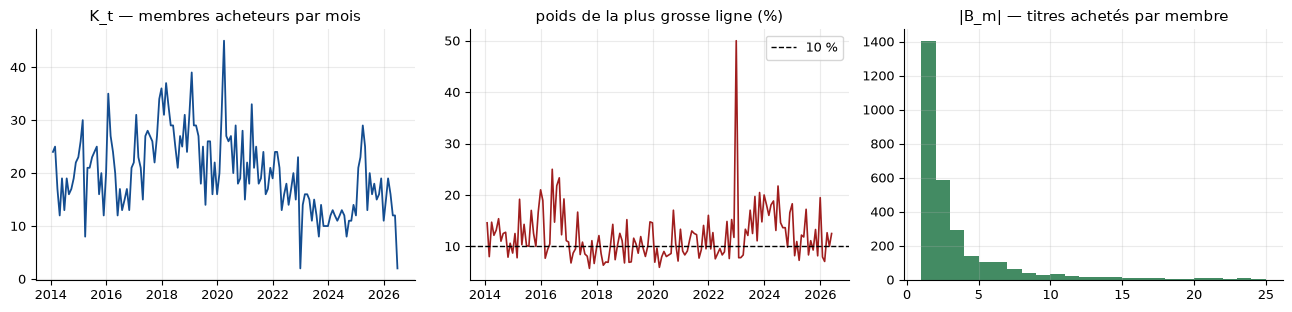

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot([cal[i] for i in coupes], K, color=BLEU, lw=1.3)
ax[0].set_title("K_t — membres acheteurs par mois")
ax[1].plot([cal[i] for i in coupes[:-1]], 100*mx, color=ROUGE, lw=1.2)
ax[1].axhline(10, color="k", ls="--", lw=1, label="10 %"); ax[1].legend()
ax[1].set_title("poids de la plus grosse ligne (%)")
ax[2].hist(nB, bins=range(1, 26), color=VERT, alpha=.8)
ax[2].set_title("|B_m| — titres achetés par membre")
plt.tight_layout(); plt.savefig(f"{FIGS}/poids.png", dpi=150, bbox_inches="tight"); plt.show()

### 7.3 Choisir $W$ — sur la **concentration**, jamais sur le rendement

Avec $W = 21$ j, une ligne dépasse 10 % du portefeuille dans **58 %** des mois (max 50 %) : $K_t$ est trop
petit (médiane 20, minimum 2). On desserre la seule constante qui pilote mécaniquement $K_t$ et $|S_t|$.

**Le critère est annoncé avant de calculer quoi que ce soit sur les rendements :**

$$W^\star \;=\; \min\Bigl\{\, W \in \{21, 42, 63, 126\} \;:\; \mathbb{P}\bigl[\max_i w_{i,t} > 10\,\%\bigr] \le 20\,\% \,\Bigr\}$$

Aucun rendement n'entre dans ce choix — c'est ce qui empêche le balayage de devenir une pêche au résultat.

In [28]:
lignes = []
for Wc in [21, 42, 63, 126]:
    Sc  = {i: selection(i, Wc) for i in coupes}
    Ac  = {i: acheteurs(i, Sc[i], Wc) for i in coupes}
    Wc_ = {i: poids(i, Wc, Sc[i], Ac[i]) for i in coupes[:-1]}
    mxc = np.array([max(v.values()) for v in Wc_.values() if v])
    lignes.append({"W (j)": Wc,
                   "|S_t| médian": int(np.median([len(Sc[i]) for i in coupes])),
                   "K_t médian":   int(np.median([len(Ac[i]) for i in coupes])),
                   "poids max médian": np.median(mxc),
                   "part mois > 10 %": (mxc > .10).mean()})
tabW = pd.DataFrame(lignes).set_index("W (j)")
ok = tabW[tabW["part mois > 10 %"] <= .20]
W_STAR = int(ok.index[0]) if len(ok) else int(tabW["part mois > 10 %"].idxmin())
print(tabW.assign(**{"poids max médian": (100*tabW["poids max médian"]).round(1).astype(str)+" %",
                     "part mois > 10 %": (100*tabW["part mois > 10 %"]).round(0).astype(int).astype(str)+" %"}).to_string())
print(f"\n→ W* = {W_STAR} j" + ("" if len(ok) else "  (aucun ne passe le critère : on prend le moins concentré, et on le dit)"))

       |S_t| médian  K_t médian poids max médian part mois > 10 %
W (j)                                                            
21               28          19           11.0 %             58 %
42               64          32            7.2 %             17 %
63               91          39            6.3 %              9 %
126             156          53            5.4 %              5 %

→ W* = 42 j


In [29]:
W = W_STAR                                          # on rejoue toute la chaîne avec W*
SEL = {i: selection(i, W) for i in coupes}
ACH = {i: acheteurs(i, SEL[i], W) for i in coupes}
WPO = {i: poids(i, W, SEL[i], ACH[i]) for i in coupes[:-1]}
taille = np.array([len(SEL[i]) for i in coupes]); K = np.array([len(ACH[i]) for i in coupes])
mx = np.array([max(v.values()) for v in WPO.values() if v])
V = run(); r = V.pct_change().dropna()
print(f"W = {W} j · |S_t| médian {np.median(taille):.0f} · K_t médian {np.median(K):.0f} · "
      f"poids max médian {np.median(mx):.1%} · mois > 10 % : {(mx>.10).mean():.0%}")
print(f"NAV finale {V.iloc[-1]:.1f}")

W = 42 j · |S_t| médian 64 · K_t médian 32 · poids max médian 7.2% · mois > 10 % : 17%
NAV finale 622.1


### 7.4 Validation — un mois recalculé à la main

In [30]:
j = len(coupes)//2
e, e_next = coupes[j] + 1, coupes[j+1] + 1
w = WPO[e-1]
nbr_m = {tk: V.loc[cal[e]] * wi / PXV[tk][e] for tk, wi in w.items()}
t_test = min(e + 5, e_next)
V_main = sum(q * PXV[tk][t_test] for tk, q in nbr_m.items())
print(f"segment du {cal[e].date()} · {len(w)} titres · Σw = {sum(w.values()):.10f} · "
      f"poids min {min(w.values()):.4f} / max {max(w.values()):.4f}")
print(f"V({cal[t_test].date()})  moteur {V.loc[cal[t_test]]:.4f}   à la main {V_main:.4f}   "
      f"écart {abs(V.loc[cal[t_test]] - V_main):.2e}")
assert abs(V.loc[cal[t_test]] - V_main) < 1e-8
print("✅ identique")

segment du 2020-05-01 · 146 titres · Σw = 1.0000000000 · poids min 0.0006 / max 0.0573
V(2020-05-08)  moteur 197.9369   à la main 197.9369   écart 0.00e+00
✅ identique


## §8 — Le résultat

Deux runs côte à côte : la fenêtre de référence $W = 21$ j, et $W^\star$ retenu par le critère de
concentration. **Ce sont deux essais déclarés**, pas deux chances de trouver un gagnant.

In [31]:
def bilan(Vx, nom):
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(
             pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv",
                         parse_dates=["Date"]).set_index("Date")[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

pd.DataFrame([bilan(V_ref, f"W = {W_REF} j (référence)"), bilan(V, f"W* = {W} j")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
W = 21 j (référence),0.303,0.165,0.059,0.029,1.038,554.284,7/13
W* = 42 j,1.706,1.030,1.048,0.645,1.023,622.132,7/13


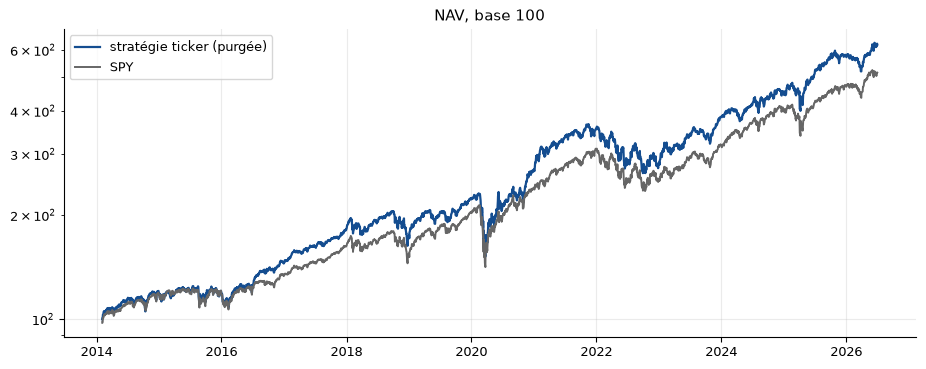

stratégie 622   ·   SPY 517


In [32]:
nav_spy = (1 + r_spy.reindex(V.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(V.index, V, color=BLEU, lw=1.6, label="stratégie ticker (purgée)")
ax.plot(nav_spy.index, nav_spy, color=GRIS, lw=1.4, label="SPY")
ax.set_yscale("log"); ax.set_title("NAV, base 100"); ax.legend(); plt.savefig(f"{FIGS}/nav.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"stratégie {V.iloc[-1]:.0f}   ·   SPY {nav_spy.iloc[-1]:.0f}")

In [33]:
def compose(s): return float((1 + s).prod() - 1)
an = pd.DataFrame({"strat": r.groupby(r.index.year).apply(compose),
                   "spy":   r_spy.reindex(r.index).fillna(0).groupby(r.index.year).apply(compose)})
an["exces"] = an.strat - an.spy
x = an.exces.values
t_x = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
print(f"excès moyen {100*x.mean():+.2f} %/an · t = {t_x:+.2f} · "
      f"années gagnantes {(x>0).sum()}/{len(x)} · seuil t_{len(x)-1} ≈ 1,8")
(100*an).round(1)

excès moyen +1.71 %/an · t = +1.03 · années gagnantes 7/13 · seuil t_12 ≈ 1,8


,strat,spy,exces
Date,,,
2014,19.0,20.3,-1.3
2015,0.4,1.2,-0.9
2016,21.4,12.0,9.4
2017,24.7,21.7,3.0
2018,-3.7,-4.6,0.9
2019,27.9,31.2,-3.4
2020,21.8,18.3,3.5
2021,30.7,28.7,2.0
2022,-21.2,-18.2,-3.1


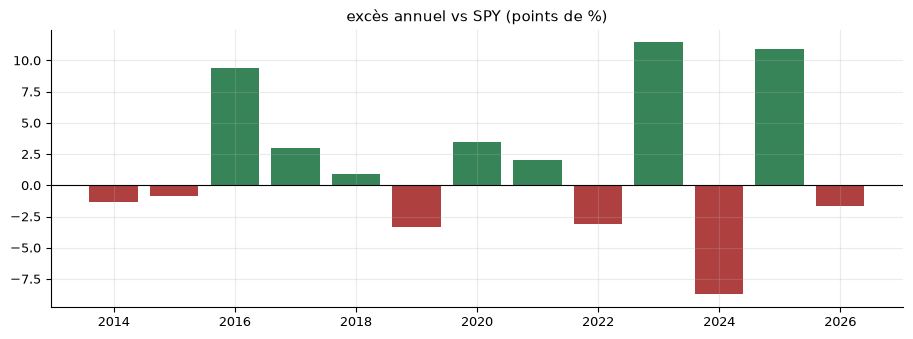

In [34]:
plt.bar(an.index, 100*an.exces, color=[VERT if v > 0 else ROUGE for v in an.exces], alpha=.85)
plt.axhline(0, color="k", lw=.8); plt.title("excès annuel vs SPY (points de %)"); plt.savefig(f"{FIGS}/exces.png", dpi=150, bbox_inches="tight"); plt.show()

In [35]:
ff = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv", parse_dates=["Date"]).set_index("Date")
d = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
y, X = (d.p - d.RF).values, (d.m - d.RF).values
beta, alpha = np.polyfit(X, y, 1)
eps = y - (alpha + beta*X); se = eps.std(ddof=2)
print(f"β = {beta:.3f}   α = {252*alpha*100:+.2f} %/an   "
      f"t_α = {alpha/(se/np.sqrt(len(y))):+.2f}   (marché en excès du taux sans risque)")

β = 1.023   α = +1.05 %/an   t_α = +0.64   (marché en excès du taux sans risque)


## §9 — Diagnostics

ADV des titres sélectionnés — médiane 102 M$/j · part sous 5 M$/j : 5.7%


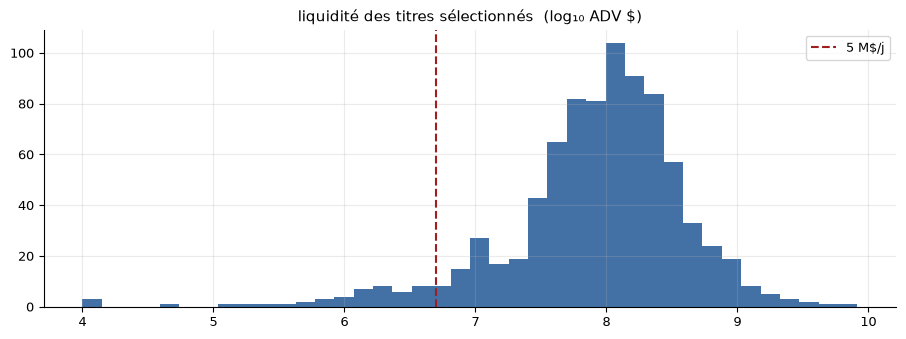

In [36]:
med_adv = {}
for tk in {t for S in SEL.values() for t in S}:
    f = f"{VOL}/{tk}.csv"
    if os.path.exists(f):
        try:
            v = pd.read_csv(f)
            med_adv[tk] = float((v.close_raw * v.volume).median())
        except Exception: pass
adv = pd.Series({tk: med_adv.get(tk, np.nan) for S in SEL.values() for tk in S}).dropna()
print(f"ADV des titres sélectionnés — médiane {adv.median()/1e6:,.0f} M$/j · "
      f"part sous 5 M$/j : {(adv < 5e6).mean():.1%}")
plt.hist(np.log10(adv.clip(lower=1e4)), bins=40, color=BLEU, alpha=.8)
plt.axvline(np.log10(5e6), color=ROUGE, ls="--", label="5 M$/j")
plt.title("liquidité des titres sélectionnés  (log₁₀ ADV $)"); plt.legend(); plt.savefig(f"{FIGS}/adv.png", dpi=150, bbox_inches="tight"); plt.show()

## §10 — Deux extensions : le cap de turnover et la jambe short

Deux ajouts, chacun **niche** l'existant (un réglage neutre redonne le long-only sans cap) :

**(a) Cap de turnover** — on ne réalloue pas d'un coup, on avance *partiellement* vers la cible, d'au plus
$\tau_{\max} = 25\,\%$ par mois :
$$\mathrm{TO}_R = \tfrac12 \sum_i |w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i|,\quad
\lambda_R = \min\!\Bigl(1, \tfrac{\tau_{\max}}{\mathrm{TO}_R}\Bigr),\quad
w^{\mathrm{r\acute ealis\acute e}}_i = w^{\mathrm{d\acute erive}}_i + \lambda_R\,(w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i)$$

**(b) Jambe short** — au lieu de couper à zéro, on garde aussi les titres à flux net **négatif** :
$$S^-_t = \{\, i \in \mathcal U_t : \mathrm{Net}^\varphi_{i,t} < 0 \;\wedge\; nSellers_{i,t} \ge 2 \,\},\qquad
r(t) = r^+(t) - \theta\, r^-(t)$$
$\theta = 0$ redonne le long-only ; $\theta = 1$ = long-short dollar-neutre. *(nSellers ne compte que les vendeurs de stock récent — la purge évite qu'un déstockage de vieux déclenche un short.)*

In [37]:
TAU_MAX = 0.25                                                        # turnover max par mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None):
    # moteur d'UN livre (long ou short) : parts, buy-and-hold, cap de turnover. Rend (NAV, turnovers réalisés)
    # cuts=None → coupes mensuelles (défaut, non-régression) ; on peut passer des coupes hebdo (§14, Quiver)
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du cap, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation
        #    (sinon la NAV chutait à ~50 dès le 1er mois — artefact repéré par Alice sur la courbe B) ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]), comme le run non capé.
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # turnover hors 1er déploiement

In [38]:
# NON-RÉGRESSION : run_livre(WPO, ∞) doit reproduire le long-only validé (§7)
span_ref, _ = run_livre(WPO, np.inf)
assert np.allclose(span_ref.values, V.reindex(span_ref.index).values, atol=1e-9), "run_livre casse la non-régression"
print(f"✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV {span_ref.iloc[-1]:.1f})")

✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV 622.1)


In [39]:
# le livre SHORT : titres net vendus, corroborés par ≥2 vendeurs de stock récent
def selection_short(i1, W):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.Net < 0) & (p.nSellers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

def vendeurs(i1, S, W):                                              # membres qui ont VENDU (γ>0) un titre de S
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "sell") & (g.gamma > 0) & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

SEL_S = {i: selection_short(i, W) for i in coupes}
ACH_S = {i: vendeurs(i, SEL_S[i], W) for i in coupes}
WPO_S = {i: poids(i, W, SEL_S[i], ACH_S[i]) for i in coupes[:-1]}
tS = np.array([len(SEL_S[i]) for i in coupes])
print(f"livre short — |S⁻_t| médian {np.median(tS):.0f} · q25 {np.percentile(tS,25):.0f} · q75 {np.percentile(tS,75):.0f} · "
      f"mois vides {(tS==0).sum()}/{len(tS)}")

livre short — |S⁻_t| médian 45 · q25 30 · q75 65 · mois vides 0/150


In [40]:
# les trois runs : A long sans cap (référence) · B long capé · C long-short capé
spanA, tA  = run_livre(WPO,   np.inf)
spanB, tB  = run_livre(WPO,   TAU_MAX)
spanS, tSt = run_livre(WPO_S, TAU_MAX)
rB = spanB.pct_change(); rS = spanS.pct_change()
idx = rB.index.intersection(rS.index)
rC = (rB.reindex(idx).fillna(0) - 1.0*rS.reindex(idx).fillna(0))     # θ = 1 : long capé − short capé
spanC = 100*(1+rC).cumprod()
print(f"turnover NON capé (long, référence) : médiane {np.median(tA):.1%}  ← ce que le cap ramène à 25 %")
print(f"turnover réalisé/mois — long capé : médiane {np.median(tB):.1%} · short capé : médiane {np.median(tSt):.1%}")

turnover NON capé (long, référence) : médiane 59.2%  ← ce que le cap ramène à 25 %
turnover réalisé/mois — long capé : médiane 25.0% · short capé : médiane 25.0%


In [41]:
tab = pd.DataFrame([bilan(spanA, "A · long, sans cap (référence)"),
                    bilan(spanB, "B · long, cap 25 %"),
                    bilan(spanC, "C · long-short (θ=1), cap 25 %")]).set_index("run")
tab.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"A · long, sans cap (référence)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
"B · long, cap 25 %",0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
"C · long-short (θ=1), cap 25 %",-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13


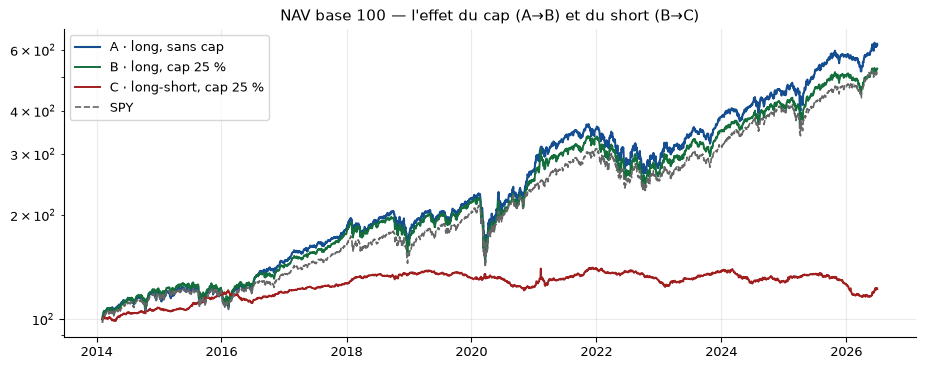

In [42]:
nav_spy2 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=BLEU,  lw=1.5, label="A · long, sans cap")
ax.plot(spanB.index, spanB, color=VERT,  lw=1.4, label="B · long, cap 25 %")
ax.plot(spanC.index, spanC, color=ROUGE, lw=1.4, label="C · long-short, cap 25 %")
ax.plot(nav_spy2.index, nav_spy2, color=GRIS, lw=1.2, ls="--", label="SPY")
ax.set_yscale("log"); ax.set_title("NAV base 100 — l'effet du cap (A→B) et du short (B→C)"); ax.legend()
plt.savefig(f"{FIGS}/extensions.png", dpi=150, bbox_inches="tight"); plt.show()

### §10bis — Deux essais de plus : **short-only** et **β glissant**

**Short-only** : on ne garde QUE la jambe short, sans position longue — on shorte les titres net-vendus.
**β glissant** : au lieu d'un seul β plein-échantillon, on l'estime sur une fenêtre glissante d'un an
pour voir si l'exposition au marché de la base reste collée à ~1 (une mesure, pas une stratégie).

In [43]:
# SHORT-ONLY : le livre short sans cap, dont on prend l'OPPOSÉ du rendement (on parie sur la baisse)
spanS0, _ = run_livre(WPO_S, np.inf)                     # livre short sans cap (comparable à la base A)
rSO = -spanS0.pct_change()                               # shorter = rendement opposé au panier net-vendu
spanSO = 100 * (1 + rSO.fillna(0)).cumprod()
print(f"short-only — NAV finale {spanSO.iloc[-1]:.0f}  (base long {spanA.iloc[-1]:.0f} · SPY {(1+r_spy.reindex(spanA.index).fillna(0)).cumprod().iloc[-1]*100:.0f})")
pd.DataFrame([bilan(spanA,  "base long (τ, réf.)"),
             bilan(spanC,  "long-short (θ=1)"),
             bilan(spanSO, "short-only (τ)")]).set_index("run").round(3)

short-only — NAV finale 16  (base long 622 · SPY 517)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"base long (τ, réf.)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
long-short (θ=1),-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13
short-only (τ),-26.600,-3.395,-2.361,-1.186,-1.028,16.037,3/13


In [44]:
# long-short SANS cap : long sans cap (A) − short sans cap (S0), pour isoler l'effet du cap sur le long-short
rA0, rS0 = spanA.pct_change(), spanS0.pct_change()
ix0 = rA0.index.intersection(rS0.index)
spanC0 = 100 * (1 + (rA0.reindex(ix0).fillna(0) - 1.0*rS0.reindex(ix0).fillna(0))).cumprod()
print("Long-Short (θ=1) à τ — avec vs sans le cap de rotation :")
pd.DataFrame([bilan(spanC,  "long-short · AVEC cap 25 %"),
             bilan(spanC0, "long-short · SANS cap")]).set_index("run").round(3)

Long-Short (θ=1) à τ — avec vs sans le cap de rotation :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
long-short · AVEC cap 25 %,-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13
long-short · SANS cap,-11.308,-2.509,0.570,0.249,-0.006,148.345,4/13


β glissant 252 j — min 0.93 · médiane 1.02 · max 1.11 · plein échantillon 1.02


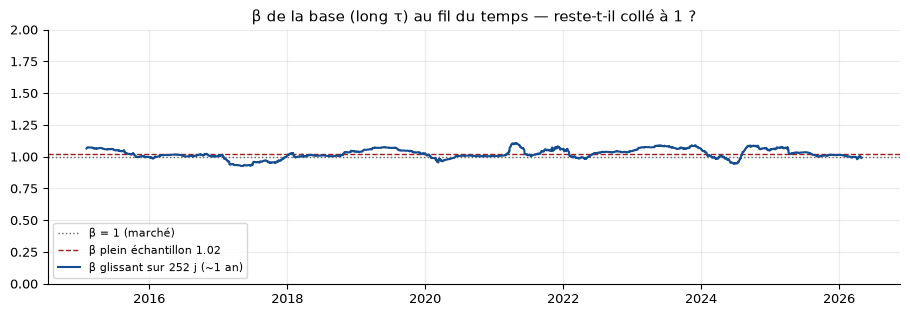

In [45]:
# β GLISSANT de la base (long τ) : β_t = cov(excès strat, excès marché)/var(excès marché) sur 1 an glissant
W_BETA = 252                                             # ~1 an de bourse
rr = spanA.pct_change().dropna()
dd = pd.DataFrame({"p": rr, "m": r_spy.reindex(rr.index)}).join(ff[["RF"]]).dropna()
yb, xb = dd.p - dd.RF, dd.m - dd.RF                      # excès stratégie / excès marché
beta_t = (yb.rolling(W_BETA).cov(xb) / xb.rolling(W_BETA).var()).dropna()
b_full = np.polyfit(xb.values, yb.values, 1)[0]
print(f"β glissant {W_BETA} j — min {beta_t.min():.2f} · médiane {beta_t.median():.2f} · max {beta_t.max():.2f} · plein échantillon {b_full:.2f}")
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.axhline(1.0, color=GRIS, lw=1.0, ls=":", label="β = 1 (marché)")
ax.axhline(b_full, color=ROUGE, lw=1.0, ls="--", label=f"β plein échantillon {b_full:.2f}")
ax.plot(beta_t.index, beta_t, color=BLEU, lw=1.5, label=f"β glissant sur {W_BETA} j (~1 an)")
ax.set_ylim(0, 2); ax.set_title("β de la base (long τ) au fil du temps — reste-t-il collé à 1 ?")
ax.legend(loc="lower left", fontsize=8)
plt.savefig(f"{FIGS}/beta_glissant.png", dpi=150, bbox_inches="tight"); plt.show()

## §11 — Le vrai test : à la date de **divulgation**

Jusqu'ici le flux est fenêtré sur $\tau$ (la transaction) : on utilise une information **avant qu'elle soit
publique** → borne haute. On bascule le fenêtrage sur $\delta$ (la divulgation) : à la coupe $t$, on ne voit
que les trades **déjà divulgués** ($\delta_k \le t$). C'est la version **réplicable**.

Ce qui change : **uniquement la fenêtre du signal**. Le FIFO et $\gamma$ restent sur $\tau$ — la durée de
détention est une réalité, pas une question de date de publication. Exécution toujours au close J+1.

In [46]:
# bascule le fenêtrage sur δ (divulgation), on rebâtit la chaîne longue (sans cap, comparable au run A)
ordre_d = np.argsort(df.ide.values, kind="stable")
IW, ordreW = df.ide.values[ordre_d], ordre_d
SELd = {i: selection(i, W) for i in coupes}
ACHd = {i: acheteurs(i, SELd[i], W) for i in coupes}
WPOd = {i: poids(i, W, SELd[i], ACHd[i]) for i in coupes[:-1]}
td = np.array([len(SELd[i]) for i in coupes])
print(f"à δ — |S_t| médian {np.median(td):.0f} (vs 64 à τ) · mois vides {(td==0).sum()}/{len(td)}")
print(f"lag de divulgation δ−τ : médiane {(df.disclosure_date - df.tau).dt.days.median():.0f} j (le décalage qu'on subit en attendant que l'info soit publique)")
spanD, _ = run_livre(WPOd, np.inf)
IW, ordreW = I0, ordre                                        # on remet τ pour ne rien polluer
print(f"NAV finale — τ (borne haute) {spanA.iloc[-1]:.0f}  ·  δ (réplicable) {spanD.iloc[-1]:.0f}")

à δ — |S_t| médian 59 (vs 64 à τ) · mois vides 0/150
lag de divulgation δ−τ : médiane 27 j (le décalage qu'on subit en attendant que l'info soit publique)
NAV finale — τ (borne haute) 622  ·  δ (réplicable) 530


In [47]:
tabD = pd.DataFrame([bilan(spanA, "τ · transaction (borne haute)"),
                     bilan(spanD, "δ · divulgation (réplicable)")]).set_index("run")
tabD.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · transaction (borne haute),1.706,1.030,1.048,0.645,1.023,622.132,7/13
δ · divulgation (réplicable),0.350,0.183,-0.032,-0.019,1.010,530.210,7/13


In [48]:
# excès annuel τ vs δ (alimente le tableau annuel de la fiche)
def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)
sA,mA,xA = annuel(spanA); sD,mD,xD = annuel(spanD)
annu = pd.DataFrame({"strat_τ":sA,"SPY":mA,"excès_τ":xA,"strat_δ":sD,"excès_δ":xD})
print("excès τ:", list(xA.values)); print("excès δ:", list(xD.values))
annu

excès τ: [np.float64(-1.3), np.float64(-0.9), np.float64(9.4), np.float64(3.0), np.float64(0.9), np.float64(-3.4), np.float64(3.5), np.float64(2.0), np.float64(-3.1), np.float64(11.5), np.float64(-8.7), np.float64(10.9), np.float64(-1.6)]
excès δ: [np.float64(2.2), np.float64(0.1), np.float64(11.1), np.float64(3.7), np.float64(-2.4), np.float64(3.0), np.float64(-9.6), np.float64(13.2), np.float64(-1.6), np.float64(-3.8), np.float64(-9.4), np.float64(3.5), np.float64(-5.4)]


,strat_τ,SPY,excès_τ,strat_δ,excès_δ
Date,,,,,
2014,19.0,20.3,-1.3,22.6,2.2
2015,0.4,1.2,-0.9,1.3,0.1
2016,21.4,12.0,9.4,23.1,11.1
2017,24.7,21.7,3.0,25.4,3.7
2018,-3.7,-4.6,0.9,-7.0,-2.4
2019,27.9,31.2,-3.4,34.2,3.0
2020,21.8,18.3,3.5,8.7,-9.6
2021,30.7,28.7,2.0,41.9,13.2
2022,-21.2,-18.2,-3.1,-19.8,-1.6


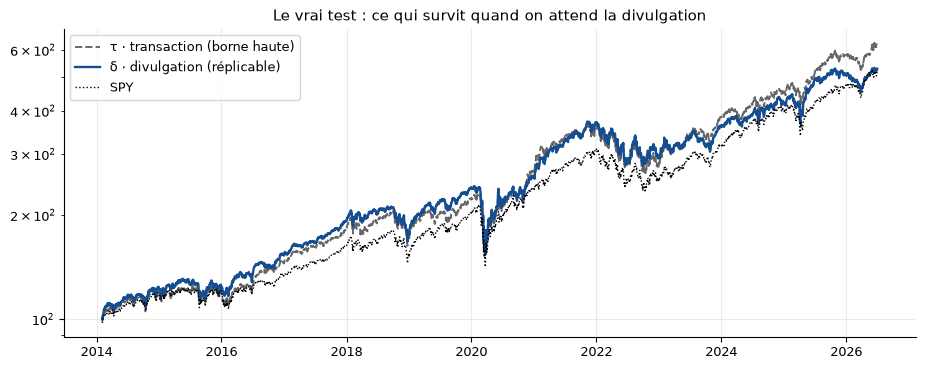

In [49]:
navspy3 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.4, ls="--", label="τ · transaction (borne haute)")
ax.plot(spanD.index, spanD, color=BLEU, lw=1.7, label="δ · divulgation (réplicable)")
ax.plot(navspy3.index, navspy3, color="k", lw=1.0, ls=":", label="SPY")
ax.set_yscale("log"); ax.set_title("Le vrai test : ce qui survit quand on attend la divulgation"); ax.legend()
plt.savefig(f"{FIGS}/divulgation.png", dpi=150, bbox_inches="tight"); plt.show()

### §11bis — Divulgation ET cap de rotation (les 4 coins)

On croise les deux réglages : borne du signal (τ / δ) $\times$ cap de rotation (sans / 25 %/mois). Le run
manquant est **δ + cap** = `run_livre(WPOd, TAU_MAX)`. On voit ainsi l'effet du cap séparément à τ et à δ.

In [50]:
spanD_cap, _ = run_livre(WPOd, TAU_MAX)                       # base à δ, avec cap 25 %/mois
tab4 = pd.DataFrame([bilan(spanA,     "τ · sans cap"),
                     bilan(spanB,     "τ · cap 25 %"),
                     bilan(spanD,     "δ · sans cap"),
                     bilan(spanD_cap, "δ · cap 25 %")]).set_index("run")
tab4.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · sans cap,1.706,1.030,1.048,0.645,1.023,622.132,7/13
τ · cap 25 %,0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
δ · sans cap,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
δ · cap 25 %,-0.490,-0.382,-0.672,-0.540,1.004,487.341,7/13


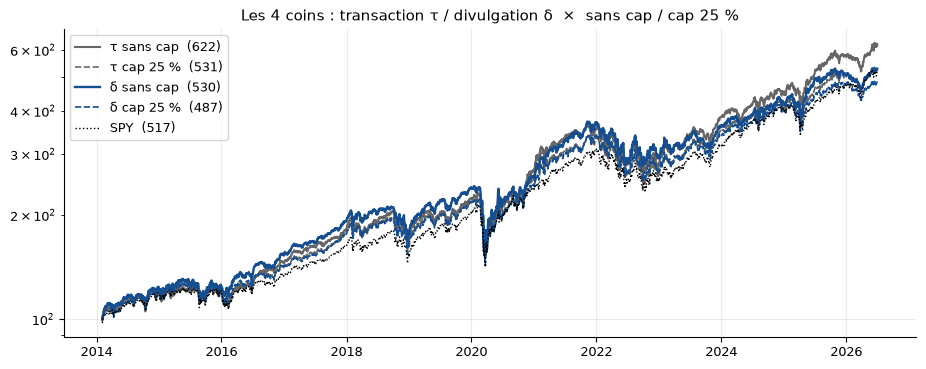

In [51]:
navspy4 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index,     spanA,     color=GRIS, lw=1.5,          label=f"τ sans cap  ({spanA.iloc[-1]:.0f})")
ax.plot(spanB.index,     spanB,     color=GRIS, lw=1.2, ls="--", label=f"τ cap 25 %  ({spanB.iloc[-1]:.0f})")
ax.plot(spanD.index,     spanD,     color=BLEU, lw=1.7,          label=f"δ sans cap  ({spanD.iloc[-1]:.0f})")
ax.plot(spanD_cap.index, spanD_cap, color=BLEU, lw=1.2, ls="--", label=f"δ cap 25 %  ({spanD_cap.iloc[-1]:.0f})")
ax.plot(navspy4.index, navspy4, color="k", lw=1.0, ls=":",       label=f"SPY  ({navspy4.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Les 4 coins : transaction τ / divulgation δ  ×  sans cap / cap 25 %")
plt.savefig(f"{FIGS}/coins.png", dpi=150, bbox_inches="tight"); plt.show()

## §12 — D'autres pistes

Jusqu'ici, à la divulgation, le ticker suit le marché (β≈1) et l'excès tombe à ~0. On explore trois causes
possibles de ce nul, plus deux découpages rapides. **Chaque piste est mesurée à τ (borne haute) ET à δ
(réplicable)** ; ces sections ajoutent des essais au compteur de multiplicité (§12.6). Aucune n'est un verdict.

**Les leviers.** ① *horizon* (tenir plus longtemps — Pyun trouve le signal vers 300 j) · ② *comités*
(ne garder que les membres siégeant sur le comité du secteur — le prédicteur le plus documenté) · ③ *marché
neutralisé* (retirer β·marché pour voir la sélection pure) · ④ *Sénat seul* · ⑤ *dépôts tardifs*.

In [52]:
# helper — rejoue TOUTE la chaîne du signal sur un sous-ensemble de trades (mask), à τ puis à δ.
# On swappe les globals que lisent flux/selection/acheteurs (df, IW, ordreW) ; γ voyage avec les lignes
# (la purge FIFO reste calculée sur l'historique complet, §4). run_livre/poids ne touchent pas à df.
def variante(mask, W=W, tau_max=np.inf, cotes=("tau","delta")):
    # rejoue le signal sur le sous-ensemble mask ; tau_max<∞ = cap de rotation ; cotes = quelles bornes
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idxmap = {"tau": dv.i0.values, "delta": dv.ide.values}
        df = dv
        spans = {}
        for lab in cotes:
            order = np.argsort(idxmap[lab], kind="stable")
            IW, ordreW = idxmap[lab][order], order
            SELv = {i: selection(i, W) for i in coupes}
            WPv  = {i: poids(i, W, SELv[i], acheteurs(i, SELv[i], W)) for i in coupes[:-1]}
            spans[lab] = run_livre(WPv, tau_max)[0]
        return (spans.get("tau"), spans.get("delta"), int(mask.sum()))
    finally:
        df, IW, ordreW = bak

def taille_sel(mask, cote, W=W):
    # tailles |S| du signal restreint, sans lancer le backtest (pour diagnostiquer τ vs δ)
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idx = dv.i0.values if cote == "tau" else dv.ide.values
        order = np.argsort(idx, kind="stable")
        df, IW, ordreW = dv, idx[order], order
        return np.array([len(selection(i, W)) for i in coupes])
    finally:
        df, IW, ordreW = bak

# contrôle : variante(tout) doit reproduire la base (spanA / spanD)
st, sd, n = variante(pd.Series(True, index=df.index))
print(f"contrôle variante(tout) : NAV τ {st.iloc[-1]:.1f} (base {spanA.iloc[-1]:.1f}) · "
      f"NAV δ {sd.iloc[-1]:.1f} (base {spanD.iloc[-1]:.1f})  → {n:,} trades")
assert abs(st.iloc[-1]-spanA.iloc[-1])<1e-6 and abs(sd.iloc[-1]-spanD.iloc[-1])<1e-6, "le swap ne reproduit pas la base"

contrôle variante(tout) : NAV τ 622.1 (base 622.1) · NAV δ 530.2 (base 530.2)  → 113,369 trades


### §12.1 — Horizon : tenir plus longtemps

On détient, au mois $t$, la **moyenne des portefeuilles cibles des $H$ derniers mois** (cohortes
chevauchantes, chacune $1/H$) : $w^{(H)}_t = \frac{1}{H}\sum_{h=0}^{H-1} w_{t-h}$, renormalisé. $H{=}1$
redonne la base. On balaie $H \in \{1,3,6,12\}$ mois, à τ et à δ.

In [53]:
def overlap(WP, H):
    ks = sorted(WP.keys()); out = {}
    for j, k in enumerate(ks):
        agg = {}
        for jj in range(max(0, j-H+1), j+1):
            for tk, wi in WP[ks[jj]].items(): agg[tk] = agg.get(tk, 0.0) + wi
        s = sum(agg.values())
        out[k] = {tk: wi/s for tk, wi in agg.items()} if s > 0 else {}
    return out

rows_h = []
for H in [1, 3, 6, 12]:
    for lab, WP in [("τ", WPO), ("δ", WPOd)]:
        span = run_livre(overlap(WP, H), np.inf)[0]
        rows_h.append(bilan(span, f"H={H:>2} mois · {lab}"))
tab_h = pd.DataFrame(rows_h).set_index("run")
print("horizon de détention — H=1 = la base"); tab_h.round(3)

horizon de détention — H=1 = la base


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13


### §12.2 — Comités pertinents

**L'idée.** Un élu qui siège au comité régulant un secteur a un avantage d'information sur ce secteur. On ne
garde donc, dans le signal, que les achats d'un membre siégeant sur un comité **ayant juridiction sur le
secteur GICS du titre acheté**.

**Le filtre.** À chaque membre $m$ on associe l'ensemble des secteurs couverts par ses comités :
$$\mathrm{Sec}(m) = \bigcup_{c\,\in\,\text{comités}(m)} \text{secteurs}(c)$$
Un trade $k = (m_k, i_k, \dots)$ est **retenu** si et seulement si le titre est dans la juridiction du membre :
$$k \text{ retenu} \iff \text{secteur}(i_k) \in \mathrm{Sec}(m_k)$$

**Tout le reste est IDENTIQUE à la base --- et c'est du LONG.** On rejoue la même chaîne (§5-§8) mais sur ce
sous-ensemble de trades. Flux et signal restreints (exposant $c$ = « comité ») :
$$NetBuy^{c}_{i,t} = \!\!\!\sum_{k\text{ retenu, achat}}\!\!\! A_k \;-\; \!\!\!\sum_{k\text{ retenu, vente}}\!\!\! A_k\gamma_k,
\qquad S^{c}_t = \{\, i : NetBuy^{c}_{i,t} > 0 \;\wedge\; nBuyers^{c}_{i,t} \ge 2 \,\}$$
Poids **une voix par membre**, restreint aux $K^c_t$ membres pertinents ($\mathcal{M}^c_t$ = membres retenus
ayant acheté un titre de $S^c_t$, $B^c_{m,t}$ = leurs titres) :
$$\boxed{\; w^{c}_{i,t} = \frac{1}{K^{c}_t} \sum_{m \in \mathcal{M}^{c}_t} \frac{\mathbf{1}\{i \in B^{c}_{m,t}\}}{|B^{c}_{m,t}|} \;}
\qquad \sum_i w^{c}_{i,t} = 1$$
On **achète** les titres de $S^c_t$ avec ces poids (aucune vente à découvert), on tient un mois, exécution au
close J+1 --- le moteur §7-§8 tel quel. **Seule la population de trades change.** Variante de robustesse plus
grossière : `committees_key_flag` (le membre est sur un comité « clé », sans regarder le secteur).

In [54]:
# carte comité -> secteurs GICS (juridictions les plus défendables)
COM_SEC = {
 "Financial Services":            {"Financials"},
 "Armed Services":                {"Industrials"},
 "Energy and Commerce":           {"Energy","Health Care","Communication Services","Utilities"},
 "Natural Resources":             {"Energy","Materials","Utilities"},
 "Agriculture":                   {"Consumer Staples","Materials"},
 "Transportation and Infrastructure": {"Industrials"},
 "Science, Space, and Technology":{"Information Technology"},
 "Homeland Security":             {"Industrials","Information Technology"},
 "Veterans":                      {"Health Care"},
}
def com_secteurs(s):
    if not isinstance(s, str): return set()
    out = set()
    for nom, secs in COM_SEC.items():
        if nom in s: out |= secs
    return out
comsec = df.committee_membership.map(com_secteurs)
mask_com = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, comsec)], index=df.index)
mask_key = (df.committees_key_flag == True)
print(f"trades comité-pertinents (secteur) : {mask_com.sum():,} / {len(df):,} ({mask_com.mean():.1%})")
print(f"trades sur comité « clé » (flag)    : {mask_key.sum():,} / {len(df):,} ({mask_key.mean():.1%})")
carte = pd.DataFrame([{"comité (House)": k, "secteurs GICS régulés": ", ".join(sorted(v))} for k, v in COM_SEC.items()])
print("\nla carte comité → secteur :"); display(carte)
print("exemples de trades RETENUS (le titre est dans la juridiction du membre) :")
display(df[mask_com][["member_name","tk","sector_gics","op"]].head(6))

trades comité-pertinents (secteur) : 18,948 / 113,369 (16.7%)
trades sur comité « clé » (flag)    : 63,912 / 113,369 (56.4%)

la carte comité → secteur :


,comité (House),secteurs GICS régulés
0,Financial Services,Financials
1,Armed Services,Industrials
2,Energy and Commerce,"Communication Services, Energy, Health Care, U..."
3,Natural Resources,"Energy, Materials, Utilities"
4,Agriculture,"Consumer Staples, Materials"
5,Transportation and Infrastructure,Industrials
6,"Science, Space, and Technology",Information Technology
7,Homeland Security,"Industrials, Information Technology"
8,Veterans,Health Care


exemples de trades RETENUS (le titre est dans la juridiction du membre) :


,member_name,tk,sector_gics,op
11,Michael T. McCaul,TSM,Information Technology,buy
22,Michael T. McCaul,TSM,Information Technology,buy
41,Michael T. McCaul,XRX,Industrials,sell
55,Nick J. Rahall,MTZ,Industrials,sell
57,Lamar Smith,GWRE,Information Technology,buy
71,Nick J. Rahall,GE,Industrials,sell


**Un exemple d'allocation, à une coupe.** Pour lever le doute : on est bien en **long**, chaque membre
pertinent pèse $1/K^c$ et le répartit également entre ses titres. Voici une coupe réelle.

In [55]:
# EXEMPLE concret à une coupe : le portefeuille LONG comité-secteur, membre par membre
dv = df[mask_com].reset_index(drop=True); ov = np.argsort(dv.i0.values, kind="stable")
_bdf, _bIW, _bow = df, IW, ordreW
df, IW, ordreW = dv, dv.i0.values[ov], ov
ic = coupes[len(coupes)*2//3]                                  # une coupe aux deux tiers de la période
Sc = selection(ic, W); Ac = acheteurs(ic, Sc, W); wc = poids(ic, W, Sc, Ac)
df, IW, ordreW = _bdf, _bIW, _bow                             # on remet la population complète
Kc = len(Ac)
print(f"coupe du {cal[ic].date()} — {Kc} membres pertinents · {len(Sc)} titres retenus · LONG seul · Σ w = {sum(wc.values()):.4f}")
ex = pd.DataFrame([{"membre": df.loc[df.bioguide_id==m,'member_name'].iat[0],
                    "|B_m| (nb titres)": len(v), "poids/titre = 1/(K·|B_m|)": 1/(Kc*len(v)),
                    "ses titres retenus": ", ".join(v[:5])} for m, v in list(Ac.items())[:8]])
display(ex.round(4))

coupe du 2022-05-31 — 4 membres pertinents · 4 titres retenus · LONG seul · Σ w = 1.0000


,membre,|B_m| (nb titres),poids/titre = 1/(K·|B_m|),ses titres retenus
0,Diana Harshbarger,1,0.2500,GNRC
1,Rohit Khanna,4,0.0625,"DOV, FDX, GNRC, UPS"
2,James R. Langevin,1,0.2500,GNRC
3,Michael T. McCaul,3,0.0833,"DOV, FDX, UPS"


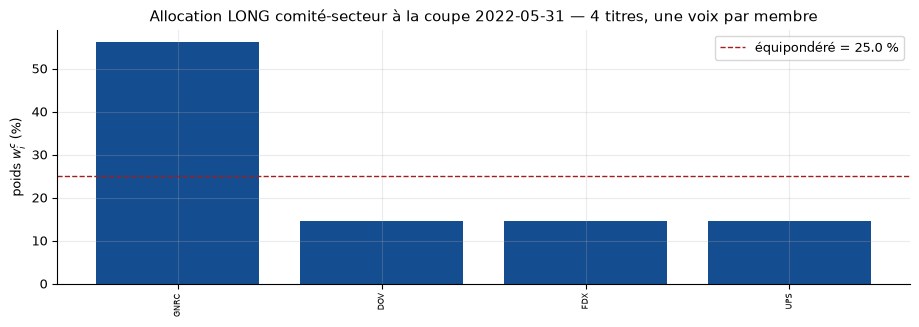

In [56]:
# les poids finaux w^c_i à cette coupe — la 'photo' de l'allocation
ws = pd.Series(wc).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.bar(range(len(ws)), ws.values*100, color=BLEU)
ax.axhline(100/len(ws), color=ROUGE, ls="--", lw=1, label=f"équipondéré = {100/len(ws):.1f} %")
ax.set_xticks(range(len(ws))); ax.set_xticklabels(ws.index, rotation=90, fontsize=6)
ax.set_ylabel("poids $w^c_i$ (%)"); ax.set_title(f"Allocation LONG comité-secteur à la coupe {cal[ic].date()} — {len(ws)} titres, une voix par membre")
ax.legend(); plt.savefig(f"{FIGS}/comites_alloc.png", dpi=150, bbox_inches="tight"); plt.show()

In [57]:
# les runs (on GARDE les NAV pour la figure) : comité-secteur et comité-clé, à τ et δ
stc, sdc, nc = variante(mask_com)
stk, sdk, nk = variante(mask_key)
tab_c = pd.DataFrame([bilan(stc, "comité-secteur · τ"), bilan(sdc, "comité-secteur · δ"),
                      bilan(stk, "comité-clé (flag) · τ"), bilan(sdk, "comité-clé (flag) · δ")]).set_index("run")
print(f"comité-secteur : {nc:,} trades · comité-clé : {nk:,} trades · base τ NAV 622 / δ NAV 530 pour comparaison")
display(tab_c.round(3))

comité-secteur : 18,948 trades · comité-clé : 63,912 trades · base τ NAV 622 / δ NAV 530 pour comparaison


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · δ,-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-clé (flag) · τ,1.739,0.697,0.612,0.283,1.040,608.888,7/13
comité-clé (flag) · δ,-1.053,-0.557,-1.428,-0.649,1.033,454.133,6/13


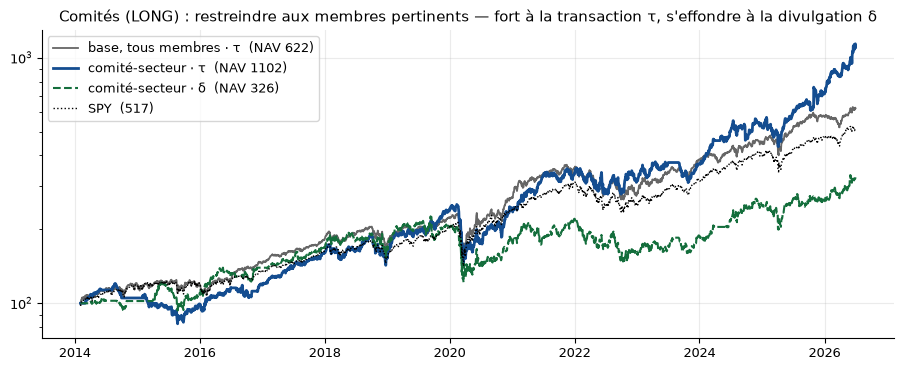

In [58]:
# LA figure : restreindre aux comités (LONG) double la NAV à τ, mais s'effondre à δ
navspy = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.3,           label=f"base, tous membres · τ  (NAV {spanA.iloc[-1]:.0f})")
ax.plot(stc.index,   stc,   color=BLEU, lw=2.0,           label=f"comité-secteur · τ  (NAV {stc.iloc[-1]:.0f})")
ax.plot(sdc.index,   sdc,   color=VERT, lw=1.5, ls="--",  label=f"comité-secteur · δ  (NAV {sdc.iloc[-1]:.0f})")
ax.plot(navspy.index, navspy, color="k", lw=1.0, ls=":",  label=f"SPY  ({navspy.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Comités (LONG) : restreindre aux membres pertinents — fort à la transaction τ, s'effondre à la divulgation δ")
plt.savefig(f"{FIGS}/comites.png", dpi=150, bbox_inches="tight"); plt.show()

### §12.2bis — Diagnostic : ce +7,7 % à τ est-il réel ?

Trois doutes à lever par la mesure : **(a)** la carte comité→secteur est-elle un vrai filtre d'information,
ou un simple **pari sectoriel** ? **(b)** pourquoi l'effondrement à δ ? **(c)** que donne le **cap** ?

part des trades de chaque secteur que le filtre comité-secteur RETIENT :


,retenus,part,total
sector_gics,,,
Industrials,8857,0.634,13971
Information Technology,3985,0.202,19708
Materials,840,0.182,4628
Consumer Staples,1082,0.132,8181
Energy,736,0.114,6470
Health Care,1699,0.112,15131
Utilities,251,0.110,2286
Financials,1165,0.070,16681
Communication Services,333,0.038,8748


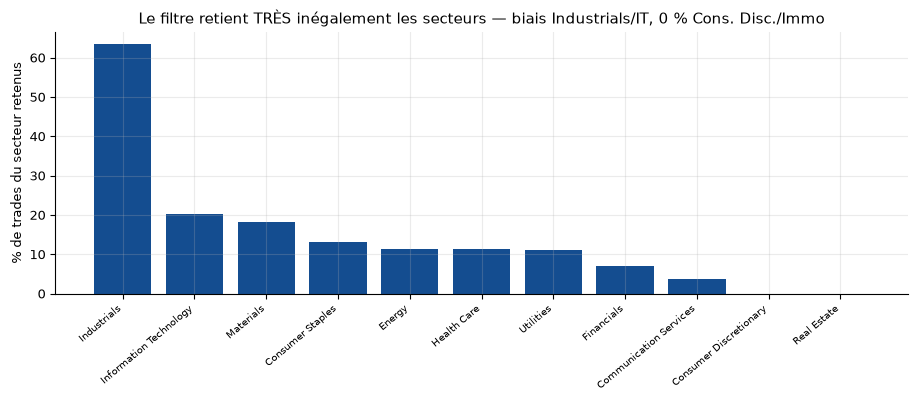

In [59]:
# (a) composition sectorielle des trades retenus — le filtre est-il équilibré ?
comp = (df.assign(ret=mask_com).groupby("sector_gics").ret
          .agg(retenus="sum", part="mean", total="size").sort_values("part", ascending=False))
print("part des trades de chaque secteur que le filtre comité-secteur RETIENT :")
display(comp.round(3))
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(comp.index, comp["part"]*100, color=BLEU)
ax.set_ylabel("% de trades du secteur retenus"); ax.set_xticklabels(comp.index, rotation=40, ha="right", fontsize=7)
ax.set_title("Le filtre retient TRÈS inégalement les secteurs — biais Industrials/IT, 0 % Cons. Disc./Immo")
plt.savefig(f"{FIGS}/comites_secteurs.png", dpi=150, bbox_inches="tight"); plt.show()

**Placebo.** On casse le lien réel *membre↔comité* : chaque membre reçoit le comité d'un autre membre
(permutation aléatoire, graine fixe), et on rejoue à τ. Si l'excès reste voisin du $+7,7\,\%$ réel, c'est
que le résultat vient du **tilt sectoriel** (le filtre surpondère Industrials/IT quel que soit qui siège où),
pas de l'information de comité. On répète 20 fois.

excès τ RÉEL (vraie affectation comité) : +7.67 %/an
placebo (comité au hasard, 20 tirages) : médiane +0.41 · min -8.31 · max +8.31 %/an
le réel dépasse 90% des placebos


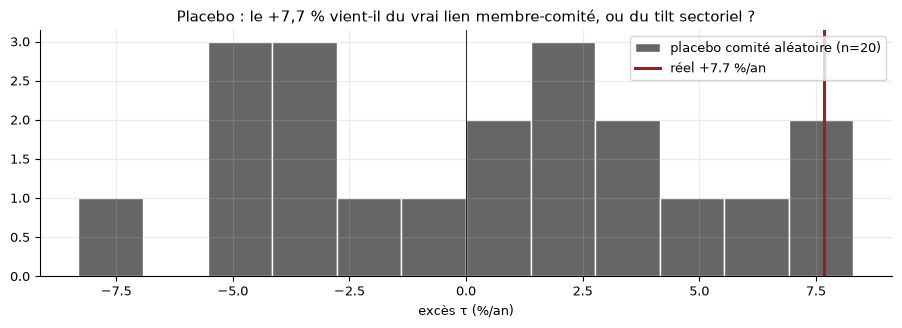

In [60]:
def run_tau_only(mask):
    st, _, _ = variante(mask, cotes=("tau",)); return st
np.random.seed(7)
memb = df.groupby("bioguide_id").committee_membership.first()
reel = bilan(stc, "reel")["excès %/an"]
placebo = []
for rep in range(20):
    perm = pd.Series(np.random.permutation(memb.values), index=memb.index)
    fake = df.bioguide_id.map(perm).map(com_secteurs)
    m = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, fake)], index=df.index)
    if m.sum() == 0: continue
    placebo.append(bilan(run_tau_only(m), "p")["excès %/an"])
placebo = np.array(placebo)
print(f"excès τ RÉEL (vraie affectation comité) : {reel:+.2f} %/an")
print(f"placebo (comité au hasard, {len(placebo)} tirages) : médiane {np.median(placebo):+.2f} · "
      f"min {placebo.min():+.2f} · max {placebo.max():+.2f} %/an")
print(f"le réel dépasse {(placebo < reel).mean():.0%} des placebos")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.hist(placebo, bins=12, color=GRIS, edgecolor="white", label=f"placebo comité aléatoire (n={len(placebo)})")
ax.axvline(reel, color=ROUGE, lw=2.2, label=f"réel {reel:+.1f} %/an")
ax.axvline(0, color="k", lw=0.6); ax.set_xlabel("excès τ (%/an)")
ax.set_title("Placebo : le +7,7 % vient-il du vrai lien membre-comité, ou du tilt sectoriel ?")
ax.legend(); plt.savefig(f"{FIGS}/comites_placebo.png", dpi=150, bbox_inches="tight"); plt.show()

**(b) L'effondrement τ→δ.** Taille du signal restreint, mois vides, et excès **année par année** — pour
voir si le $-3,65\,\%$ à δ est large ou porté par 1-2 années / un petit échantillon.

|S^c| médian — τ 4 · δ 4
mois vides   — τ 12/150 · δ 15/150   |   mois < 3 titres — τ 47 · δ 48

excès annuel comité-secteur — moyennes τ +7.68 · δ -3.66


,excès_τ (%),excès_δ (%)
Date,,
2014,-15.2,-18.2
2015,-7.2,5.1
2016,7.9,16.5
2017,13.4,-1.1
2018,0.6,3.3
2019,23.9,-9.0
2020,-16.6,-30.0
2021,10.4,-5.7
2022,12.0,-9.5


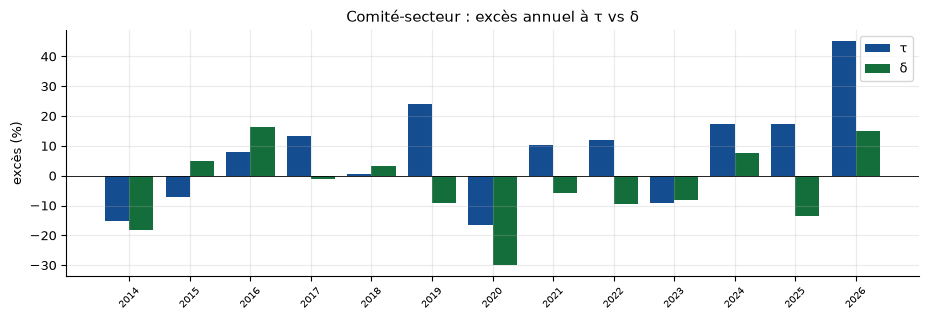

In [61]:
tSt, tSd = taille_sel(mask_com, "tau"), taille_sel(mask_com, "delta")
print(f"|S^c| médian — τ {np.median(tSt):.0f} · δ {np.median(tSd):.0f}")
print(f"mois vides   — τ {(tSt==0).sum()}/{len(tSt)} · δ {(tSd==0).sum()}/{len(tSd)}   |   "
      f"mois < 3 titres — τ {(tSt<3).sum()} · δ {(tSd<3).sum()}")
xt = annuel(stc)[2]; xd = annuel(sdc)[2]
annu_c = pd.DataFrame({"excès_τ (%)": xt, "excès_δ (%)": xd})
print(f"\nexcès annuel comité-secteur — moyennes τ {xt.mean():+.2f} · δ {xd.mean():+.2f}")
display(annu_c)
fig, ax = plt.subplots(figsize=(11, 3.2))
yy = annu_c.index.astype(str); x = np.arange(len(yy))
ax.bar(x-0.2, annu_c["excès_τ (%)"], 0.4, color=BLEU, label="τ")
ax.bar(x+0.2, annu_c["excès_δ (%)"], 0.4, color=VERT, label="δ")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(x); ax.set_xticklabels(yy, rotation=45, fontsize=7)
ax.set_ylabel("excès (%)"); ax.set_title("Comité-secteur : excès annuel à τ vs δ"); ax.legend()
plt.savefig(f"{FIGS}/comites_annuel.png", dpi=150, bbox_inches="tight"); plt.show()

**(c) Le cap sur les comités.** comité-secteur avec cap de rotation 25 %/mois, à τ et δ.

In [62]:
stc_cap, sdc_cap, _ = variante(mask_com, tau_max=TAU_MAX)
pd.DataFrame([bilan(stc,     "comité-secteur · τ  (sans cap)"),
             bilan(stc_cap, "comité-secteur · τ  (cap 25 %)"),
             bilan(sdc,     "comité-secteur · δ  (sans cap)"),
             bilan(sdc_cap, "comité-secteur · δ  (cap 25 %)")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ (sans cap),7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · τ (cap 25 %),2.777,0.881,2.097,0.703,1.017,670.816,8/13
comité-secteur · δ (sans cap),-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-secteur · δ (cap 25 %),-2.385,-0.987,-1.899,-0.646,1.020,388.781,6/13


### §12.3 — Marché neutralisé : isoler la sélection

Le β≈1 masque toute sélection. On retire, jour après jour, $\hat\beta_t \cdot (r_{\text{SPY}}-r_f)$
($\hat\beta_t$ = β glissant 252 j) : le résidu $(r-r_f) - \hat\beta_t (r_{\text{SPY}}-r_f)$ est le
**P\&L de sélection pur**. On le mesure sur la base, à τ et à δ. $\alpha$/an, $t_\alpha$, volatilité.

In [63]:
def neutre(span, nom):
    r = span.pct_change().dropna()
    dd = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
    yy, xx = dd.p - dd.RF, dd.m - dd.RF
    b_full = np.polyfit(xx.values, yy.values, 1)[0]
    beta = (yy.rolling(252).cov(xx) / xx.rolling(252).var()).fillna(b_full)
    resid = (yy - beta*xx).dropna()
    t = resid.mean()/(resid.std(ddof=1)/np.sqrt(len(resid)))
    nav = 100*(1+resid).cumprod().iloc[-1]
    return {"run": nom, "α %/an": 252*resid.mean()*100, "t_α": t,
            "vol %/an": resid.std()*np.sqrt(252)*100, "NAV sélection": nav}
tab_n = pd.DataFrame([neutre(spanA, "base neutralisée · τ"),
                      neutre(spanD, "base neutralisée · δ")]).set_index("run")
print("après retrait de β·marché : ce qui reste = sélection pure"); tab_n.round(3)

après retrait de β·marché : ce qui reste = sélection pure


,α %/an,t_α,vol %/an,NAV sélection
run,,,,
base neutralisée · τ,1.080,0.665,5.678,111.884
base neutralisée · δ,0.031,0.019,5.797,98.346


### §12.4 / §12.5 — Sénat seul · dépôts tardifs

**Sénat** (Lazzaretto : signal plus fort à la chambre haute, mais petit échantillon → puissance limitée).
**Tardifs** : trades déposés en retard (`flag_late_filing`) — hypothèse d'un trade qu'on préfère cacher.

In [64]:
rows_f = []
for nom, m in [("Sénat seul", df.chamber == "senate"), ("dépôts tardifs", df.flag_late_filing == True)]:
    st, sd, n = variante(m)
    print(f"{nom} : {n:,} trades")
    rows_f += [bilan(st, f"{nom} · τ"), bilan(sd, f"{nom} · δ")]
tab_f = pd.DataFrame(rows_f).set_index("run")
tab_f.round(3)

Sénat seul : 9,246 trades


dépôts tardifs : 13,037 trades


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Sénat seul · τ,-2.540,-0.402,-0.745,-0.155,0.833,359.002,6/13
Sénat seul · δ,-3.722,-0.572,1.779,0.326,0.620,287.046,6/13
dépôts tardifs · τ,2.061,0.492,4.470,0.865,0.895,632.524,7/13
dépôts tardifs · δ,-8.252,-1.983,-0.106,-0.027,0.389,199.782,4/13


### §12.6 — Récapitulatif et multiplicité

Toutes les pistes côte à côte. **Déclaration honnête** : ces essais s'ajoutent au compteur — plus on teste,
plus un $t$ élevé peut sortir par hasard. On lit chaque $t$ face au nombre total d'essais (E$[\max t]$ croît
avec le nombre de tirages). Le run revendiquable reste **δ** (réplicable) ; τ est une borne haute.

In [65]:
recap = pd.concat([tab_h, tab_c, tab_f]).round(3)
n_essais = len(recap) + 2                      # + les 2 neutralisées
import math
print(f"nombre d'essais §12 : {n_essais}  →  E[max |t|] sous H0 ≈ {math.sqrt(2*math.log(n_essais)):.2f} (bruit)")
# le meilleur candidat à δ (hors base), pour l'œil — PAS un verdict
d = recap[recap.index.str.endswith('δ')].copy()
d["|t|"] = d["t"].abs()
print("\nmeilleurs |t| à δ :")
display(d.sort_values("|t|", ascending=False)[["excès %/an","t","α %/an","β","NAV"]].head(6))
recap

nombre d'essais §12 : 18  →  E[max |t|] sous H0 ≈ 2.40 (bruit)

meilleurs |t| à δ :


,excès %/an,t,α %/an,β,NAV
run,,,,,
dépôts tardifs · δ,-8.252,-1.983,-0.106,0.389,199.782
comité-secteur · δ,-3.645,-0.992,-3.137,0.991,325.779
H=12 mois · δ,-0.892,-0.787,-1.085,1.012,468.659
Sénat seul · δ,-3.722,-0.572,1.779,0.620,287.046
comité-clé (flag) · δ,-1.053,-0.557,-1.428,1.033,454.133
H= 3 mois · δ,-0.508,-0.322,-0.830,1.012,478.144


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13


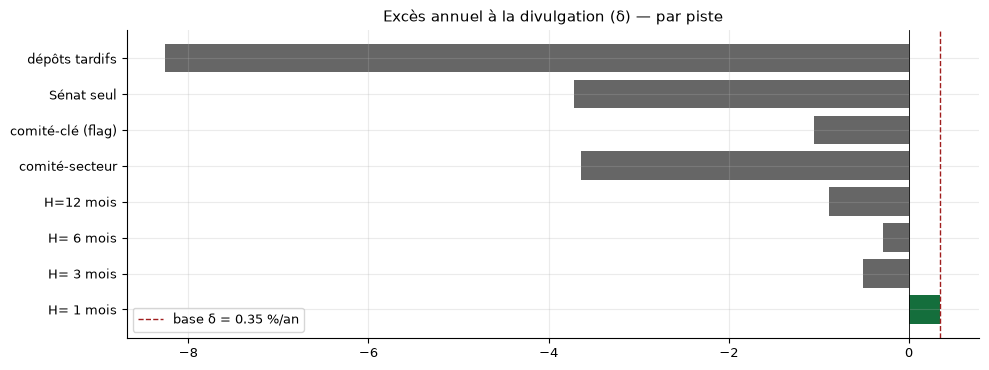

In [66]:
# figure : excès annuel (δ) par piste vs la base — voir si une piste décolle
fig, ax = plt.subplots(figsize=(11, 4))
base_d = bilan(spanD, "base δ")["excès %/an"]
lab = [i.replace(' · δ','') for i in recap.index if i.endswith('δ')]
val = [recap.loc[i,"excès %/an"] for i in recap.index if i.endswith('δ')]
ax.barh(lab, val, color=[VERT if v>base_d else GRIS for v in val])
ax.axvline(base_d, color=ROUGE, ls="--", lw=1, label=f"base δ = {base_d:.2f} %/an")
ax.axvline(0, color="k", lw=0.6)
ax.set_title("Excès annuel à la divulgation (δ) — par piste"); ax.legend()
plt.savefig(f"{FIGS}/pistes.png", dpi=150, bbox_inches="tight"); plt.show()

## §13.0 — Récapitulatif : les trois répliques de produits réels (ce qui est appliqué)

Avant les mesures, voici **exactement ce qu'on applique** pour chaque produit, face à sa **règle publiée**.
Trois colonnes : leur règle (source) · notre code · ce qui est **fidèle / approximé / non-divulgué**.

| réplique | leur règle (source) | ce qu'on applique (code) | fidèle · approximé · non-divulgué | validation |
|---|---|---|---|---|
| **NANC** (Dém.) | **ACHATS** (pas le net) sur **3 ans** à δ, pondéré au « **niveau de trading** » (gros **+ récurrents + de plusieurs élus**), 100-200 titres, ~8,5 % max *(prospectus lu p.2)* | `poids_parti("Democrat")` : $(\sum \text{achats})\times(\text{nb élus})$, fusion classes d'actions, **cap 8,5 %**, 3 ans δ | **fidèle** : achats · breadth · cap · 3 ans · δ. **non modélisé** : « en poste » ; **formule exacte non divulguée** (qualitative) | **recouvrement 5/10** vs vrai NANC (NVDA 8,5 % **exact**, GOOG/MSFT/AMZN/AAPL) ; excès **+2,98 %/an** ≈ réel **+2,67 %** |
| **GOP** (Rép.) | idem, élus **Républicains** | `poids_parti("Republican")` | idem | excès +1,24 %/an ; *(holdings GOP réels non fournis → validé par symétrie de règle)* |
| **Quiver Congress Buys** | long des **achats**, **pondéré à la taille (\$)**, rebalancé **hebdo** *(page Quiver ; disclaimer « hypothetical »)* | `poids_taille(mode="dollar", W=63)` : $w\propto\sum\$$ sur 63 j ; `run_livre` **hebdo** *et* mensuel ; à **τ et δ** | **fidèle** : long · \$-pond · hebdo. **non divulgué (choisi)** : fenêtre 63 j, règle de sortie, τ vs δ | β 1,06 ; leurs β/Sharpe ⇒ ~24 % *(§14.1)* |
| **Quiver Long-Short** | **+130 %** achats **−30 %** ventes, pondéré \$ *(panier short, fenêtre, timing : non divulgués)* | `longshort` : $1{,}3\,r_{\text{long}}-0{,}3\,r_{\text{short}}$ ; short $=$ **toutes les ventes** \$-pond 63 j **(notre choix)** ; overlay rebalancé quotidien | **fidèle** : 130/30 ; **non divulgué** : le panier short (test de sensibilité §14.0) | β 1,07 ; les 2 jambes $\approx$ marché $\Rightarrow$ **LS $\approx$ marché levé** |

Détail et mesures : **§13** (NANC/GOP) · **§14** (Quiver, dont §14.1 « on fait bien ? »).

## §13 — Ce que font les produits réels : réplique NANC / GOP (corrigée sur prospectus)

Les ETF **NANC** (Dém.) / **GOP** (Rép.) de Subversive/Unusual Whales. **Règle EXACTE** (prospectus lu, p.2) :
- univers = titres **achetés** par les élus d'un parti (+ famille), PTR, **en poste**, sur **3 ans** glissants ;
- pondéré au « **niveau de trading** » : **gros achats + récurrents + de plusieurs élus** → surpondérés ;
- ⚠️ **les ventes de positions détenues AVANT la fenêtre / avant l'entrée en fonction ne réduisent PAS** le portefeuille ;
- **100-200 titres**, rebalancé **à la divulgation** ($\delta$) ; concentration observée **~8,5 % max**.

**Correction (Alice, holdings réels 24/07/2026).** Notre 1re version pondérait au **net brut** (achats − *toutes*
les ventes) : le netting rendait MSFT/AAPL/AMZN **négatifs** (élus vendant de vieilles positions) et les
**excluait** → recouvrement **2/10** avec le vrai NANC. Le prospectus dit justement de **ne pas** soustraire ces
ventes. On corrige : pondération aux **achats $\times$ nombre d'élus**, **top-150** (queue de-minimis coupée), **cap 8,5 %**.

$$w^{P}_{i,t} \;\propto\; \Big(\textstyle\sum_{k\,:\,\text{parti }P,\ \text{achat},\ t-3\text{ans}<\delta_k\le t} A_k\Big)\ \times\ \#\{\text{élus de }P\text{ acheteurs de } i\},\qquad \text{puis plafonné à } 8{,}5\%\quad(P=\text{NANC/GOP})$$

In [67]:
# arrays de fenêtrage sur la DIVULGATION (δ), persistants pour le §13
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]
W3 = 756                                                       # ~3 ans de bourse

def cap_poids(w, cap=0.085):
    # plafonne chaque poids à `cap`, redistribue l'excédent au prorata (diversification ~ vrai NANC)
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

FUSION = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}   # classes d'actions = une société

def poids_parti(i1, parti, topN=150, cap=0.085):
    # parti = "Democrat" (→ ETF NANC) ou "Republican" (→ ETF GOP) — MÊME règle pour les deux (V1).
    # prospectus : « niveau de trading » des ACHATS (les ventes de vieilles positions ne comptent PAS, ≠ net brut) ;
    #   gros + récurrents + de PLUSIEURS élus surpondérés → score = (Σ achats) × (nb d'élus acheteurs).
    # + fusion des classes d'actions, top-N (100-200), cap de position 8,5 % (diversification observée), sur 3 ans de δ.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    g       = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    buy     = g.groupby("tkm").A.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique()
    score   = (buy * breadth.reindex(buy.index)).dropna()       # taille × nombre d'élus acheteurs
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)     # les ~150 plus « tradés » (de-minimis ≈ queue coupée)
    if score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

WP_nanc = {i: poids_parti(i, "Democrat")   for i in coupes[:-1]}
WP_gop  = {i: poids_parti(i, "Republican") for i in coupes[:-1]}
span_nanc, _ = run_livre(WP_nanc, np.inf)
span_gop,  _ = run_livre(WP_gop,  np.inf)
nN = int(np.median([len(WP_nanc[i]) for i in coupes[:-1] if WP_nanc[i]]))
nG = int(np.median([len(WP_gop[i])  for i in coupes[:-1] if WP_gop[i]]))
print(f"nb de titres détenus (médiane) — NANC {nN} · GOP {nG}  (le prospectus dit 100-200)")
pd.DataFrame([bilan(span_nanc, "réplique NANC (Démocrates)"),
             bilan(span_gop,  "réplique GOP (Républicains)"),
             bilan(spanD,     "notre base à δ (rappel)")]).set_index("run").round(3)

nb de titres détenus (médiane) — NANC 150 · GOP 150  (le prospectus dit 100-200)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
réplique NANC (Démocrates),2.980,1.470,1.257,1.064,1.077,672.348,9/13
réplique GOP (Républicains),1.236,1.621,1.117,1.080,1.004,612.246,10/13
notre base à δ (rappel),0.350,0.183,-0.032,-0.019,1.010,530.210,7/13


In [68]:
# VALIDATION contre les HOLDINGS RÉELS de NANC (fichier fourni par Alice, 24/07/2026)
real = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/NANC_holdings_20260724.csv")
real = real[~real.StockTicker.isin(["Cash&Other", "FGXXX"])].copy()
real["w"] = real.Weightings.str.rstrip("%").astype(float)
real = real.sort_values("w", ascending=False).reset_index(drop=True)
rep  = (pd.Series(poids_parti(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
def recouvre(n): return len(set(rep.head(n).index) & set(real.head(n).StockTicker))
nvda_r = float(real.set_index("StockTicker").w.get("NVDA", np.nan))
print(f"Recouvrement réplique ↔ vrai NANC : top-10 {recouvre(10)}/10 · top-15 {recouvre(15)}/15 · top-20 {recouvre(20)}/20")
print(f"NVDA — réplique {rep.get('NVDA', 0):.1f} % vs réel {nvda_r:.1f} %  ·  titres réplique {len(rep)} · plus gros {rep.max():.1f} %")
print("(rappel : la 1re version pondérée au net-$ donnait 2/10 et NVDA 25 %)\n")
cmp = pd.DataFrame({
    "vrai NANC":      [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker", "w"]].values],
    "notre réplique": [f"{t} {w:.1f}%" for t, w in zip(rep.head(15).index, rep.head(15).values)]})
cmp.index = range(1, 16)
display(cmp)

Recouvrement réplique ↔ vrai NANC : top-10 5/10 · top-15 7/15 · top-20 10/20
NVDA — réplique 8.5 % vs réel 8.5 %  ·  titres réplique 150 · plus gros 8.5 %
(rappel : la 1re version pondérée au net-$ donnait 2/10 et NVDA 25 %)



,vrai NANC,notre réplique
1,NVDA 8.5%,NVDA 8.5%
2,GOOG 5.8%,GOOG 8.5%
3,MSFT 5.3%,AMZN 8.2%
4,AMAT 5.2%,MSFT 8.2%
5,AMZN 4.7%,AAPL 6.6%
6,AAPL 4.6%,AVGO 6.3%
7,CRWD 3.4%,PANW 5.4%
8,PM 3.2%,META 3.4%
9,AXP 2.8%,TSM 1.5%
10,LLY 2.7%,NFLX 1.4%


corrélation des poids ρ = 0.73  ·  exposition commune Σ min(wʳᵉᵉˡ, wʳᵉᵖ) = 51 %  ·  recouvrement top-15 7/15


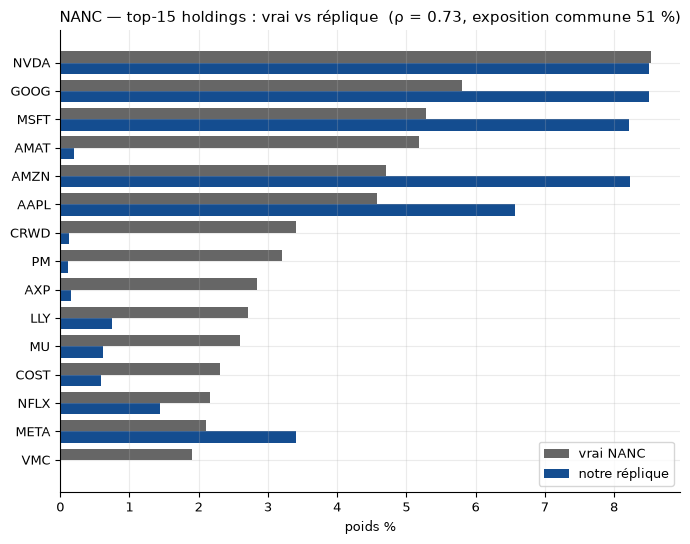

In [69]:
# MÉTRIQUES de fidélité + FIGURE de comparaison (vrai NANC vs réplique)
FUS   = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}
realw = real.assign(tk=real.StockTicker.map(lambda t: FUS.get(t, t))).groupby("tk").w.sum()
M     = pd.DataFrame({"reel": realw, "rep": rep.groupby(rep.index.map(lambda t: FUS.get(t, t))).sum()}).fillna(0.0)
rho     = M[(M.reel > 0) | (M.rep > 0)].corr().iloc[0, 1]        # corrélation des poids réel↔réplique
commune = float(M[["reel", "rep"]].min(axis=1).sum())           # exposition commune = Σ min(w_réel, w_rép)
print(f"corrélation des poids ρ = {rho:.2f}  ·  exposition commune Σ min(wʳᵉᵉˡ, wʳᵉᵖ) = {commune:.0f} %  "
      f"·  recouvrement top-15 {recouvre(15)}/15")
top = M.sort_values("reel", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6)); yy = np.arange(len(top)); h = 0.4
ax.barh(yy + h/2, top.reel, h, color=GRIS, label="vrai NANC")
ax.barh(yy - h/2, top.rep,  h, color=BLEU, label="notre réplique")
ax.set_yticks(yy); ax.set_yticklabels(top.index, fontsize=9); ax.set_xlabel("poids %"); ax.legend()
ax.set_title(f"NANC — top-15 holdings : vrai vs réplique  (ρ = {rho:.2f}, exposition commune {commune:.0f} %)")
plt.savefig(f"{FIGS}/nanc_compare.png", dpi=150, bbox_inches="tight"); plt.show()

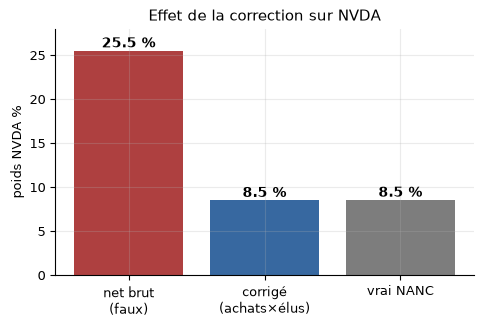

In [70]:
# FIGURE : l'effet de la correction sur NVDA (le plus gros nom) — net brut → corrigé → réel
fig, ax = plt.subplots(figsize=(5.4, 3.2))
vals = [25.5, rep.get("NVDA", 0.0), nvda_r]
labs = ["net brut\n(faux)", "corrigé\n(achats×élus)", "vrai NANC"]
ax.bar(labs, vals, color=[ROUGE, BLEU, GRIS], alpha=.85)
for i, v in enumerate(vals): ax.text(i, v + 0.4, f"{v:.1f} %", ha="center", fontweight="bold", fontsize=10)
ax.set_ylabel("poids NVDA %"); ax.set_ylim(0, 28); ax.set_title("Effet de la correction sur NVDA")
plt.savefig(f"{FIGS}/nanc_fix.png", dpi=150, bbox_inches="tight"); plt.show()

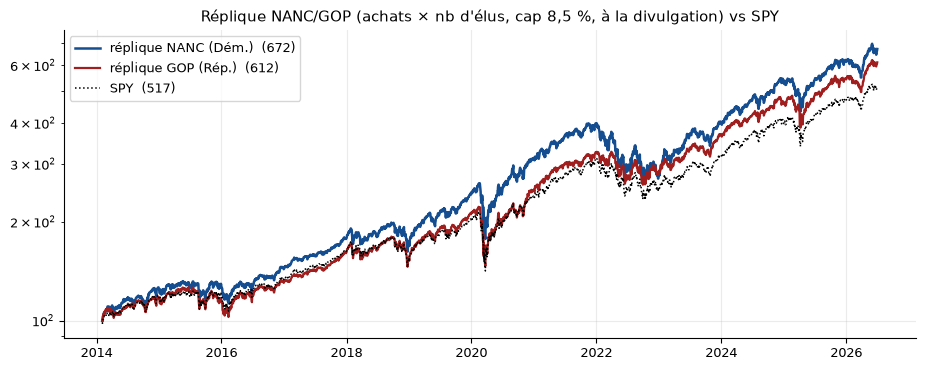

In [71]:
navspyN = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(span_nanc.index, span_nanc, color=BLEU, lw=1.8, label=f"réplique NANC (Dém.)  ({span_nanc.iloc[-1]:.0f})")
ax.plot(span_gop.index,  span_gop,  color=ROUGE, lw=1.6, label=f"réplique GOP (Rép.)  ({span_gop.iloc[-1]:.0f})")
ax.plot(navspyN.index, navspyN, color="k", lw=1.1, ls=":", label=f"SPY  ({navspyN.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique NANC/GOP (achats × nb d'élus, cap 8,5 %, à la divulgation) vs SPY")
plt.savefig(f"{FIGS}/nanc_gop.png", dpi=150, bbox_inches="tight"); plt.show()

**Rendement TOTAL vs excès.** Le tableau ci-dessus donne l'\emph{excès} (rendement $-$ SPY), pas le total.
On montre ici le **rendement total annualisé** (ce qu'annoncent NANC/GOP) sur 2014-2026 ET sur la seule
fenêtre 2023-2026 (celle de leur historique réel) — pour lever la confusion « 0,2 % vs 22 % ».

In [72]:
spy_nav = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1
d23 = pd.Timestamp("2023-02-01")
rows = []
for nom, s in [("réplique NANC", span_nanc), ("réplique GOP", span_gop), ("SPY", spy_nav)]:
    rows.append({"série": nom, "total/an 2014-26 %": 100*cagr(s), "total/an 2023-26 %": 100*cagr(s, d23)})
print("les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; notre SPY ~21 %/an sur la même fenêtre")
pd.DataFrame(rows).set_index("série").round(1)

les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; notre SPY ~21 %/an sur la même fenêtre


,total/an 2014-26 %,total/an 2023-26 %
série,,
réplique NANC,16.6,24.2
réplique GOP,15.8,22.5
SPY,14.4,20.8


### §13.1 — $\alpha$ et $\beta$ **glissants** (252 j) des répliques NANC/GOP

Le $\beta$ et l'$\alpha$ du bilan sont *plein-échantillon*. On les regarde ici **au fil du temps** (régression
OLS glissante sur 1 an) : $y_t=r_t-r_f$ régressé sur $x_t=r_{\text{SPY},t}-r_f$, $\ \hat\beta_t=\dfrac{\mathrm{cov}_W(y,x)}{\mathrm{var}_W(x)}$,
$\ \hat\alpha_t=(\bar y_W-\hat\beta_t\,\bar x_W)\times252$. Une cellule **valide** que ce glissant $=$ la régression `np.polyfit`.

NANC — β glissant méd 1.05 [0.96; 1.26] · α glissant méd +1.7 %/an
GOP  — β glissant méd 0.99 [0.89; 1.13] · α glissant méd +1.6 %/an


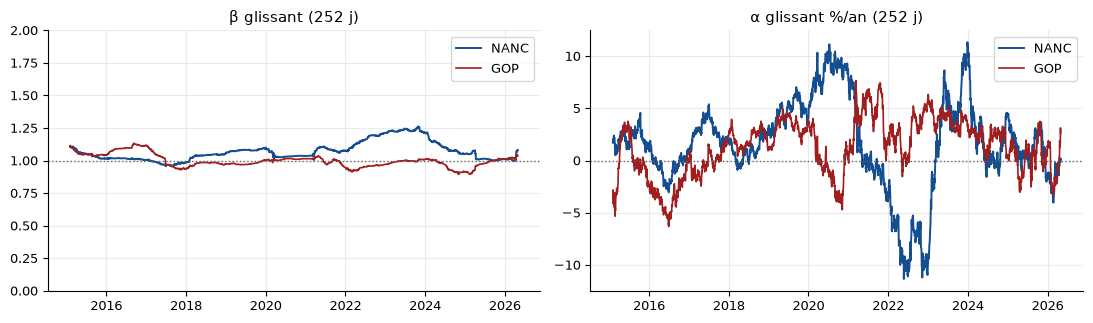

In [73]:
Wab = 252
def roll_ab(span):
    r = span.pct_change().dropna()
    d = pd.DataFrame({"y": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
    y, x  = d.y - d.RF, d.m - d.RF
    beta  = y.rolling(Wab).cov(x) / x.rolling(Wab).var()
    alpha = (y.rolling(Wab).mean() - beta * x.rolling(Wab).mean()) * 252 * 100     # α annualisé, %
    return alpha.dropna(), beta.dropna(), y, x
aN, bN, yN, xN = roll_ab(span_nanc)
aG, bG, _, _   = roll_ab(span_gop)
print(f"NANC — β glissant méd {bN.median():.2f} [{bN.min():.2f}; {bN.max():.2f}] · α glissant méd {aN.median():+.1f} %/an")
print(f"GOP  — β glissant méd {bG.median():.2f} [{bG.min():.2f}; {bG.max():.2f}] · α glissant méd {aG.median():+.1f} %/an")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].plot(bN.index, bN, color=BLEU, lw=1.4, label="NANC"); ax[0].plot(bG.index, bG, color=ROUGE, lw=1.2, label="GOP")
ax[0].axhline(1, color=GRIS, ls=":", lw=1); ax[0].set_ylim(0, 2); ax[0].set_title(f"β glissant ({Wab} j)"); ax[0].legend()
ax[1].plot(aN.index, aN, color=BLEU, lw=1.4, label="NANC"); ax[1].plot(aG.index, aG, color=ROUGE, lw=1.2, label="GOP")
ax[1].axhline(0, color=GRIS, ls=":", lw=1); ax[1].set_title(f"α glissant %/an ({Wab} j)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_rolling.png", dpi=150, bbox_inches="tight"); plt.show()

In [74]:
# VALIDATION (règle : tout calcul ajouté est vérifié) — α/β glissants == régression OLS np.polyfit, même fenêtre
sl = slice(-Wab, None)
yy, xx = yN.values[sl], xN.values[sl]
b_pf, a_pf = np.polyfit(xx, yy, 1)                                   # la méthode du bilan (OLS)
b_roll = float(pd.Series(yy).cov(pd.Series(xx)) / pd.Series(xx).var())
a_roll = float(yy.mean() - b_roll * xx.mean())
print(f"dernière fenêtre — β : glissant {b_roll:.8f} vs polyfit {b_pf:.8f}  ·  α/j : glissant {a_roll:.3e} vs polyfit {a_pf:.3e}")
assert abs(b_roll - b_pf) < 1e-9 and abs(a_roll - a_pf) < 1e-9, "α/β glissants ≠ régression OLS"
b_full = float(np.polyfit(xN.values, yN.values, 1)[0])
print(f"✅ validation : α/β glissants = OLS (polyfit) à 1e-9 · β plein-échantillon {b_full:.2f} ≈ β bilan NANC 1,08")

dernière fenêtre — β : glissant 1.07978191 vs polyfit 1.07978191  ·  α/j : glissant -4.519e-06 vs polyfit -4.519e-06
✅ validation : α/β glissants = OLS (polyfit) à 1e-9 · β plein-échantillon 1.08 ≈ β bilan NANC 1,08


## §13.2 — Variante 2 : réplique **fidèle au prospectus** (netting $\gamma$ + de-minimis)

La variante 1 (§13, `poids_parti`) pondère les **achats seuls**. Le prospectus, lui, **nette** les achats contre les
**ventes récentes du même titre** — mais **ne** soustrait **pas** les ventes de positions acquises avant la fenêtre
(« will not adjust … for sales » de vieux lots). On l'implémente **sans toucher V1**, comme **V2 = `poids_parti_v2`**,
en **réutilisant la purge $\gamma$ du §4** (FIFO plein historique : une vente consomme les **plus vieux** lots d'abord) :

- **$\gamma_k$ à 3 ans** ($\bar a = 756$ j $=$ la fenêtre du prospectus, au lieu des 504 j du ticker) : part de la vente
  $k$ portant sur des lots détenus $\le 3$ ans. Une vente d'un lot dormant ($>3$ ans) a $\gamma_k\to 0$ $\Rightarrow$ **ignorée**.
- **Netting** par (élu $m$, titre $i$), sur la fenêtre 3 ans à $\delta$ : $\ \text{net}_{m,i}=\bigl[\sum_k A_k - \sum_k A_k\gamma_k\bigr]^{+}$
  (achats moins la part **récente** des ventes, plancher 0) ; $\ \text{net}_i=\sum_m \text{net}_{m,i}$.
- **Score** $s_i=\text{net}_i\times m_i$ ($m_i=\#$ élus avec net$>0$) — même forme que V1, mais sur le **net**.
- **De-minimis** : garder $i$ si $\text{net}_i\ge 1\%\cdot\sum_j\text{net}_j$ ; **cardinal borné à [100, 200]** (au lieu du top-150 fixe).
- **Cap 8,5 %** conservé (pour n'isoler que l'effet netting+sélection). ETF sectoriels : extension ultérieure.

Le $\gamma$ vend les vieux lots d'abord (bon sens FIFO) : ex. achat 10 M\$ il y a 4 ans (hors fenêtre) $+$ achat 5 M\$
il y a 1 an, vente 12 M\$ $\Rightarrow$ $\gamma_3=2/12$, net $=[5-12\cdot\tfrac{2}{12}]^{+}=$ **3 M\$** (l'ancien FIFO in-fenêtre
donnait 0). On calcule V1 **et** V2, on compare **recouvrement** aux vrais holdings NANC $+$ **bilan** ; on ne remplace
V1 **que si V2 fait mieux**.

In [75]:
# γ à 3 ANS (756 j) — MÊME FIFO plein historique que §3/§4, seuil = fenêtre du prospectus (≠ 504 du ticker).
# La purge γ vend les VIEUX lots d'abord : une vente d'un lot détenu >3 ans a γ3→0 (« acquis avant le lookback,
# n'ajuste pas le portefeuille » — prospectus) ; seule la part récente d'une vente réduit la position.
A_BAR3 = W3                                                    # 756 j de bourse ≈ 3 ans
gam3   = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune    = sum(q for h, q in pieces if h <= A_BAR3) + reste    # part détenue <= 3 ans (+ non apparié)
    gam3[idx] = jeune / tot
df["Aeff3"]   = df.A * np.where(df.op == "buy", 1.0, gam3)    # A (achat) · A·γ3 (vente : part récente)
df["signed3"] = df.Aeff3 * df.sgn                            # +A (achat) / −A·γ3 (vente récente)

def poids_parti_v2(i1, parti, cap=0.085, dm=0.01, nmin=100, nmax=200):
    # parti = "Democrat" (→ NANC) ou "Republican" (→ GOP) — MÊME règle pour les deux (V2).
    # FIDÈLE au prospectus via la purge γ (§4) : net = [Σ achats − Σ ventes·γ3]⁺ par (élu,titre) sur 3 ans (δ) ;
    #   score = net$ × nb d'élus, de-minimis 1%, 100-200 titres, cap 8,5% (comparabilité avec V1).
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti]                                # ACHATS + VENTES (on doit netter)
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()  # net brut par (élu,titre) = Σ achats − Σ ventes·γ3
    per = per[per > 0]                                     # plancher 0 par élu (pas de position négative)
    if not len(per): return {}
    neti = per.groupby("tkm").sum()                        # net agrégé par titre
    mi   = per.groupby("tkm").size()                       # nb d'élus à net positif
    neti = neti[[tk for tk in neti.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    if not len(neti): return {}
    theta = float(neti.sum())
    D     = neti[neti >= dm * theta]                       # de-minimis : net >= 1% du total tradé
    score = (neti * mi.reindex(neti.index)).dropna().sort_values(ascending=False)
    n     = int(np.clip(len(D), nmin, nmax))               # cardinal = |de-minimis|, borné [100,200]
    sel   = score.head(n)
    if sel.sum() <= 0: return {}
    return cap_poids(sel / sel.sum(), cap).to_dict()

WP_nanc2 = {i: poids_parti_v2(i, "Democrat")   for i in coupes[:-1]}
WP_gop2  = {i: poids_parti_v2(i, "Republican") for i in coupes[:-1]}
span_nanc2, _ = run_livre(WP_nanc2, np.inf)
span_gop2,  _ = run_livre(WP_gop2,  np.inf)
nN2 = int(np.median([len(WP_nanc2[i]) for i in coupes[:-1] if WP_nanc2[i]]))
nG2 = int(np.median([len(WP_gop2[i])  for i in coupes[:-1] if WP_gop2[i]]))
print(f"V2 nb de titres détenus (médiane) — NANC {nN2} · GOP {nG2}  (prospectus : 100-200)")
pd.DataFrame([bilan(span_nanc,  "V1 NANC — achats seuls"),
             bilan(span_nanc2, "V2 NANC — net γ 3 ans + de-minimis"),
             bilan(span_gop,   "V1 GOP — achats seuls"),
             bilan(span_gop2,  "V2 GOP — net γ 3 ans + de-minimis")]).set_index("run").round(3)

V2 nb de titres détenus (médiane) — NANC 100 · GOP 100  (prospectus : 100-200)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V1 NANC — achats seuls,2.980,1.470,1.257,1.064,1.077,672.348,9/13
V2 NANC — net γ 3 ans + de-minimis,1.403,0.734,-0.498,-0.353,1.080,557.996,9/13
V1 GOP — achats seuls,1.236,1.621,1.117,1.080,1.004,612.246,10/13
V2 GOP — net γ 3 ans + de-minimis,1.340,1.413,1.150,0.890,1.008,616.603,9/13


In [76]:
# FIDÉLITÉ vs vrais holdings NANC (real/rep déjà chargés au §13) — V1 vs V2, MÊME métrique
rep2  = (pd.Series(poids_parti_v2(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
realw = real.assign(tk=real.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
def _rec(rp, n): return len(set(rp.head(n).index) & set(real.head(n).StockTicker))
def _fid(rp):
    rpg = rp.groupby(rp.index.map(lambda t: FUSION.get(t, t))).sum()
    Mx  = pd.DataFrame({"reel": realw, "rep": rpg}).fillna(0.0)
    rho = Mx[(Mx.reel > 0) | (Mx.rep > 0)].corr().iloc[0, 1]
    return rho, float(Mx[["reel", "rep"]].min(axis=1).sum())
rho1, com1 = _fid(rep); rho2, com2 = _fid(rep2)
print("Fidélité aux vrais holdings NANC (coupe récente) :")
print(f"  V1 achats seuls          : top-10 {_rec(rep,10)}/10 · top-15 {_rec(rep,15)}/15 · top-20 {_rec(rep,20)}/20 "
      f"· ρ {rho1:.2f} · expo commune {com1:.0f}% · {len(rep)} titres · NVDA {rep.get('NVDA',0):.1f}%")
print(f"  V2 net γ 3 ans + de-min.  : top-10 {_rec(rep2,10)}/10 · top-15 {_rec(rep2,15)}/15 · top-20 {_rec(rep2,20)}/20 "
      f"· ρ {rho2:.2f} · expo commune {com2:.0f}% · {len(rep2)} titres · NVDA {rep2.get('NVDA',0):.1f}%")
cmp2 = pd.DataFrame({
    "vrai NANC": [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker","w"]].values],
    "V1 achats": [f"{t} {w:.1f}%" for t, w in zip(rep.head(15).index,  rep.head(15).values)],
    "V2 net":    [f"{t} {w:.1f}%" for t, w in zip(rep2.head(15).index, rep2.head(15).values)]})
cmp2.index = range(1, 16); display(cmp2)

Fidélité aux vrais holdings NANC (coupe récente) :
  V1 achats seuls          : top-10 5/10 · top-15 7/15 · top-20 10/20 · ρ 0.73 · expo commune 51% · 150 titres · NVDA 8.5%
  V2 net γ 3 ans + de-min.  : top-10 5/10 · top-15 9/15 · top-20 10/20 · ρ 0.67 · expo commune 48% · 100 titres · NVDA 8.5%


,vrai NANC,V1 achats,V2 net
1,NVDA 8.5%,NVDA 8.5%,NVDA 8.5%
2,GOOG 5.8%,GOOG 8.5%,AMZN 8.5%
3,MSFT 5.3%,AMZN 8.2%,MSFT 8.5%
4,AMAT 5.2%,MSFT 8.2%,AVGO 8.5%
5,AMZN 4.7%,AAPL 6.6%,GOOG 8.4%
6,AAPL 4.6%,AVGO 6.3%,PANW 8.1%
7,CRWD 3.4%,PANW 5.4%,META 6.0%
8,PM 3.2%,META 3.4%,AAPL 5.8%
9,AXP 2.8%,TSM 1.5%,TSM 3.5%
10,LLY 2.7%,NFLX 1.4%,NFLX 2.1%


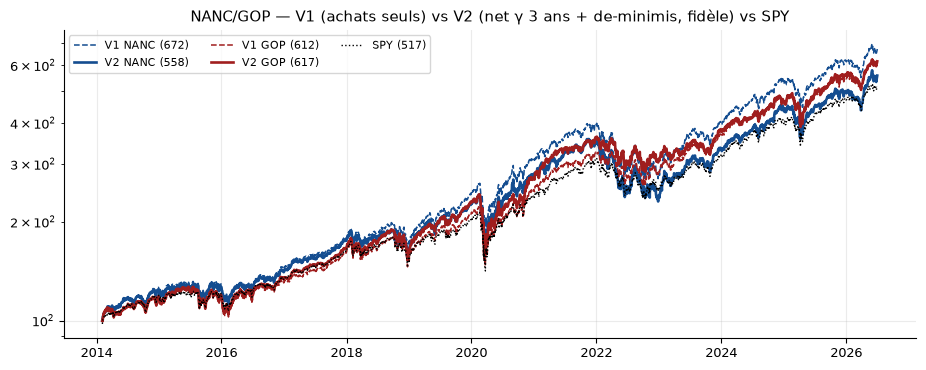

✅ V2 : γ3 = recalcul manuel (à 1e-12) · exemple net = 3 M$ (attendu 3) · Σw = 1 · poids ≤ 8,5 %
non-régression — γ@504 intact · V1 NANC NAV 672 · GOP NAV 612


In [77]:
# FIGURE NAV V1 vs V2 vs SPY + VALIDATION (Σw=1, poids <= cap) + non-régression V1
navspy2 = (1 + r_spy.reindex(span_nanc2.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(span_nanc.index,  span_nanc,  color=BLEU, lw=1.1, ls="--", label=f"V1 NANC ({span_nanc.iloc[-1]:.0f})")
ax.plot(span_nanc2.index, span_nanc2, color=BLEU, lw=1.9,          label=f"V2 NANC ({span_nanc2.iloc[-1]:.0f})")
ax.plot(span_gop.index,   span_gop,   color=ROUGE, lw=1.1, ls="--", label=f"V1 GOP ({span_gop.iloc[-1]:.0f})")
ax.plot(span_gop2.index,  span_gop2,  color=ROUGE, lw=1.9,          label=f"V2 GOP ({span_gop2.iloc[-1]:.0f})")
ax.plot(navspy2.index, navspy2, color="k", lw=1.0, ls=":", label=f"SPY ({navspy2.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend(ncol=3, fontsize=8)
ax.set_title("NANC/GOP — V1 (achats seuls) vs V2 (net γ 3 ans + de-minimis, fidèle) vs SPY")
plt.savefig(f"{FIGS}/nanc_v1v2.png", dpi=150, bbox_inches="tight"); plt.show()

# VALIDATION §13.2 (règle : tout calcul ajouté est vérifié)
# (a) γ3 recalculé À LA MAIN sur une vente réelle == gam3 (seuil 756 j)
idx_t = next(i for i, (p, r) in VENTES.items() if p)          # une vente avec lots appariés
p_, r_ = VENTES[idx_t]; tot_ = sum(q for _, q in p_) + r_
g3_hand = (sum(q for h, q in p_ if h <= A_BAR3) + r_) / tot_
assert abs(g3_hand - gam3[idx_t]) < 1e-12, "gam3 ≠ recalcul manuel"
# (b) l'exemple du plan : achats 10 (4 ans, hors fenêtre) + 5 (1 an), vente 12 → γ3=2/12, net=[5−12·γ3]⁺=3
net_ex = max(0.0, 5.0 - 12.0 * (2.0 / 12.0))
assert abs(net_ex - 3.0) < 1e-12, "exemple net ≠ 3"
# (c) Σw = 1 partout ; poids ≤ cap dès que faisable
nmin_cap, cap_ok, worst = int(np.ceil(1 / 0.085)), True, 0.0
for i in coupes[:-1]:
    w = poids_parti_v2(i, "Democrat")
    if not w: continue
    assert abs(sum(w.values()) - 1) < 1e-9, f"V2 Σw != 1 à {i}"
    if len(w) >= nmin_cap and max(w.values()) > 0.085 + 1e-9:
        cap_ok, worst = False, max(worst, max(w.values()))
assert cap_ok, f"V2 cap 8,5% non respecté malgré >= {nmin_cap} titres (max {worst:.3f})"
print(f"✅ V2 : γ3 = recalcul manuel (à 1e-12) · exemple net = {net_ex:.0f} M$ (attendu 3) · Σw = 1 · poids ≤ 8,5 %")
# (d) non-régression : γ@504 du ticker et les ancres V1 n'ont PAS bougé (V2 est additif)
assert abs(df.loc[idx_t, "gamma"] - (sum(q for h, q in p_ if h <= A_BAR) + r_) / tot_) < 1e-12, "γ@504 modifié !"
print(f"non-régression — γ@504 intact · V1 NANC NAV {span_nanc.iloc[-1]:.0f} · GOP NAV {span_gop.iloc[-1]:.0f}")
assert span_nanc.iloc[-1] > 100 and span_gop.iloc[-1] > 100, "V1 a bougé ?!"

### §13.3 — V2 **sans le cap 8,5 %** : la vraie diversification émerge-t-elle ?

Le cap 8,5 % est un **ajout maison** (hors prospectus, qui dit seulement « non-diversified »). On refait V2 en le
**retirant** (`cap=1.0` ; netting $\gamma$, de-minimis et [100,200] **conservés**) pour voir si le score $s_i=\text{net}_i\times m_i$
reproduit **seul** la décroissance **douce** du vrai NANC (NVDA 8,5 → GOOG 5,8 → MSFT 5,3…), ou s'il **explose au sommet**.
On mesure la concentration : poids du 1ᵉʳ, somme du top-5, **N effectif** $=1/\sum_i w_i^2$.

In [78]:
# V2 SANS cap (cap=1.0 => cap_poids ne coupe rien) — de-minimis et [100,200] conservés
WP_nanc2nc = {i: poids_parti_v2(i, "Democrat",   cap=1.0) for i in coupes[:-1]}
WP_gop2nc  = {i: poids_parti_v2(i, "Republican", cap=1.0) for i in coupes[:-1]}
span_nanc2nc, _ = run_livre(WP_nanc2nc, np.inf)
span_gop2nc,  _ = run_livre(WP_gop2nc,  np.inf)
for i in coupes[:-1]:
    w = WP_nanc2nc[i]
    if w: assert abs(sum(w.values()) - 1) < 1e-9, f"sans-cap Σw != 1 à {i}"
pd.DataFrame([bilan(span_nanc2,   "V2 NANC — cap 8,5 %"),
             bilan(span_nanc2nc, "V2 NANC — SANS cap"),
             bilan(span_gop2,    "V2 GOP — cap 8,5 %"),
             bilan(span_gop2nc,  "V2 GOP — SANS cap")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"V2 NANC — cap 8,5 %",1.403,0.734,-0.498,-0.353,1.080,557.996,9/13
V2 NANC — SANS cap,2.585,1.075,0.806,0.374,1.087,621.792,8/13
"V2 GOP — cap 8,5 %",1.340,1.413,1.150,0.890,1.008,616.603,9/13
V2 GOP — SANS cap,2.291,2.413,2.090,1.392,1.000,679.534,9/13


In [79]:
# Concentration & fidélité : vrai NANC vs V2-cap vs V2-sans-cap (coupe récente)
rep2nc = (pd.Series(poids_parti_v2(coupes[-2], "Democrat", cap=1.0)).sort_values(ascending=False) * 100)
realpc = (real.assign(tk=real.StockTicker.map(lambda t: FUSION.get(t, t)))
              .groupby("tk").w.sum().sort_values(ascending=False))
def _conc(w):                                       # w en %, trié décroissant
    p = (w / w.sum()).values
    return w.iloc[0], w.head(5).sum(), 1 / np.sum(p**2)         # top-1, top-5, N effectif
print("Concentration (coupe récente) :")
for nom, w in [("vrai NANC", realpc), ("V2 cap 8,5%", rep2), ("V2 SANS cap", rep2nc)]:
    t1, t5, neff = _conc(w)
    print(f"  {nom:12s} — top-1 {t1:5.1f}% · top-5 {t5:5.1f}% · N effectif {neff:4.1f} · {len(w)} titres")
r_c, e_c   = _fid(rep2)
r_nc, e_nc = _fid(rep2nc)
print(f"\nfidélité vs vrai NANC — V2 cap : ρ {r_c:.2f} expo {e_c:.0f}%  ·  V2 SANS cap : ρ {r_nc:.2f} expo {e_nc:.0f}%")
cmp3 = pd.DataFrame({
    "vrai NANC":   [f"{t} {w:.1f}%" for t, w in zip(realpc.head(15).index, realpc.head(15).values)],
    "V2 cap":      [f"{t} {w:.1f}%" for t, w in zip(rep2.head(15).index,   rep2.head(15).values)],
    "V2 sans cap": [f"{t} {w:.1f}%" for t, w in zip(rep2nc.head(15).index, rep2nc.head(15).values)]})
cmp3.index = range(1, 16); display(cmp3)

Concentration (coupe récente) :
  vrai NANC    — top-1   8.5% · top-5  29.5% · N effectif 33.2 · 104 titres
  V2 cap 8,5%  — top-1   8.5% · top-5  42.4% · N effectif 18.9 · 100 titres
  V2 SANS cap  — top-1  37.0% · top-5  66.1% · N effectif  6.0 · 100 titres

fidélité vs vrai NANC — V2 cap : ρ 0.67 expo 48%  ·  V2 SANS cap : ρ 0.68 expo 41%


,vrai NANC,V2 cap,V2 sans cap
1,NVDA 8.5%,NVDA 8.5%,NVDA 37.0%
2,GOOG 5.8%,AMZN 8.5%,AMZN 10.7%
3,MSFT 5.3%,MSFT 8.5%,MSFT 7.5%
4,AMAT 5.2%,AVGO 8.5%,AVGO 6.1%
5,AMZN 4.7%,GOOG 8.4%,GOOG 4.9%
6,AAPL 4.6%,PANW 8.1%,PANW 4.8%
7,CRWD 3.4%,META 6.0%,META 3.5%
8,PM 3.2%,AAPL 5.8%,AAPL 3.4%
9,AXP 2.8%,TSM 3.5%,TSM 2.1%
10,LLY 2.7%,NFLX 2.1%,NFLX 1.2%


### §13.4 — Pourquoi notre portefeuille n'est PAS celui de NANC/GOP (les 2 fonds réels)

Alice : « même stratégie $\Rightarrow$ même portefeuille, non ? ». On confronte notre réplique **V2** aux **holdings
réels** des deux ETF (24/07/2026, `cache/{NANC,GOP}_holdings_20260724.csv`). Pour chaque position réelle : notre
poids vs le leur, le nombre d'élus et le \$ d'achats **dans NOS données** (fenêtre 3 ans), et l'**origine de l'écart** :
- **présent** : les achats existent chez nous $\Rightarrow$ l'écart est de la **pondération** ;
- **trou** : quasi aucun achat chez nous ($\#$élus $=0$ ou $<0{,}05$ M\$) $\Rightarrow$ **donnée manquante** ;
- **hors-univers** : pas de prix / privé / ETF / spin-off (SpaceX, IBIT, HONA…).

Attendu (diagnostic) : **NANC $\approx$ tout présent** (leurs poids ne suivent pas le flux 3 ans --- AMAT 5,2 \% avec
3 élus vs AVGO 1,2 \% avec 10) ; **GOP** a un vrai **trou** (FIX, leur \#1 à 8,4 \%) $+$ des noms **hors-univers**.

In [80]:
def real_holdings(f):
    r = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/{f}")
    r = r[~r.StockTicker.isin(["Cash&Other", "FGXXX"])].copy()
    r["w"] = r.Weightings.str.rstrip("%").astype(float)
    return r.sort_values("w", ascending=False).reset_index(drop=True)

real_gop = real_holdings("GOP_holdings_20260724.csv")
rep2_gop = (pd.Series(poids_parti_v2(coupes[-2], "Republican")).sort_values(ascending=False) * 100)
assert 95 < real.w.sum() < 101 and 95 < real_gop.w.sum() < 101, "somme poids réels ≠ ~100 %"

def diag(parti, rh, repw):
    # par position réelle : notre poids V2, #élus & $ d'achats chez nous (fenêtre 3 ans à la coupe récente), bucket
    i1 = coupes[-2]
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")].assign(tkm=lambda x: x.tk.map(lambda t: FUSION.get(t, t)))
    nb, dol, ntr = g.groupby("tkm").bioguide_id.nunique(), g.groupby("tkm").A.sum() / 1e6, g.groupby("tkm").size()
    rows = []
    for _, r in rh.iterrows():
        t   = FUSION.get(r.StockTicker, r.StockTicker)
        nel, dm, nt = int(nb.get(t, 0)), float(dol.get(t, 0.0)), int(ntr.get(t, 0))
        bucket = "hors-univers" if t not in PXV else ("trou" if (nel == 0 or dm < 0.05) else "présent")
        rows.append((r.StockTicker, round(r.w, 2), round(float(repw.get(t, 0.0)), 2), nel, round(dm, 2), nt, bucket))
    return pd.DataFrame(rows, columns=["ticker", "réel%", "notre%", "#élus", "$M", "#tr", "bucket"])

dN = diag("Democrat",   real,     rep2)
dG = diag("Republican", real_gop, rep2_gop)
for nom, d in [("NANC", dN), ("GOP", dG)]:
    part = d.groupby("bucket")["réel%"].sum().reindex(["présent", "trou", "hors-univers"]).fillna(0)
    print(f"{nom} — part du portefeuille réel par ORIGINE de l'écart : "
          f"présent/mal-pesé {part['présent']:.0f}% · trou de données {part['trou']:.0f}% · hors-univers {part['hors-univers']:.0f}%")
print("\nNANC — top-15 réel vs notre réplique V2 :"); display(dN.head(15))
print("GOP — top-15 réel vs notre réplique V2 :");  display(dG.head(15))

NANC — part du portefeuille réel par ORIGINE de l'écart : présent/mal-pesé 94% · trou de données 5% · hors-univers 1%
GOP — part du portefeuille réel par ORIGINE de l'écart : présent/mal-pesé 79% · trou de données 16% · hors-univers 5%

NANC — top-15 réel vs notre réplique V2 :


,ticker,réel%,notre%,#élus,$M,#tr,bucket
0,NVDA,8.53,8.50,16,16.68,99,présent
1,GOOG,5.81,8.39,16,3.83,88,présent
2,MSFT,5.29,8.50,14,3.49,88,présent
3,AMAT,5.19,0.28,3,0.41,21,présent
4,AMZN,4.70,8.50,13,3.77,93,présent
5,AAPL,4.58,5.80,13,3.00,73,présent
6,CRWD,3.41,0.00,3,0.25,25,présent
7,PM,3.20,0.00,2,0.32,25,présent
8,AXP,2.84,0.19,4,0.23,19,présent
9,LLY,2.71,0.41,10,0.45,35,présent


GOP — top-15 réel vs notre réplique V2 :


,ticker,réel%,notre%,#élus,$M,#tr,bucket
0,FIX,8.44,0.00,1,0.02,2,trou
1,INTC,5.51,0.24,8,1.35,30,présent
2,JPM,4.47,3.09,18,0.48,37,présent
3,NVDA,3.22,7.44,21,1.97,74,présent
4,ANET,3.22,0.00,7,0.62,18,présent
5,IBIT,3.00,0.00,0,0.00,0,hors-univers
6,AMD,2.95,2.45,13,1.07,40,présent
7,ALL,2.12,0.00,2,0.09,3,présent
8,UTHR,2.07,0.00,1,0.02,2,trou
9,ASML,1.98,0.27,5,0.46,25,présent


GOP (nouveau) — recouvrement top-10 3/10 · top-15 4/15 · ρ 0.11 · exposition commune 27%  (vs NANC ρ 0.67)


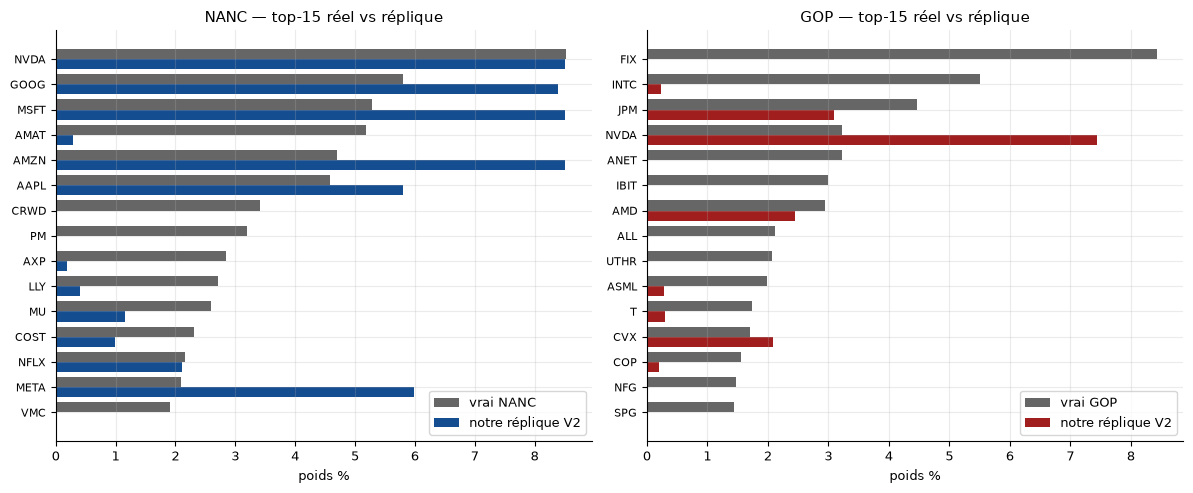

In [81]:
# GOP : recouvrement + ρ (nouveau — on ne l'avait que pour NANC)
realw_g = real_gop.assign(tk=real_gop.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
Mg = pd.DataFrame({"reel": realw_g,
                   "rep": rep2_gop.groupby(rep2_gop.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
rho_g = Mg[(Mg.reel > 0) | (Mg.rep > 0)].corr().iloc[0, 1]
com_g = float(Mg[["reel", "rep"]].min(axis=1).sum())
_recg = lambda rp, rh, n: len(set(rp.head(n).index) & set(rh.head(n).StockTicker))
print(f"GOP (nouveau) — recouvrement top-10 {_recg(rep2_gop, real_gop, 10)}/10 · "
      f"top-15 {_recg(rep2_gop, real_gop, 15)}/15 · ρ {rho_g:.2f} · exposition commune {com_g:.0f}%  "
      f"(vs NANC ρ {_fid(rep2)[0]:.2f})")

# figure : réel (gris) vs notre réplique V2, top-15, NANC | GOP
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (nom, rh, repw, col) in zip(ax, [("NANC", real, rep2, BLEU), ("GOP", real_gop, rep2_gop, ROUGE)]):
    rg = (rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
            .sort_values(ascending=False).head(15).iloc[::-1])
    rp = repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()
    yy, h = np.arange(len(rg)), 0.4
    a.barh(yy + h/2, rg.values, h, color=GRIS, label=f"vrai {nom}")
    a.barh(yy - h/2, [rp.get(t, 0.0) for t in rg.index], h, color=col, label="notre réplique V2")
    a.set_yticks(yy); a.set_yticklabels(rg.index, fontsize=8); a.set_xlabel("poids %"); a.legend(); a.set_title(f"{nom} — top-15 réel vs réplique")
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_gop_diag.png", dpi=150, bbox_inches="tight"); plt.show()

### §13.5 — Variante 3 : **le livre du fonds** (leur vraie mécanique, événementielle)

Le diagnostic §13.4 montre que nos poids divergent des leurs **alors que la donnée est là** (NANC 94 \% présent).
Relecture du prospectus : le fonds ne recalcule PAS un score chaque mois — *\og the Fund will typically buy or sell
a security \textbf{when} a position is reported as being bought or sold\fg* . C'est un **livre événementiel** :

1. **Livre initial** à la création $t_0 = $ 2023-02-07 : par (élu $m$, titre $i$), net\$ $\gamma'$ des trades
   divulgués sur $(t_0 - 3\,\text{ans},\ t_0]$, plancher 0, agrégé ; converti en **parts au prix de $t_0$** :
   $q_i(t_0) = \bigl[\sum_m \text{net}^{\$}_{m,i}\bigr] / P_i(t_0)$ (le fonds achète son livre initial aux prix de la création).
2. **Ensuite, à chaque divulgation** $\delta_k$ (close J+1) : un **achat** ajoute $A_k/P(\delta_k)$ parts ;
   une **vente** retire $\gamma'_k\, A_k / P(\delta_k)$ parts (bornée aux parts détenues).
3. **$\gamma'_k$** = part de la vente sur lots détenus $\le 3$ ans, avec le **non-apparié compté VIEUX**
   ($\gamma' = \sum q[h\le756] / (\sum q + \text{reste})$) — le prospectus : la vente d'actions acquises avant le
   suivi **n'ajuste pas** le portefeuille. ($\ne$ le $\gamma_3$ de V2, qui compte le non-apparié récent.)
4. **Aucun rebalancement, aucun cap** : entre les événements les parts sont fixes, les poids **dérivent avec les
   prix** : $w_i(t) = q_i P_i(t) / \sum_j q_j P_j(t)$. La fenêtre 3 ans ne fait PAS oublier les positions.

C'est cette dérive qui doit recréer AMAT $\sim$5 \% (achats 2020-22, titre $\times$3), FIX \#1 du GOP (achats 2020,
$\times$13) et faire redescendre NVDA vers $\sim$8,5 \% **sans cap**. On teste.

In [82]:
# γ'3 : part récente d'une vente, le NON-APPARIÉ compté VIEUX (≠ gam3 : prospectus dit explicitement que
# la vente d'actions acquises avant le suivi n'ajuste pas le portefeuille → sans lot datable, on n'ajuste pas)
g3p = np.zeros(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot > 0: g3p[idx] = sum(q for h, q in pieces if h <= A_BAR3) / tot
df["g3p"] = np.where(df.op.values == "buy", 1.0, g3p)

I_T0 = int(cal.searchsorted(pd.Timestamp("2023-02-07"), side="left"))     # création NANC & GOP
print(f"t0 = {cal[I_T0].date()} (création des deux ETF)")

def prep_parti(parti):
    sub = df.iloc[ordre_d]                                    # trié par δ (chronologique)
    sub = sub[sub.party.values == parti]
    return sub.assign(tkm=sub.tk.map(lambda t: FUSION.get(t, t)))

def livre_fonds(sub, i_eval):
    # 1) livre initial : net$ γ' par (élu, titre) sur (t0-3ans, t0], plancher 0, en parts au prix de t0
    ini    = sub[(sub.ide.values > I_T0 - W3) & (sub.ide.values <= I_T0)]
    signed = ini.A.values * np.where(ini.op.values == "buy", 1.0, -1.0) * ini.g3p.values
    per    = pd.Series(signed).groupby([ini.bioguide_id.values, ini.tkm.values]).sum()
    net0   = per[per > 0].groupby(level=1).sum()
    q = {t: v / PXV[t][I_T0] for t, v in net0.items()
         if t in PXV and np.isfinite(PXV[t][I_T0]) and PXV[t][I_T0] > 0 and vivant(t, I_T0)}
    # 2) événements post-t0 : achat ajoute A/P(δ), vente retire γ'·A/P(δ) (borné) — close J+1
    ev = sub[(sub.ide.values > I_T0) & (sub.ide.values <= i_eval)]
    for tkm, ide, op, A, g in zip(ev.tkm.values, ev.ide.values, ev.op.values, ev.A.values, ev.g3p.values):
        j = min(ide + 1, len(cal) - 1)
        if tkm not in PXV or not np.isfinite(PXV[tkm][j]) or PXV[tkm][j] <= 0: continue
        if op == "buy":            q[tkm] = q.get(tkm, 0.0) + A / PXV[tkm][j]
        elif tkm in q:             q[tkm] = max(0.0, q[tkm] - g * A / PXV[tkm][j])
    # 3) valorisation à i_eval : les poids ont dérivé avec les prix (aucun cap, aucun rebalancement)
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

sub_D, sub_R = prep_parti("Democrat"), prep_parti("Republican")
rep3   = (pd.Series(livre_fonds(sub_D, coupes[-2])).sort_values(ascending=False) * 100)
rep3_g = (pd.Series(livre_fonds(sub_R, coupes[-2])).sort_values(ascending=False) * 100)
print(f"V3 — NANC {len(rep3)} titres · GOP {len(rep3_g)} titres (réels : {len(real)} · {len(real_gop)})")

t0 = 2023-02-07 (création des deux ETF)
V3 — NANC 1239 titres · GOP 1134 titres (réels : 104 · 139)


In [83]:
# FIDÉLITÉ réel vs V1 / V2 / V3 — les deux fonds, même métrique partout
def fid_full(repw, rh):
    rw = rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
    Mx = pd.DataFrame({"reel": rw, "rep": repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
    rho = Mx[(Mx.reel > 0) | (Mx.rep > 0)].corr().iloc[0, 1]
    com = float(Mx[["reel", "rep"]].min(axis=1).sum())
    r10 = len(set(repw.head(10).index) & set(rh.head(10).StockTicker))
    r15 = len(set(repw.head(15).index) & set(rh.head(15).StockTicker))
    return r10, r15, rho, com
# + la couche SÉLECTION du prospectus (100-200 titres, de-minimis) : top-N du livre (N = titres du fonds réel), renormalisé
rep3t   = (rep3.head(len(real)) / rep3.head(len(real)).sum() * 100)
rep3t_g = (rep3_g.head(len(real_gop)) / rep3_g.head(len(real_gop)).sum() * 100)
rows = []
for nom, repw, rh in [("NANC V1 (score achats)", rep, real), ("NANC V2 (score net γ)", rep2, real),
                      ("NANC V3 (livre du fonds)", rep3, real), ("NANC V3 + sélection 104", rep3t, real),
                      ("GOP V2 (score net γ)", rep2_gop, real_gop), ("GOP V3 (livre du fonds)", rep3_g, real_gop),
                      ("GOP V3 + sélection 139", rep3t_g, real_gop)]:
    r10, r15, rho_, com_ = fid_full(repw, rh)
    rows.append({"réplique": nom, "top-10": f"{r10}/10", "top-15": f"{r15}/15", "ρ": round(rho_, 2), "expo commune %": round(com_)})
display(pd.DataFrame(rows).set_index("réplique"))

# check-points nommés (le test de la règle)
print("Check-points (attendus si la règle est la bonne) :")
for t, attendu in [("NVDA", "≈8,5 réel"), ("AMAT", "5,2 réel"), ("CRWD", "3,4"), ("AXP", "2,8"), ("MU", "2,6"), ("VMC", "1,9"), ("PM", "3,2")]:
    print(f"  NANC {t:5s} — V3 {rep3.get(t, 0.0):5.2f} % vs réel {attendu}  (V2 {rep2.get(t, 0.0):.2f}, V1 {rep.get(t, 0.0):.2f})")
for t, attendu in [("FIX", "8,4 réel"), ("UTHR", "2,1"), ("ANET", "3,2"), ("INTC", "5,5"), ("NVDA", "3,2")]:
    print(f"  GOP  {t:5s} — V3 {rep3_g.get(t, 0.0):5.2f} % vs réel {attendu}  (V2 {rep2_gop.get(t, 0.0):.2f})")
cmp5 = pd.DataFrame({
    "vrai NANC": [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker", "w"]].values],
    "V3 NANC":   [f"{t} {w:.1f}%" for t, w in zip(rep3.head(15).index, rep3.head(15).values)],
    "vrai GOP":  [f"{t} {w:.1f}%" for t, w in real_gop.head(15)[["StockTicker", "w"]].values],
    "V3 GOP":    [f"{t} {w:.1f}%" for t, w in zip(rep3_g.head(15).index, rep3_g.head(15).values)]})
cmp5.index = range(1, 16); display(cmp5)

,top-10,top-15,ρ,expo commune %
réplique,,,,
NANC V1 (score achats),5/10,7/15,0.73,51
NANC V2 (score net γ),5/10,9/15,0.67,48
NANC V3 (livre du fonds),5/10,8/15,0.74,46
NANC V3 + sélection 104,5/10,8/15,0.70,50
GOP V2 (score net γ),3/10,4/15,0.11,27
GOP V3 (livre du fonds),0/10,0/15,0.16,26
GOP V3 + sélection 139,0/10,0/15,0.02,26


Check-points (attendus si la règle est la bonne) :
  NANC NVDA  — V3  8.93 % vs réel ≈8,5 réel  (V2 8.50, V1 8.50)
  NANC AMAT  — V3  0.31 % vs réel 5,2 réel  (V2 0.28, V1 0.21)
  NANC CRWD  — V3  1.38 % vs réel 3,4  (V2 0.00, V1 0.13)
  NANC AXP   — V3  0.65 % vs réel 2,8  (V2 0.19, V1 0.15)
  NANC MU    — V3  7.73 % vs réel 2,6  (V2 1.16, V1 0.62)
  NANC VMC   — V3  0.12 % vs réel 1,9  (V2 0.00, V1 0.00)
  NANC PM    — V3  0.05 % vs réel 3,2  (V2 0.00, V1 0.11)
  GOP  FIX   — V3  0.52 % vs réel 8,4 réel  (V2 0.00)
  GOP  UTHR  — V3  0.43 % vs réel 2,1  (V2 0.00)
  GOP  ANET  — V3  0.36 % vs réel 3,2  (V2 0.00)
  GOP  INTC  — V3  1.04 % vs réel 5,5  (V2 0.24)
  GOP  NVDA  — V3  0.93 % vs réel 3,2  (V2 7.44)


,vrai NANC,V3 NANC,vrai GOP,V3 GOP
1,NVDA 8.5%,NVDA 8.9%,FIX 8.4%,WDC 12.3%
2,GOOG 5.8%,MU 7.7%,INTC 5.5%,AMZN 4.3%
3,MSFT 5.3%,GOOG 5.0%,JPM 4.5%,AVGO 3.9%
4,AMAT 5.2%,MSFT 3.8%,NVDA 3.2%,ORCL 3.9%
5,AMZN 4.7%,AMZN 3.0%,ANET 3.2%,GNRC 2.7%
6,AAPL 4.6%,NFLX 1.9%,IBIT 3.0%,EA 2.5%
7,CRWD 3.4%,AVGO 1.7%,AMD 3.0%,RTX 2.2%
8,PM 3.2%,DIS 1.6%,ALL 2.1%,WFC 1.7%
9,AXP 2.8%,TSLA 1.4%,UTHR 2.1%,NOW 1.4%
10,LLY 2.7%,CRWD 1.4%,ASML 2.0%,TXN 1.3%


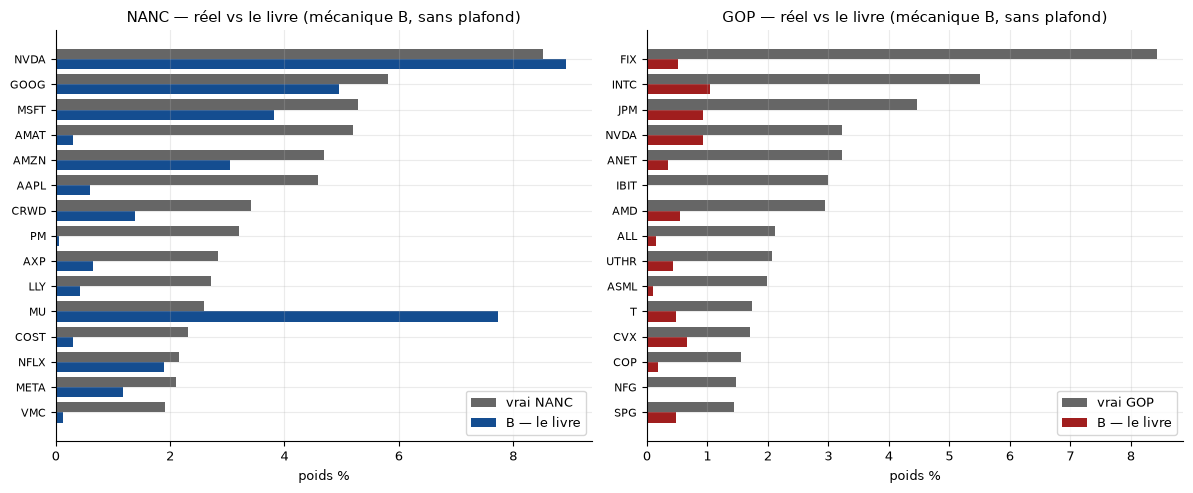

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V3 NANC (livre) depuis 2023-02,-0.212,-0.142,-1.520,-0.900,1.028,196.744,1/4
V3 GOP (livre) depuis 2023-02,-1.467,-0.331,-0.144,-0.049,0.890,188.737,1/4


In [84]:
# FIGURE réel vs V3 (top-15, les 2 fonds) + bilan performance V3 depuis t0
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (nom, rh, repw, col) in zip(ax, [("NANC", real, rep3, BLEU), ("GOP", real_gop, rep3_g, ROUGE)]):
    rg = (rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
            .sort_values(ascending=False).head(15).iloc[::-1])
    rp = repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()
    yy, h = np.arange(len(rg)), 0.4
    a.barh(yy + h/2, rg.values, h, color=GRIS, label=f"vrai {nom}")
    a.barh(yy - h/2, [rp.get(t, 0.0) for t in rg.index], h, color=col, label="B — le livre")
    a.set_yticks(yy); a.set_yticklabels(rg.index, fontsize=8); a.set_xlabel("poids %"); a.legend()
    a.set_title(f"{nom} — réel vs le livre (mécanique B, sans plafond)")
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_gop_v3.png", dpi=150, bbox_inches="tight"); plt.show()

coupes_v3 = [i for i in coupes if i >= I_T0]
WP_nanc3  = {i: livre_fonds(sub_D, i) for i in coupes_v3[:-1]}
WP_gop3   = {i: livre_fonds(sub_R, i) for i in coupes_v3[:-1]}
span_n3, _ = run_livre(WP_nanc3, np.inf, cuts=coupes_v3)
span_g3, _ = run_livre(WP_gop3,  np.inf, cuts=coupes_v3)
pd.DataFrame([bilan(span_n3, "V3 NANC (livre) depuis 2023-02"),
             bilan(span_g3, "V3 GOP (livre) depuis 2023-02")]).set_index("run").round(3)

In [85]:
# VALIDATION §13.5 (règle : tout calcul ajouté est vérifié)
# (a) γ' recalculé à la main sur une vente réelle == df.g3p, et invariant γ' ≤ γ3 (reste basculé récent→vieux)
idx_v = next(i for i, (p, r) in VENTES.items() if p and r > 0)      # une vente avec lots ET du non-apparié
p_, r_ = VENTES[idx_v]; tot_ = sum(q for _, q in p_) + r_
gp_hand = sum(q for h, q in p_ if h <= A_BAR3) / tot_               # reste compté VIEUX (exclu du numérateur)
assert abs(gp_hand - df.g3p.iloc[idx_v]) < 1e-12, "γ' ≠ recalcul manuel"
sells = df.op.values == "sell"
assert (df.g3p.values[sells] <= gam3[sells] + 1e-12).all(), "γ' > γ3 quelque part ?!"
# (b) mini-exemple ARITHMÉTIQUE de la mécanique du livre (hors moteur) :
#     achat 100 $ pré-t0 (P=10) → 10 parts · achat 50 $ post-t0 (P=25) → +2 · vente d'un VIEUX lot (γ'=0) → rien
#     valorisation à P=30 → 12 parts × 30 = 360 $, poids 100 %
q_ = 100.0 / 10.0
q_ += 50.0 / 25.0
q_ -= 0.0 * (80.0 / 25.0)                                           # vente vieux lot : γ'=0, livre inchangé
assert abs(q_ * 30.0 - 360.0) < 1e-12, "mini-exemple livre ≠ 360"
# (c) Σw = 1 et parts ≥ 0 pour les deux fonds ; (d) non-régression V1/V2 (additif) + gam3 intact
for w in (rep3, rep3_g): assert abs(w.sum() - 100) < 1e-6 and (w.values >= 0).all()
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé ?!"
assert abs(gam3[idx_v] - (sum(q for h, q in p_ if h <= A_BAR3) + r_) / tot_) < 1e-12, "gam3 modifié !"
print("✅ V3 : γ' = recalcul manuel (1e-12) · γ' ≤ γ3 partout · mini-exemple 360 $ OK · Σw = 1 · V1/V2/γ3 intacts")

✅ V3 : γ' = recalcul manuel (1e-12) · γ' ≤ γ3 partout · mini-exemple 360 $ OK · Σw = 1 · V1/V2/γ3 intacts


### §13.6 — Réparations de DONNÉES (audit forensique) : que gagne-t-on, réparation par réparation ?

L'audit de notre chaîne a trouvé 3 défauts objectifs (aucun réglage de poids — anti-overfit) :

1. **Prix manquants** : 14,9 k trades jetés faute de fichier prix. La plupart = sociétés **réellement radiées**
   (rachats : ATVI, CELG, VMW… — Yahoo ne sert plus leur historique = survivorship de la source). Mais **10
   renommages continus** récupérés (MMC→MRSH, FI→FISV, NLOK→GEN, CNHI→CNH…) → `cache/prices_v2_recup/`
   (quarantaine : les sections précédentes n'y touchent pas, non-régression préservée).
2. **892 documents OCR parsés jamais intégrés** (gating des scans manuscrits/tournés) : **7 287 transactions**
   résolues (ticker+date+montant+δ), dont **6 482 républicaines** (biais du gating ×6,4 : McCaul 2015-16 ~5 k,
   Harshbarger…) → `cache/recup_ocr_gated.csv`. Touche surtout 2014-2019 (V1/V2) ; le flux 2020+ utile à V3 est
   modeste (~35 M\$ Rep, en partie des ETF larges que le fonds exclut de toute façon).
3. **Brackets ouverts au plancher** : 412 lignes \og SP/DC over \$1,000,000\fg{} valorisées 1 000 001 \$ (100 \%
   républicaines : Harshbarger 379, McCaul 33). Sensibilité : plancher (1,0 M) vs milieu du bracket supérieur (3,0 M).

On reconstruit le flux **réparé** (df ∪ récupérations, γ recalculé) et on re-mesure la fidélité V1/V2/V3 aux deux
fonds réels. Chaque effet est mesuré **séparément** ; les métriques (recouvrement, $\rho$, exposition commune)
étaient figées avant.

In [86]:
# ── Réparation des données : construction du flux réparé (df2) — les globals sont restaurés à la fin ──
import os
_PXR = f"{RACINE}/00. S3S4 en cours/cache/prices_v2_recup"
_sauv = dict(df=df, ordre_d=ordre_d, I_de=I_de, PXV_new=[], NF={}, NL={})

# 1) prix récupérés (renommages continus) → PXV + vivant
for f in sorted(os.listdir(_PXR)):
    tk = f[:-4]
    s = pd.read_csv(f"{_PXR}/{f}", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
    PXV[tk] = s.reindex(cal).ffill().to_numpy()
    _sauv["PXV_new"].append(tk)
    _sauv["NF"][tk], _sauv["NL"][tk] = NFIRST.get(tk), NLAST.get(tk)
    NFIRST[tk] = int(np.argmax(~np.isnan(PXV[tk])))
    NLAST[tk]  = cal.searchsorted(s.index[-1], side="right") - 1
print(f"prix récupérés chargés : {len(_sauv['PXV_new'])} → {_sauv['PXV_new']}")

# 2) transactions OCR récupérées (892 docs gated, tickers résolus)
rec = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/recup_ocr_gated.csv", parse_dates=["tau", "delta"])
bmap = df.drop_duplicates("member_name").set_index("member_name").bioguide_id.to_dict()
rec["bioguide_id"] = rec.member_name.map(bmap).fillna(rec.member_name)
rec = rec[rec.tk.isin(PXV)]                                   # même règle d'univers que le flux principal
rec = rec[(rec.tau >= "2014-01-01")]
print(f"transactions OCR intégrables (ticker dans l'univers prix) : {len(rec):,} · {rec.A.sum()/1e6:.0f} M$ "
      f"· Rep {len(rec[rec.party=='Republican']):,}")

# 3) flux réparé df2 (colonnes minimales du moteur) + γ' recalculé sur le flux complet
colz = ["bioguide_id", "member_name", "party", "tk", "op", "A", "tau"]
d2a = df[colz + ["ide"]].copy(); d2a["src"] = "base"; d2a["K"] = False
d2b = rec[colz].copy()
d2b["ide"] = cal.searchsorted(rec.delta.values, side="left")
d2b["src"] = "ocr"; d2b["K"] = (rec.amount_code == "K").values
df2 = pd.concat([d2a, d2b], ignore_index=True)
df2 = df2[df2.ide < len(cal)].reset_index(drop=True)
df2["i0"] = cal.searchsorted(df2.tau.values, side="left").clip(0, len(cal) - 1)
df2["K"] = df2.K | np.isclose(df2.A.values, 1000001.0)        # brackets ouverts (plancher) du flux de base
VENT2 = {}
for (_, _), g in df2.groupby(["bioguide_id", "tk"], sort=False):
    VENT2.update(tranches_vendues(g))
g3p2 = np.zeros(len(df2))
for idx, (pieces, reste) in VENT2.items():
    tot = sum(q for _, q in pieces) + reste
    if tot > 0: g3p2[idx] = sum(q for h, q in pieces if h <= A_BAR3) / tot
df2["g3p"]     = np.where(df2.op.values == "buy", 1.0, g3p2)
df2["signed3"] = df2.A * np.where(df2.op == "buy", 1.0, -1.0) * df2.g3p
print(f"flux réparé : {len(df2):,} lignes (base {len(d2a):,} + OCR {len(d2b):,}) · brackets ouverts K : {int(df2.K.sum())}")

prix récupérés chargés : 10 → ['ABB', 'CMCSK', 'CNHI', 'DSW', 'FI', 'MMC', 'NLOK', 'PEAK', 'TTS', 'XON']
transactions OCR intégrables (ticker dans l'univers prix) : 5,236 · 242 M$ · Rep 4,532


flux réparé : 118,605 lignes (base 113,369 + OCR 5,236) · brackets ouverts K : 349


In [87]:
# ── Re-mesure de la fidélité APRÈS réparations (V1/V2/V3, les 2 fonds) puis restauration des globals ──
res_rep = {}
try:
    df, ordre_d = df2, np.argsort(df2.ide.values, kind="stable")
    I_de = df2.ide.values[ordre_d]
    r1   = (pd.Series(poids_parti(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
    r2   = (pd.Series(poids_parti_v2(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
    r2g  = (pd.Series(poids_parti_v2(coupes[-2], "Republican")).sort_values(ascending=False) * 100)
    sD, sR = prep_parti("Democrat"), prep_parti("Republican")
    r3   = (pd.Series(livre_fonds(sD, coupes[-2])).sort_values(ascending=False) * 100)
    r3g  = (pd.Series(livre_fonds(sR, coupes[-2])).sort_values(ascending=False) * 100)
    # sensibilité B : brackets ouverts K → 3,0 M$ (milieu du bracket 1-5 M) au lieu du plancher 1,0 M
    df = df2.assign(A=np.where(df2.K, 3000000.5, df2.A))
    df["signed3"] = df.A * np.where(df.op == "buy", 1.0, -1.0) * df.g3p
    sRK = prep_parti("Republican")
    r3gK = (pd.Series(livre_fonds(sRK, coupes[-2])).sort_values(ascending=False) * 100)
    res_rep = dict(r1=r1, r2=r2, r2g=r2g, r3=r3, r3g=r3g, r3gK=r3gK)
finally:
    df, ordre_d, I_de = _sauv["df"], _sauv["ordre_d"], _sauv["I_de"]     # RESTAURATION
    for tk in _sauv["PXV_new"]:
        del PXV[tk]
        if _sauv["NF"][tk] is None: NFIRST.pop(tk, None), NLAST.pop(tk, None)
        else: NFIRST[tk], NLAST[tk] = _sauv["NF"][tk], _sauv["NL"][tk]
assert len(df) == len(_sauv["df"]) and "MMC" not in PXV, "globals mal restaurés !"
print("✅ globals restaurés (df, ordre_d, I_de, PXV/NFIRST/NLAST) — §14 tourne sur le flux d'origine\n")

AVANT = {"NANC V1": (5, "0.73", 51), "NANC V2": (5, "0.67", 48), "NANC V3": (5, "0.74", 46),
         "GOP V2": (3, "0.11", 27), "GOP V3": (0, "0.16", 26)}
rows = []
for nom, repw, rh in [("NANC V1", res_rep["r1"], real), ("NANC V2", res_rep["r2"], real),
                      ("NANC V3", res_rep["r3"], real), ("GOP V2", res_rep["r2g"], real_gop),
                      ("GOP V3", res_rep["r3g"], real_gop), ("GOP V3 + K→3M", res_rep["r3gK"], real_gop)]:
    t10, t15, rho_, com_ = fid_full(repw, rh)
    av = AVANT.get(nom, ("—", "—", "—"))
    rows.append({"réplique": nom, "top-10 avant→après": f"{av[0]} → {t10}",
                 "ρ avant→après": f"{av[1]} → {rho_:.2f}", "expo avant→après": f"{av[2]} → {com_:.0f}%"})
display(pd.DataFrame(rows).set_index("réplique"))
print("Check-points après réparations :")
for t, quoi in [("FIX", "réel 8,4"), ("UTHR", "réel 2,1"), ("INTC", "réel 5,5"), ("WDC", "absent du réel")]:
    print(f"  GOP {t:5s} — V3 réparé {res_rep['r3g'].get(t, 0.0):5.2f} % · +K→3M {res_rep['r3gK'].get(t, 0.0):5.2f} %  ({quoi})")
for t in ["MMC", "AMAT", "CRWD"]:
    print(f"  NANC {t:5s} — V3 réparé {res_rep['r3'].get(t, 0.0):5.2f} %")

✅ globals restaurés (df, ordre_d, I_de, PXV/NFIRST/NLAST) — §14 tourne sur le flux d'origine



,top-10 avant→après,ρ avant→après,expo avant→après
réplique,,,
NANC V1,5 → 5,0.73 → 0.73,51 → 51%
NANC V2,5 → 5,0.67 → 0.66,48 → 49%
NANC V3,5 → 5,0.74 → 0.74,46 → 46%
GOP V2,3 → 3,0.11 → 0.10,27 → 28%
GOP V3,0 → 0,0.16 → 0.16,26 → 27%
GOP V3 + K→3M,— → 0,— → 0.08,— → 17%


Check-points après réparations :
  GOP FIX   — V3 réparé  0.51 % · +K→3M  0.24 %  (réel 8,4)
  GOP UTHR  — V3 réparé  0.41 % · +K→3M  0.19 %  (réel 2,1)
  GOP INTC  — V3 réparé  1.03 % · +K→3M  0.49 %  (réel 5,5)
  GOP WDC   — V3 réparé 12.21 % · +K→3M 16.72 %  (absent du réel)
  NANC MMC   — V3 réparé  0.00 %
  NANC AMAT  — V3 réparé  0.30 %
  NANC CRWD  — V3 réparé  1.38 %


### §13.7 — Les tableaux chiffrés de la fiche (composition, concentration, diagnostic $\lambda$)

Tout ce que la fiche affiche est produit ici, pour être recopié sans retouche :
**(A)** la composition ancrée sur le **top-10 du vrai fonds** (leur poids vs le nôtre, les trois versions, plus
l'écart) ; **(B)** l'erreur **symétrique** (nos plus gros poids *absents* de leur top-10) ; **(C)** le GOP ;
**(D)** la concentration $N_{\text{eff}}=1/\sum_i w_i^2$ ; **(E)** le diagnostic
$\lambda_i = w^{\star}_i \big/ \bigl(F_i/\sum_j F_j\bigr)$ où $F_i$ est le \$ d'achats déclaré du parti sur le titre $i$
--- si le fonds pondérait proportionnellement au flux qu'on observe, $\lambda_i$ serait **constant**.

In [88]:
rep_gop = (pd.Series(poids_parti(coupes[-2], "Republican")).sort_values(ascending=False) * 100)  # V1 GOP (manquait)

def _fus(s):                                    # agrège les classes d'actions (GOOGL→GOOG…)
    return s.groupby(s.index.map(lambda t: FUSION.get(t, t))).sum()

def compo(rh, vers, n=10):
    # ancré sur le top-n du VRAI fonds : w* puis nos versions, + Δ = écart de la version la plus proche
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(n)
    V  = {lab: _fus(s) for lab, s in vers.items()}
    tab = pd.DataFrame({"w* (réel)": rw.round(2)})
    for lab, v in V.items(): tab[lab] = [round(float(v.get(t, 0.0)), 2) for t in rw.index]
    tab["Δ"] = [round(min(abs(float(v.get(t, 0.0)) - rw[t]) for v in V.values()), 2) for t in rw.index]
    # NON compensatoire : Σ min(w*, w_v) — une surpondération ne rachète PAS une sous-pondération
    # (la simple somme Σ w_v laisserait les deux erreurs s'annuler : à ne pas utiliser seule)
    comm = {lab: sum(min(rw[t], float(v.get(t, 0.0))) for t in rw.index) for lab, v in V.items()}
    somme = {lab: sum(float(v.get(t, 0.0)) for t in rw.index) for lab, v in V.items()}
    print(f"  Σ top-{n} réel = {rw.sum():.1f} %")
    print("  recouvrement de poids Σ min(w*, w) : " +
          " · ".join(f"{lab} {comm[lab]:.1f} % = {100*comm[lab]/rw.sum():.0f} % du bloc" for lab in V))
    print("  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : " +
          " · ".join(f"{lab} {somme[lab]:.1f} %" for lab in V) + ")")
    return tab

VN = {"V1": rep,     "V2": rep2,     "V3": rep3}
VG = {"V1": rep_gop, "V2": rep2_gop, "V3": rep3_g}
print("(A) NANC — top-10 du vrai fonds :"); display(compo(real, VN, 10))
print("(C) GOP — top-10 du vrai fonds :");  display(compo(real_gop, VG, 10))

(A) NANC — top-10 du vrai fonds :
  Σ top-10 réel = 46.3 %
  recouvrement de poids Σ min(w*, w) : V1 30.2 % = 65 % du bloc · V2 29.8 % = 64 % du bloc · V3 23.8 % = 51 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : V1 41.4 % · V2 40.6 % · V3 24.2 %)


,w* (réel),V1,V2,V3,Δ
StockTicker,,,,,
NVDA,8.53,8.50,8.50,8.93,0.03
GOOG,5.81,8.50,8.39,4.96,0.85
MSFT,5.29,8.22,8.50,3.81,1.48
AMAT,5.19,0.21,0.28,0.31,4.88
AMZN,4.70,8.24,8.50,3.05,1.65
AAPL,4.58,6.57,5.80,0.61,1.22
CRWD,3.41,0.13,0.00,1.38,2.03
PM,3.20,0.11,0.00,0.05,3.09
AXP,2.84,0.15,0.19,0.65,2.19


(C) GOP — top-10 du vrai fonds :
  Σ top-10 réel = 37.0 %
  recouvrement de poids Σ min(w*, w) : V1 9.4 % = 25 % du bloc · V2 9.3 % = 25 % du bloc · V3 5.0 % = 14 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : V1 12.6 % · V2 13.5 % · V3 5.0 %)


,w* (réel),V1,V2,V3,Δ
StockTicker,,,,,
FIX,8.44,0.00,0.00,0.52,7.92
INTC,5.51,1.67,0.24,1.04,3.84
JPM,4.47,1.34,3.09,0.94,1.38
NVDA,3.22,6.42,7.44,0.93,2.29
ANET,3.22,0.67,0.00,0.36,2.55
IBIT,3.00,0.00,0.00,0.00,3.00
AMD,2.95,2.17,2.45,0.55,0.50
ALL,2.12,0.00,0.00,0.14,1.98
UTHR,2.07,0.00,0.00,0.43,1.64


In [89]:
# Table de FIDÉLITÉ complète (6 répliques, GOP V1 inclus) — ρ Pearson (celui de fid_full) ET ρ Spearman
rows = []
for nom, repw, rh in [("NANC V1 (score achats)", rep, real), ("NANC V2 (score net γ)", rep2, real),
                      ("NANC V3 (livre)", rep3, real), ("GOP V1 (score achats)", rep_gop, real_gop),
                      ("GOP V2 (score net γ)", rep2_gop, real_gop), ("GOP V3 (livre)", rep3_g, real_gop)]:
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rows.append({"réplique": nom, "top-10": f"{r10}/10", "top-15": f"{r15}/15",
                 "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
                 "expo commune %": round(com_)})
display(pd.DataFrame(rows).set_index("réplique"))

,top-10,top-15,ρ Pearson,ρ Spearman,expo commune %
réplique,,,,,
NANC V1 (score achats),5/10,7/15,0.73,0.06,51
NANC V2 (score net γ),5/10,9/15,0.67,-0.01,48
NANC V3 (livre),5/10,8/15,0.74,0.33,46
GOP V1 (score achats),2/10,5/15,0.15,-0.15,31
GOP V2 (score net γ),3/10,4/15,0.11,-0.25,27
GOP V3 (livre),0/10,0/15,0.16,0.36,26


In [90]:
# (B) l'erreur SYMÉTRIQUE : nos plus gros poids qui ne sont PAS dans leur top-10
def hors(rh, vers, n=10, k=4):
    top = set(_fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(n).index)
    rwf = _fus(rh.set_index("StockTicker").w)
    cand = []
    for lab, s in vers.items(): cand += [t for t in _fus(s).sort_values(ascending=False).head(k).index if t not in top]
    tab = pd.DataFrame(index=pd.Index(dict.fromkeys(cand), name="titre"))
    tab["w* (réel)"] = [round(float(rwf.get(t, 0.0)), 2) for t in tab.index]
    for lab, s in vers.items(): tab[lab] = [round(float(_fus(s).get(t, 0.0)), 2) for t in tab.index]
    return tab
print("(B) NANC — nos gros poids ABSENTS de leur top-10 :"); display(hors(real, VN))
print("(B) GOP  — nos gros poids ABSENTS de leur top-10 :"); display(hors(real_gop, VG))

# (D) concentration : N_eff = 1/Σw², top-5, plus gros poids
def conc(w):
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1 / float(np.sum(p**2)), 1)
lignes = [("NANC réel", _fus(real.set_index("StockTicker").w).sort_values(ascending=False)),
          ("NANC V1", rep), ("NANC V2", rep2), ("NANC V2 sans cap", rep2nc), ("NANC V3", rep3),
          ("GOP réel", _fus(real_gop.set_index("StockTicker").w).sort_values(ascending=False)),
          ("GOP V1", rep_gop), ("GOP V2", rep2_gop), ("GOP V3", rep3_g)]
display(pd.DataFrame([{"portefeuille": n, "max w %": a, "top-5 %": b, "N_eff": c, "titres": len(w)}
                      for n, w in lignes for a, b, c in [conc(w.sort_values(ascending=False))]]).set_index("portefeuille"))

(B) NANC — nos gros poids ABSENTS de leur top-10 :


,w* (réel),V1,V2,V3
titre,,,,
AVGO,1.23,6.30,8.50,1.65
MU,2.60,0.62,1.16,7.73


(B) GOP  — nos gros poids ABSENTS de leur top-10 :


,w* (réel),V1,V2,V3
titre,,,,
MSFT,0.42,8.50,8.50,0.42
AAPL,0.57,8.31,8.50,0.92
UNH,0.00,4.85,1.77,0.82
AMZN,0.61,3.24,7.10,4.35
WDC,0.00,0.00,0.00,12.34
AVGO,0.98,1.55,0.57,3.93
ORCL,0.08,0.22,0.00,3.89


,max w %,top-5 %,N_eff,titres
portefeuille,,,,
NANC réel,8.5,29.5,33.2,104
NANC V1,8.5,40.0,23.4,150
NANC V2,8.5,42.4,18.9,100
NANC V2 sans cap,37.0,66.1,6.0,100
NANC V3,8.9,28.5,45.3,1239
GOP réel,8.4,24.9,44.8,139
GOP V1,8.5,32.3,33.3,150
GOP V2,8.5,36.2,28.1,100
GOP V3,12.3,27.3,39.0,1134


In [91]:
# (E) DIAGNOSTIC λ : leur poids ÷ leur part de NOTRE flux d'achats déclaré (dénominateur = tout l'historique = le plus favorable)
ach = df[df.op == "buy"].assign(tkm=df[df.op == "buy"].tk.map(lambda t: FUSION.get(t, t)))
res_l = {}
for nom, rh, parti in [("NANC", real, "Democrat"), ("GOP", real_gop, "Republican")]:
    F  = ach[ach.party == parti].groupby("tkm").A.sum()
    rw = _fus(rh.set_index("StockTicker").w)
    d  = pd.DataFrame({"w_reel": rw, "F_M": F.reindex(rw.index) / 1e6}).dropna()
    d  = d[d.F_M > 0]
    d["lambda"] = (d.w_reel / (100 * d.F_M / (F.sum() / 1e6))).round(2)
    res_l[nom] = d
    top = d.reindex([t for t in rw.sort_values(ascending=False).head(10).index if t in d.index])
    print(f"{nom} — λ (trié croissant) sur leur top-10 :")
    print("   " + " · ".join(f"{t} {v:.1f}" for t, v in top.sort_values('lambda')['lambda'].items()))
    print(f"   amplitude λ_max/λ_min = {top['lambda'].max()/top['lambda'].min():.0f}×  "
          f"(si les poids suivaient le flux, λ serait constant)")
    # corrélations des poids réels avec nos 3 observables — Pearson ET Spearman (≠ ρ de fid_full qui est un Pearson)
    g = ach[ach.party == parti]
    obs = pd.DataFrame({"dollars": g.groupby("tkm").A.sum(), "nb_trades": g.groupby("tkm").size(),
                        "nb_elus": g.groupby("tkm").bioguide_id.nunique()}).reindex(rw.index).fillna(0)
    obs["w"] = rw
    print("   corrélations poids réels ↔ " + " · ".join(
        f"{c} : Pearson {obs.w.corr(obs[c]):+.2f}, Spearman {obs.w.corr(obs[c], method='spearman'):+.2f}"
        for c in ["dollars", "nb_trades", "nb_elus"]))

# VALIDATION §13.7
for lab, s in list(VN.items()) + list(VG.items()):
    assert abs(float(s.sum()) - 100) < 1e-6, f"{lab} : Σw ≠ 100"
for nom, d in res_l.items():
    assert (d["lambda"] > 0).all(), f"{nom} : λ négatif"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.7 : Σw = 100 pour les 6 répliques · λ > 0 · non-régression V1 (672/612)")

NANC — λ (trié croissant) sur leur top-10 :
   MSFT 0.5 · AAPL 1.6 · AMZN 2.4 · GOOG 2.5 · NVDA 2.7 · AXP 9.2 · LLY 13.4 · AMAT 17.0 · CRWD 18.1 · PM 22.9
   amplitude λ_max/λ_min = 50×  (si les poids suivaient le flux, λ serait constant)
   corrélations poids réels ↔ dollars : Pearson +0.57, Spearman +0.19 · nb_trades : Pearson +0.56, Spearman +0.15 · nb_elus : Pearson +0.51, Spearman +0.18
GOP — λ (trié croissant) sur leur top-10 :
   NVDA 8.5 · ALL 10.9 · JPM 12.0 · INTC 12.3 · UTHR 13.4 · ASML 16.0 · AMD 22.8 · ANET 23.2 · FIX 247.5
   amplitude λ_max/λ_min = 29×  (si les poids suivaient le flux, λ serait constant)
   corrélations poids réels ↔ dollars : Pearson +0.06, Spearman +0.30 · nb_trades : Pearson +0.13, Spearman +0.26 · nb_elus : Pearson +0.12, Spearman +0.25

✅ §13.7 : Σw = 100 pour les 6 répliques · λ > 0 · non-régression V1 (672/612)


### §13.8 — Ce que les documents disent VRAIMENT (lecture exhaustive) : 3 régimes, reset 2024, turnover

On n'avait lu qu'**une page** (le résumé de prospectus). Lecture complète : prospectus statutaire **et SAI**
(485BPOS 27/01/2026), le 497 du 02/08/2024, le 497K d'origine (03/02/2023), et les **rapports annuels N-CSR
FY2023/24/25** (\emph{Schedule of Investments}, \emph{Financial Highlights}, lettres de gérants). Cinq faits changent le modèle :

| fait | source | ce que ça implique pour nous |
|---|---|---|
| **3 régimes** : Subversive 06/02/2023$\to$01/08/2024 (**500-600 lignes**) ; **Tidal** dès 02/08/2024 (**100-200**) ; réorg.\ 30/12/2024 | 497K 2023, 497 08/2024, N-CSR | un modèle unique sur 2023-2026 est **anachronique** |
| 2023 : « **To create the Fund's INITIAL portfolio** … past 3 years », puis « **After establishing an initial portfolio**, the Fund will typically buy or sell… » $\to$ 2026 : « **To manage** the Fund's portfolio » | 497K 03/02/2023 vs 485BPOS 2026 | la formule 3 ans ne servait qu'au **livre de départ** (notre V3) --- mais il y a un **RESET** |
| « **eliminated 582 very small positions** » | lettre du gérant, N-CSR FY2024 | reset daté au **02/08/2024** : $\sim$600 $\to$ $\sim$170 lignes |
| **Turnover** : FY23 **44 \%**/46 \%, FY24 **62 \%**/54 \%, FY25 **10 \%**/16 \% *(hors in-kind)* | Financial Highlights | on n'a **jamais** mesuré le nôtre : test de fidélité direct |
| Data Provider $=$ **Unusual Whales, Inc.**, mais « **UW plays no role in the construction** » ; et « **cross referenced against the … committee roles** » | 485BPOS ; N-CSR FY2025 | c'est **Tidal** qui construit, avec une **surcouche discrétionnaire** (comités) non publiée |

**Chiffres officiels** (à substituer à nos approximations) --- inception **06/02/2023** ; depuis création au 31/12/2025 :
**NANC $+23{,}63$ \%/an** vs **S\&P 500 TR $+20{,}96$ \%**, **GOP $+14{,}75$ \%** (il **sous-performe**) ; au 30/06/2026 :
23,58 / 19,54 / 21,06 \% ; AUM 282 / 88 M\$ ; frais 0,72 / 0,73 \% ; 104 / 138 lignes.
**Preuves de dérive** (N-CSR FY2025) : plus-value latente **$+22{,}4$ \%**, gains/pertes latents **7,6:1**, et
**AXP $+21{,}2$ \% de parts $=$ exactement l'effet des créations** (zéro arbitrage sur 12 mois) --- mais **NVDA $-15$ \%
de parts** $\Rightarrow$ il existe un **plafonnement de fait**, nulle part écrit.
**Hypothèse écartée** : le fonds n'utilise **pas** les déclarations annuelles de patrimoine (\emph{Schedule A}) ---
zéro occurrence dans le prospectus + SAI, et la clause « acquired **prior to swearing in** … are not considered » le
prouve. Contrôle sur nos 420 916 lignes de patrimoine House : AMAT y pèse **0,009 \%** côté démocrate (contre 5,19 \% dans le fonds).

On en tire deux tests neufs : le **turnover** de nos répliques, et **V4 $=$ V3 avec les resets documentés**.

In [92]:
# (1) TURNOVER de nos répliques — définition SEC : min(achats, ventes) / actif, ici ½·Σ|w_cible − w_dérivé|
def turnover_annuel(W, cuts):
    par_an = {}
    for a, b in zip(cuts[:-1], cuts[1:]):
        wa, wb = W.get(a), W.get(b)
        if not wa or not wb: continue
        d = {t: wa[t] * PXV[t][b] / PXV[t][a] for t in wa
             if t in PXV and np.isfinite(PXV[t][a]) and np.isfinite(PXV[t][b]) and PXV[t][a] > 0}
        s = sum(d.values())
        if s <= 0: continue
        d = {t: v / s for t, v in d.items()}                      # poids APRÈS dérive, avant rebalancement
        chg = 0.5 * sum(abs(wb.get(t, 0.0) - d.get(t, 0.0)) for t in set(d) | set(wb))
        par_an.setdefault(cal[b].year, []).append(chg)
    return {an: 100 * sum(v) for an, v in par_an.items() if len(v) >= 6}   # années complètes

WP_n3 = {i: livre_fonds(sub_D, i) for i in coupes_v3[:-1]}         # snapshots mensuels du livre V3
tv = {"V1 NANC (mensuel)": turnover_annuel(WP_nanc, coupes),
      "V2 NANC (mensuel)": turnover_annuel(WP_nanc2, coupes),
      "V3 NANC (livre)":   turnover_annuel(WP_n3, coupes_v3)}
tab = pd.DataFrame(tv).round(0)
tab["fonds NANC publié"] = pd.Series({2023: 44, 2024: 62, 2025: 10})   # exercices clos le 30/09
display(tab.loc[[a for a in tab.index if a >= 2023]])
print("turnover médian toutes années — " + " · ".join(f"{k} {np.median(list(v.values())):.0f} %" for k, v in tv.items()))
print("(fonds : 44 % FY23 · 62 % FY24 · 10 % FY25, hors transactions in-kind → plancher)")

,V1 NANC (mensuel),V2 NANC (mensuel),V3 NANC (livre),fonds NANC publié
2023,59.0,80.0,13.0,44.0
2024,67.0,101.0,11.0,62.0
2025,82.0,136.0,16.0,10.0


turnover médian toutes années — V1 NANC (mensuel) 66 % · V2 NANC (mensuel) 102 % · V3 NANC (livre) 13 %
(fonds : 44 % FY23 · 62 % FY24 · 10 % FY25, hors transactions in-kind → plancher)


In [93]:
# (2) V4 = le livre AVEC les resets documentés (06/02/2023 ~600 lignes → 02/08/2024 ~170 lignes)
I_T0d = int(cal.searchsorted(pd.Timestamp("2023-02-06"), side="left"))   # inception exacte (prospectus)
I_T1  = int(cal.searchsorted(pd.Timestamp("2024-08-02"), side="left"))   # Tidal devient adviser
RESETS = [(I_T0d, 600), (I_T1, 170)]                                     # (date, cardinal cible du régime)

def _construire(sub, i_r, ncible):
    ini = sub[(sub.ide.values > i_r - W3) & (sub.ide.values <= i_r)]
    if not len(ini): return {}
    signed = ini.A.values * np.where(ini.op.values == "buy", 1.0, -1.0) * ini.g3p.values
    per = pd.Series(signed).groupby([ini.bioguide_id.values, ini.tkm.values]).sum()
    net = per[per > 0].groupby(level=1).sum().sort_values(ascending=False)
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i_r]) and PXV[t][i_r] > 0 and vivant(t, i_r)]]
    return {t: v / PXV[t][i_r] for t, v in net.head(ncible).items()}

def _evenements(sub, q, i_deb, i_fin):
    ev = sub[(sub.ide.values > i_deb) & (sub.ide.values <= i_fin)]
    for tkm, ide, op, A, g in zip(ev.tkm.values, ev.ide.values, ev.op.values, ev.A.values, ev.g3p.values):
        j = min(ide + 1, len(cal) - 1)
        if tkm not in PXV or not np.isfinite(PXV[tkm][j]) or PXV[tkm][j] <= 0: continue
        if op == "buy":   q[tkm] = q.get(tkm, 0.0) + A / PXV[tkm][j]
        elif tkm in q:    q[tkm] = max(0.0, q[tkm] - g * A / PXV[tkm][j])
    return q

def livre_v4(sub, i_eval, mode="elagage"):
    # mode "elagage"   : au reset, on ÉLAGUE le livre dérivé aux `ncible` plus grosses lignes (= « eliminated 582 very small positions »)
    # mode "recons"    : au reset, on RECONSTRUIT le livre à neuf sur la fenêtre 3 ans (lecture « to manage »)
    rs = [(i, n) for i, n in RESETS if i <= i_eval]
    if not rs: return {}
    q = _construire(sub, rs[0][0], rs[0][1])
    for r, (i_r, ncible) in enumerate(rs):
        if r > 0:
            if mode == "recons":
                q = _construire(sub, i_r, ncible)
            else:                                                   # élagage : garder les ncible plus grosses VALEURS
                val = {t: qq * PXV[t][i_r] for t, qq in q.items() if np.isfinite(PXV[t][i_r])}
                garde = sorted(val, key=val.get, reverse=True)[:ncible]
                q = {t: q[t] for t in garde}
        fin = rs[r + 1][0] if r + 1 < len(rs) else i_eval
        q = _evenements(sub, q, i_r, fin)
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep4   = (pd.Series(livre_v4(sub_D, coupes[-2])).sort_values(ascending=False) * 100)
rep4_g = (pd.Series(livre_v4(sub_R, coupes[-2])).sort_values(ascending=False) * 100)
rep4r  = (pd.Series(livre_v4(sub_D, coupes[-2], "recons")).sort_values(ascending=False) * 100)
rep4r_g= (pd.Series(livre_v4(sub_R, coupes[-2], "recons")).sort_values(ascending=False) * 100)
print(f"V4 élagage    — NANC {len(rep4)} titres · GOP {len(rep4_g)} titres")
print(f"V4 reconstruit— NANC {len(rep4r)} titres · GOP {len(rep4r_g)} titres   (réels : {len(real)} · {len(real_gop)})")

V4 élagage    — NANC 723 titres · GOP 730 titres
V4 reconstruit— NANC 721 titres · GOP 726 titres   (réels : 104 · 139)


In [94]:
# (3) V4 change-t-elle la fidélité ? AVANT (V3) / APRÈS (V4), les deux fonds, mêmes métriques qu'au §13.7
rows = []
for nom, repw, rh in [("NANC V3 (sans reset)", rep3, real), ("NANC V4 élagage", rep4, real),
                      ("NANC V4 reconstruit", rep4r, real), ("GOP V3 (sans reset)", rep3_g, real_gop),
                      ("GOP V4 élagage", rep4_g, real_gop), ("GOP V4 reconstruit", rep4r_g, real_gop)]:
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10)
    rv = _fus(repw)
    rows.append({"réplique": nom, "titres": len(repw), "top-10": f"{r10}/10", "top-15": f"{r15}/15",
                 "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
                 "expo %": round(com_),
                 "recouv. top-10 %": round(100 * sum(min(rw[t], float(rv.get(t, 0.0))) for t in rw.index) / rw.sum())})
display(pd.DataFrame(rows).set_index("réplique"))
print("Check-points (V3 → V4 élagage → V4 reconstruit) :")
for t, r_ in [("AMAT", 5.19), ("CRWD", 3.41), ("PM", 3.20), ("AXP", 2.84), ("MU", 2.60)]:
    print(f"  NANC {t:5s} réel {r_:4.2f} — V3 {rep3.get(t,0):5.2f} → V4é {rep4.get(t,0):5.2f} → V4r {rep4r.get(t,0):5.2f}")
for t, r_ in [("FIX", 8.44), ("INTC", 5.51), ("WDC", 0.0)]:
    print(f"  GOP  {t:5s} réel {r_:4.2f} — V3 {rep3_g.get(t,0):5.2f} → V4é {rep4_g.get(t,0):5.2f} → V4r {rep4r_g.get(t,0):5.2f}")

# VALIDATION §13.8
for w in (rep4, rep4_g, rep4r, rep4r_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V4 : Σw ≠ 100 ou poids négatif"
assert I_T0d < I_T1 < coupes[-2], "dates de reset incohérentes"
# le cardinal au reset est borné, mais les événements POSTÉRIEURS rajoutent des titres → on vérifie l'effet, pas la borne
assert len(_construire(sub_D, I_T1, 170)) <= 170, "l'élagage au reset ne borne pas le cardinal"
assert len(rep4) < len(rep3), "V4 ne réduit pas le cardinal par rapport à V3"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.8 : Σw = 100 (4 variantes V4) · resets ordonnés · cardinalité bornée · non-régression V1 (672/612)")

,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
NANC V3 (sans reset),1239,5/10,8/15,0.74,0.33,46,51
NANC V4 élagage,723,5/10,8/15,0.73,0.30,48,57
NANC V4 reconstruit,721,4/10,7/15,0.66,0.25,37,40
GOP V3 (sans reset),1134,0/10,0/15,0.16,0.36,26,14
GOP V4 élagage,730,0/10,1/15,0.14,0.33,27,15
GOP V4 reconstruit,726,1/10,1/15,0.11,0.28,23,13


Check-points (V3 → V4 élagage → V4 reconstruit) :
  NANC AMAT  réel 5.19 — V3  0.31 → V4é  0.36 → V4r  0.50
  NANC CRWD  réel 3.41 — V3  1.38 → V4é  1.67 → V4r  0.09
  NANC PM    réel 3.20 — V3  0.05 → V4é  0.03 → V4r  0.04
  NANC AXP   réel 2.84 — V3  0.65 → V4é  0.77 → V4r  0.88
  NANC MU    réel 2.60 — V3  7.73 → V4é  9.24 → V4r  5.24
  GOP  FIX   réel 8.44 — V3  0.52 → V4é  0.57 → V4r  0.01
  GOP  INTC  réel 5.51 — V3  1.04 → V4é  1.16 → V4r  2.28
  GOP  WDC   réel 0.00 — V3 12.34 → V4é 13.77 → V4r 14.28

✅ §13.8 : Σw = 100 (4 variantes V4) · resets ordonnés · cardinalité bornée · non-régression V1 (672/612)


### §13.9 — V5 : **une mécanique par régime** (V1 avant le 02/08/2024, V3 après)

Le test de turnover (§13.8) dit que le fonds a changé de mécanique : **44--62 \%** de rotation sous *Subversive*
(2023-24, $\approx$ notre V1 mensuel) puis **10 \%** sous *Tidal* (2025, $\approx$ notre V3 livre). Aucune version
unique ne peut coller aux deux moitiés. **V5 fait la bascule** :

1. **Avant $t_1=$ 02/08/2024** : mécanique **V1** --- score $s_i=B_i m_i$ recomposé chaque mois, top-$N$, plafond 8,5 \%.
2. **Au 02/08/2024** : le portefeuille V1 est converti en **parts** $q_i = w_i/P_i$ ; option d'**élagage** aux
   $n$ plus grosses lignes (la lettre du gérant : \og{}\emph{eliminated 582 very small positions}\fg{}).
3. **Après $t_1$** : mécanique **V3** --- livre événementiel, achats/ventes à la divulgation, **dérive** des poids,
   ni recomposition ni plafond.

Deux paramétrages : **V5** standard (top-150 avant, comme V1) et **V5$'$** à cardinalité documentée
(**top-600** avant --- le régime Subversive tenait 500-600 lignes --- puis **élagage à 170** au reset).

In [95]:
I_SW = max(i for i in coupes if i <= I_T1)          # dernière coupe mensuelle V1 avant la bascule
print(f"bascule V1→V3 à la coupe du {cal[I_SW].date()} (t1 documenté : {cal[I_T1].date()})")

def livre_v5(sub, parti, i_eval, topN=150, elague=None):
    if i_eval <= I_SW:                                              # avant la bascule : c'est V1
        return poids_parti(i_eval, parti, topN=topN)
    w = poids_parti(I_SW, parti, topN=topN)                         # portefeuille V1 au moment de la bascule
    if not w: return {}
    j = min(I_SW + 1, len(cal) - 1)                                 # exécution close J+1
    # ⚠️ ÉCHELLE : les poids somment à 1 ; il faut convertir en $ AVANT d'ajouter des événements libellés en $,
    #   sinon un seul achat de quelques milliers de $ écrase tout le livre. Taille de référence = le livre net$ du régime.
    ref = _construire(sub, I_SW, 10**9)
    S   = sum(qq * PXV[t][I_SW] for t, qq in ref.items() if np.isfinite(PXV[t][I_SW]))
    if S <= 0: return {}
    q = {t: wi * S / PXV[t][j] for t, wi in w.items()
         if t in PXV and np.isfinite(PXV[t][j]) and PXV[t][j] > 0}
    if elague:                                                      # élagage documenté au reset
        val = {t: qq * PXV[t][I_T1] for t, qq in q.items() if np.isfinite(PXV[t][I_T1])}
        q = {t: q[t] for t in sorted(val, key=val.get, reverse=True)[:elague]}
    q = _evenements(sub, q, I_SW, i_eval)                           # puis mécanique V3
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep5    = (pd.Series(livre_v5(sub_D, "Democrat",   coupes[-2])).sort_values(ascending=False) * 100)
rep5_g  = (pd.Series(livre_v5(sub_R, "Republican", coupes[-2])).sort_values(ascending=False) * 100)
rep5p   = (pd.Series(livre_v5(sub_D, "Democrat",   coupes[-2], topN=600, elague=170)).sort_values(ascending=False) * 100)
rep5p_g = (pd.Series(livre_v5(sub_R, "Republican", coupes[-2], topN=600, elague=170)).sort_values(ascending=False) * 100)
print(f"V5  (top-150 avant)          — NANC {len(rep5)} titres · GOP {len(rep5_g)} titres")
print(f"V5' (top-600 → élagage 170)  — NANC {len(rep5p)} titres · GOP {len(rep5p_g)} titres   (réels : {len(real)} · {len(real_gop)})")

bascule V1→V3 à la coupe du 2024-07-31 (t1 documenté : 2024-08-02)


V5  (top-150 avant)          — NANC 719 titres · GOP 721 titres
V5' (top-600 → élagage 170)  — NANC 721 titres · GOP 728 titres   (réels : 104 · 139)


In [96]:
# Fidélité : V5 face à toutes les versions précédentes (mêmes métriques qu'au §13.7)
def ligne_fid(nom, repw, rh):
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rw, rv = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10), _fus(repw)
    return {"réplique": nom, "titres": len(repw), "top-10": f"{r10}/10", "top-15": f"{r15}/15",
            "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
            "expo %": round(com_),
            "recouv. top-10 %": round(100 * sum(min(rw[t], float(rv.get(t, 0.0))) for t in rw.index) / rw.sum())}

print("NANC — toutes les versions :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep, real), ligne_fid("V2 (net γ, mensuel)", rep2, real),
                      ligne_fid("V3 (livre)", rep3, real), ligne_fid("V4 (livre + resets)", rep4, real),
                      ligne_fid("V5 (V1→V3)", rep5, real),
                      ligne_fid("V5' (600→170)", rep5p, real)]).set_index("réplique"))
print("GOP — toutes les versions :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep_gop, real_gop), ligne_fid("V2 (net γ, mensuel)", rep2_gop, real_gop),
                      ligne_fid("V3 (livre)", rep3_g, real_gop), ligne_fid("V4 (livre + resets)", rep4_g, real_gop),
                      ligne_fid("V5 (V1→V3)", rep5_g, real_gop),
                      ligne_fid("V5' (600→170)", rep5p_g, real_gop)]).set_index("réplique"))
print("Check-points NANC (réel → V1 → V3 → V5) :")
for t, r_ in [("NVDA", 8.53), ("GOOG", 5.81), ("MSFT", 5.29), ("AMAT", 5.19), ("CRWD", 3.41), ("PM", 3.20), ("MU", 2.60)]:
    print(f"  {t:5s} réel {r_:5.2f} — V1 {rep.get(t,0):5.2f} · V3 {rep3.get(t,0):5.2f} · V5 {rep5.get(t,0):5.2f} · V5' {rep5p.get(t,0):5.2f}")

NANC — toutes les versions :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,5/10,7/15,0.73,0.06,51,65
"V2 (net γ, mensuel)",100,5/10,9/15,0.67,-0.01,48,64
V3 (livre),1239,5/10,8/15,0.74,0.33,46,51
V4 (livre + resets),723,5/10,8/15,0.73,0.30,48,57
V5 (V1→V3),719,5/10,7/15,0.75,0.32,48,57
V5' (600→170),721,5/10,7/15,0.76,0.33,47,58


GOP — toutes les versions :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,2/10,5/15,0.15,-0.15,31,25
"V2 (net γ, mensuel)",100,3/10,4/15,0.11,-0.25,27,25
V3 (livre),1134,0/10,0/15,0.16,0.36,26,14
V4 (livre + resets),730,0/10,1/15,0.14,0.33,27,15
V5 (V1→V3),721,1/10,2/15,0.26,0.28,29,20
V5' (600→170),728,1/10,2/15,0.25,0.27,29,19


Check-points NANC (réel → V1 → V3 → V5) :
  NVDA  réel  8.53 — V1  8.50 · V3  8.93 · V5 11.73 · V5' 12.80
  GOOG  réel  5.81 — V1  8.50 · V3  4.96 · V5  8.94 · V5'  8.39
  MSFT  réel  5.29 — V1  8.22 · V3  3.81 · V5  5.55 · V5'  6.06
  AMAT  réel  5.19 — V1  0.21 · V3  0.31 · V5  0.42 · V5'  0.40
  CRWD  réel  3.41 — V1  0.13 · V3  1.38 · V5  0.07 · V5'  0.08
  PM    réel  3.20 — V1  0.11 · V3  0.05 · V5  0.04 · V5'  0.04
  MU    réel  2.60 — V1  0.62 · V3  7.73 · V5  3.40 · V5'  3.28


In [97]:
# Turnover et performance de V5 : la rotation doit être ÉLEVÉE avant la bascule, BASSE après
WP_v5 = {i: livre_v5(sub_D, "Democrat", i) for i in coupes_v3[:-1]}
tv5 = turnover_annuel(WP_v5, coupes_v3)
print("turnover V5 par an : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv5.items())))
print("(fonds NANC : 44 % FY23 · 62 % FY24 · 10 % FY25 — la bascule est au 02/08/2024)")

WP_v5g = {i: livre_v5(sub_R, "Republican", i) for i in coupes_v3[:-1]}
span_n5, _ = run_livre(WP_v5,  np.inf, cuts=coupes_v3)
span_g5, _ = run_livre(WP_v5g, np.inf, cuts=coupes_v3)
display(pd.DataFrame([bilan(span_n3, "V3 NANC (livre seul)"), bilan(span_n5, "V5 NANC (V1→V3)"),
                      bilan(span_g3, "V3 GOP (livre seul)"),  bilan(span_g5, "V5 GOP (V1→V3)")]).set_index("run").round(3))

# VALIDATION §13.9
for w in (rep5, rep5_g, rep5p, rep5p_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V5 : Σw ≠ 100 ou poids négatif"
assert livre_v5(sub_D, "Democrat", I_SW) == poids_parti(I_SW, "Democrat"), "avant la bascule, V5 doit être EXACTEMENT V1"
av = sorted(a for a in tv5 if a <= 2024); ap = sorted(a for a in tv5 if a >= 2025)
if av and ap: assert np.mean([tv5[a] for a in av]) > np.mean([tv5[a] for a in ap]), "V5 : la rotation ne baisse pas après la bascule"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.9 : Σw = 100 (4 variantes) · V5 ≡ V1 avant la bascule · rotation qui baisse après · non-régression V1 (672/612)")

turnover V5 par an : 2023 48 % · 2024 37 % · 2025 26 %
(fonds NANC : 44 % FY23 · 62 % FY24 · 10 % FY25 — la bascule est au 02/08/2024)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V3 NANC (livre seul),-0.212,-0.142,-1.520,-0.900,1.028,196.744,1/4
V5 NANC (V1→V3),2.459,0.976,1.459,0.696,1.057,212.949,2/4
V3 GOP (livre seul),-1.467,-0.331,-0.144,-0.049,0.890,188.737,1/4
V5 GOP (V1→V3),-0.269,-0.147,1.126,0.585,0.928,195.765,2/4



✅ §13.9 : Σw = 100 (4 variantes) · V5 ≡ V1 avant la bascule · rotation qui baisse après · non-régression V1 (672/612)


### §13.10 — V6 : **élagage en continu**, comme eux

V5 finit avec **719 lignes** quand le vrai fonds en tient **104** (NANC) / **139** (GOP). Le prospectus impose
\og{}\emph{between 100 to 200 holdings}\fg{} et autorise à écarter les positions \emph{de minimis} ; la lettre du
gérant montre qu'ils le font (\og{}\emph{eliminated 582 very small positions}\fg{}). **V6 $=$ V5 $+$ élagage
mensuel** : après avoir appliqué les divulgations du mois, on ne garde que les $n$ plus grosses lignes **en valeur**
et on laisse le reste dériver.

$$q^{(6)}(c)=\mathrm{top}_n\Bigl(\ \mathcal{E}\bigl(q^{(6)}(c^-),\,c^-\!\to c\bigr)\ \Bigr),\qquad n=150$$

où $\mathcal{E}$ applique les événements du mois. **$n=150$ est le milieu de la fourchette publiée $[100,200]$** ---
pas un chiffre calé sur la cible. L'élagage porte par construction sur les **plus petites** positions : il doit donc
faire chuter le cardinal **sans** faire exploser la rotation --- c'est précisément ce qu'on vérifie.

In [98]:
def livre_v6(sub, parti, i_eval, topN=150, nmax=150):
    if i_eval <= I_SW:                                              # avant la bascule : V1 (comme V5)
        return poids_parti(i_eval, parti, topN=topN)
    w = poids_parti(I_SW, parti, topN=topN)
    if not w: return {}
    j   = min(I_SW + 1, len(cal) - 1)
    ref = _construire(sub, I_SW, 10**9)                             # mise à l'échelle en $ (cf. §13.9)
    S   = sum(qq * PXV[t][I_SW] for t, qq in ref.items() if np.isfinite(PXV[t][I_SW]))
    if S <= 0: return {}
    q = {t: wi * S / PXV[t][j] for t, wi in w.items()
         if t in PXV and np.isfinite(PXV[t][j]) and PXV[t][j] > 0}
    etapes = [i for i in coupes if I_SW < i <= i_eval]               # revues mensuelles
    if not etapes or etapes[-1] != i_eval: etapes.append(i_eval)
    prev = I_SW
    for c in etapes:
        q = _evenements(sub, q, prev, c)                             # 1) les divulgations du mois
        val = {t: qq * PXV[t][c] for t, qq in q.items()              # 2) puis on élague la queue
               if qq > 1e-12 and np.isfinite(PXV[t][c]) and PXV[t][c] > 0}
        q = {t: q[t] for t in sorted(val, key=val.get, reverse=True)[:nmax]}
        prev = c
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep6   = (pd.Series(livre_v6(sub_D, "Democrat",   coupes[-2])).sort_values(ascending=False) * 100)
rep6_g = (pd.Series(livre_v6(sub_R, "Republican", coupes[-2])).sort_values(ascending=False) * 100)
print(f"V6 (élagage mensuel à 150) — NANC {len(rep6)} titres · GOP {len(rep6_g)} titres   (réels : {len(real)} · {len(real_gop)})")
print(f"   rappel : V5 en avait {len(rep5)} et {len(rep5_g)}")

V6 (élagage mensuel à 150) — NANC 150 titres · GOP 150 titres   (réels : 104 · 139)
   rappel : V5 en avait 719 et 721


In [99]:
# Fidélité et turnover de V6, face à V1 / V3 / V5
print("NANC :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep, real), ligne_fid("V3 (livre)", rep3, real),
                      ligne_fid("V5 (V1→V3)", rep5, real), ligne_fid("V6 (V5 + élagage)", rep6, real)]).set_index("réplique"))
print("GOP :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep_gop, real_gop), ligne_fid("V3 (livre)", rep3_g, real_gop),
                      ligne_fid("V5 (V1→V3)", rep5_g, real_gop), ligne_fid("V6 (V5 + élagage)", rep6_g, real_gop)]).set_index("réplique"))

WP_v6 = {i: livre_v6(sub_D, "Democrat", i) for i in coupes_v3[:-1]}
tv6 = turnover_annuel(WP_v6, coupes_v3)
print("turnover — V6 : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv6.items())))
print("            V5 : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv5.items())))
print("      fonds NANC : 2023 44 % · 2024 62 % · 2025 10 %")

WP_v6g = {i: livre_v6(sub_R, "Republican", i) for i in coupes_v3[:-1]}
span_n6, _ = run_livre(WP_v6,  np.inf, cuts=coupes_v3)
span_g6, _ = run_livre(WP_v6g, np.inf, cuts=coupes_v3)
display(pd.DataFrame([bilan(span_n5, "V5 NANC"), bilan(span_n6, "V6 NANC (élagage)"),
                      bilan(span_g5, "V5 GOP"),  bilan(span_g6, "V6 GOP (élagage)")]).set_index("run").round(3))
print("\nCheck-points NANC (réel · V1 · V5 · V6) :")
for t, r_ in [("NVDA", 8.53), ("GOOG", 5.81), ("MSFT", 5.29), ("AMAT", 5.19), ("AMZN", 4.70), ("CRWD", 3.41), ("MU", 2.60)]:
    print(f"  {t:5s} {r_:5.2f} · {rep.get(t,0):5.2f} · {rep5.get(t,0):5.2f} · {rep6.get(t,0):5.2f}")

# VALIDATION §13.10
for w in (rep6, rep6_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V6 : Σw ≠ 100"
assert len(rep6) <= 150 and len(rep6_g) <= 150, "V6 : l'élagage ne borne pas le cardinal"
assert len(rep6) < len(rep5), "V6 ne réduit pas le cardinal par rapport à V5"
assert livre_v6(sub_D, "Democrat", I_SW) == poids_parti(I_SW, "Democrat"), "avant la bascule, V6 doit être V1"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print(f"\n✅ §13.10 : Σw = 100 · cardinal ≤ 150 (NANC {len(rep6)} · GOP {len(rep6_g)}) · V6 ≡ V1 avant bascule · non-régression V1")

NANC :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,5/10,7/15,0.73,0.06,51,65
V3 (livre),1239,5/10,8/15,0.74,0.33,46,51
V5 (V1→V3),719,5/10,7/15,0.75,0.32,48,57
V6 (V5 + élagage),150,5/10,7/15,0.71,-0.02,47,59


GOP :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,2/10,5/15,0.15,-0.15,31,25
V3 (livre),1134,0/10,0/15,0.16,0.36,26,14
V5 (V1→V3),721,1/10,2/15,0.26,0.28,29,20
V6 (V5 + élagage),150,1/10,2/15,0.14,-0.22,28,21


turnover — V6 : 2023 48 % · 2024 34 % · 2025 21 %
            V5 : 2023 48 % · 2024 37 % · 2025 26 %
      fonds NANC : 2023 44 % · 2024 62 % · 2025 10 %


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V5 NANC,2.459,0.976,1.459,0.696,1.057,212.949,2/4
V6 NANC (élagage),2.445,0.951,1.547,0.722,1.060,212.709,2/4
V5 GOP,-0.269,-0.147,1.126,0.585,0.928,195.765,2/4
V6 GOP (élagage),-0.420,-0.238,1.152,0.594,0.926,194.705,2/4



Check-points NANC (réel · V1 · V5 · V6) :
  NVDA   8.53 ·  8.50 · 11.73 · 13.07
  GOOG   5.81 ·  8.50 ·  8.94 ·  9.96
  MSFT   5.29 ·  8.22 ·  5.55 ·  6.19
  AMAT   5.19 ·  0.21 ·  0.42 ·  0.47
  AMZN   4.70 ·  8.24 ·  2.88 ·  3.21
  CRWD   3.41 ·  0.13 ·  0.07 ·  0.00
  MU     2.60 ·  0.62 ·  3.40 ·  3.79

✅ §13.10 : Σw = 100 · cardinal ≤ 150 (NANC 150 · GOP 150) · V6 ≡ V1 avant bascule · non-régression V1


### §13.11 — Les **trois** versions retenues (A, B, C) : les tableaux de la fiche

Six variantes, ce n'est pas une présentation. On n'en garde que **trois**, parce qu'elles répondent à trois
questions différentes ; les autres deviennent des **tests** (leur enseignement reste, pas leur statut de version) :

| version retenue | ancien nom | ce qu'elle décrit |
|---|---|---|
| **A --- le score** | V1 | score recomposé **chaque mois** ; colle au régime **Subversive** (turnover 66 \% $\approx$ 44-62 \%) |
| **B --- le livre** | V3 | livre **événementiel** qui dérive ; colle au régime **Tidal** (turnover 13 \% $\approx$ 10 \%) |
| **C --- la bascule** | V5 | **A jusqu'au 02/08/2024, puis B** --- la lecture qui suit l'histoire réelle du fonds |

*Rétrogradés en tests* : **V2** (netting $\gamma$) $\to$ montre que le netting correct \emph{ronge} l'excès de NANC
($+2{,}98\to+1{,}40$ \%/an) ; **V4** (resets) $\to$ absorbée par C, a servi à établir qu'\emph{élaguer} vaut mieux que
\emph{reconstruire} ; **V6** (élagage continu) $\to$ test **négatif** : régler le cardinal casse le classement.
Le notebook conserve les six (trace de recherche) ; la fiche n'en présente que trois.

In [100]:
VA = {"A": rep,     "B": rep3,   "C": rep5}          # NANC — les trois versions retenues
VB = {"A": rep_gop, "B": rep3_g, "C": rep5_g}        # GOP
print("(A) NANC — top-10 du vrai fonds :"); display(compo(real, VA, 10))
print("(B) NANC — nos gros poids ABSENTS de leur top-10 :"); display(hors(real, VA))
print("(C) GOP — top-10 du vrai fonds :");  display(compo(real_gop, VB, 10))

print("\nFidélité — les trois versions, les deux fonds :")
display(pd.DataFrame([ligne_fid("NANC A (score)", rep, real), ligne_fid("NANC B (livre)", rep3, real),
                      ligne_fid("NANC C (bascule)", rep5, real),
                      ligne_fid("GOP A (score)", rep_gop, real_gop), ligne_fid("GOP B (livre)", rep3_g, real_gop),
                      ligne_fid("GOP C (bascule)", rep5_g, real_gop)]).set_index("réplique"))

print("Concentration :")
display(pd.DataFrame([{"portefeuille": n, "max w %": a, "top-5 %": b, "N_eff": c, "titres": len(w)}
                      for n, w in [("NANC réel", _fus(real.set_index("StockTicker").w).sort_values(ascending=False)),
                                   ("NANC A", rep), ("NANC B", rep3), ("NANC C", rep5)]
                      for a, b, c in [conc(w.sort_values(ascending=False))]]).set_index("portefeuille"))

print("Performance (excès vs SPY) :")
display(pd.DataFrame([bilan(span_nanc, "NANC A · 2014-26"), bilan(span_gop, "GOP A · 2014-26"),
                      bilan(span_n3, "NANC B · 2023-26"), bilan(span_g3, "GOP B · 2023-26"),
                      bilan(span_n5, "NANC C · 2023-26"), bilan(span_g5, "GOP C · 2023-26")]).set_index("run").round(2))

(A) NANC — top-10 du vrai fonds :
  Σ top-10 réel = 46.3 %
  recouvrement de poids Σ min(w*, w) : A 30.2 % = 65 % du bloc · B 23.8 % = 51 % du bloc · C 26.6 % = 57 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : A 41.4 % · B 24.2 % · C 33.2 %)


,w* (réel),A,B,C,Δ
StockTicker,,,,,
NVDA,8.53,8.50,8.93,11.73,0.03
GOOG,5.81,8.50,4.96,8.94,0.85
MSFT,5.29,8.22,3.81,5.55,0.26
AMAT,5.19,0.21,0.31,0.42,4.77
AMZN,4.70,8.24,3.05,2.88,1.65
AAPL,4.58,6.57,0.61,2.38,1.99
CRWD,3.41,0.13,1.38,0.07,2.03
PM,3.20,0.11,0.05,0.04,3.09
AXP,2.84,0.15,0.65,0.79,2.05


(B) NANC — nos gros poids ABSENTS de leur top-10 :


,w* (réel),A,B,C
titre,,,,
MU,2.60,0.62,7.73,3.40
DIS,1.04,0.47,1.57,4.55


(C) GOP — top-10 du vrai fonds :
  Σ top-10 réel = 37.0 %
  recouvrement de poids Σ min(w*, w) : A 9.4 % = 25 % du bloc · B 5.0 % = 14 % du bloc · C 7.3 % = 20 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : A 12.6 % · B 5.0 % · C 7.3 %)


...

,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
NANC A (score),150,5/10,7/15,0.73,0.06,51,65
NANC B (livre),1239,5/10,8/15,0.74,0.33,46,51
NANC C (bascule),719,5/10,7/15,0.75,0.32,48,57
GOP A (score),150,2/10,5/15,0.15,-0.15,31,25
GOP B (livre),1134,0/10,0/15,0.16,0.36,26,14
GOP C (bascule),721,1/10,2/15,0.26,0.28,29,20


Concentration :


,max w %,top-5 %,N_eff,titres
portefeuille,,,,
NANC réel,8.5,29.5,33.2,104
NANC A,8.5,40.0,23.4,150
NANC B,8.9,28.5,45.3,1239
NANC C,11.7,35.1,29.0,719


Performance (excès vs SPY) :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
NANC A · 2014-26,2.98,1.47,1.26,1.06,1.08,672.35,9/13
GOP A · 2014-26,1.24,1.62,1.12,1.08,1.00,612.25,10/13
NANC B · 2023-26,-0.21,-0.14,-1.52,-0.90,1.03,196.74,1/4
GOP B · 2023-26,-1.47,-0.33,-0.14,-0.05,0.89,188.74,1/4
NANC C · 2023-26,2.46,0.98,1.46,0.70,1.06,212.95,2/4
GOP C · 2023-26,-0.27,-0.15,1.13,0.59,0.93,195.77,2/4


### §13.12 — Le chiffre qui clôt le dossier : **leur position en \$ contre le flux déclaré en \$**

Jusqu'ici on comparait des **poids** (des \%). On compare ici des **dollars**, ce qui est bien plus parlant :
la position du fonds ($w^{\star}_i\times$AUM, avec AUM $=282$ M\$ pour NANC et $88$ M\$ pour GOP) face au
**\$ total d'achats jamais déclaré** par les élus du parti sur ce titre. Si le fonds se contentait de suivre les
déclarations, le rapport des deux serait du même ordre pour tous les titres.

In [101]:
AUM = {"NANC": 282.2e6, "GOP": 88.5e6}                      # fact sheets au 30/06/2026
ach_tot = df[df.op == "buy"].assign(tkm=df[df.op == "buy"].tk.map(lambda t: FUSION.get(t, t)))
for nom, rh, parti in [("NANC", real, "Democrat"), ("GOP", real_gop, "Republican")]:
    F  = ach_tot[ach_tot.party == parti].groupby("tkm").A.sum()      # $ déclaré, TOUT l'historique (le + favorable)
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10)
    t = pd.DataFrame({"poids réel %": rw.round(2)})
    t["position M$"] = (rw / 100 * AUM[nom] / 1e6).round(1)
    t["flux déclaré M$"] = [round(float(F.get(i, 0.0)) / 1e6, 2) for i in rw.index]
    t["position / flux"] = [("—" if f == 0 else round(p / f, 1))
                            for p, f in zip(t["position M$"], t["flux déclaré M$"])]
    print(f"{nom} — AUM {AUM[nom]/1e6:.0f} M$ · top-10 :"); display(t)

# VALIDATION §13.12
Fd = ach_tot[ach_tot.party == "Democrat"].groupby("tkm").A.sum()
rwd = _fus(real.set_index("StockTicker").w)
r_nvda = (rwd["NVDA"] / 100 * AUM["NANC"]) / float(Fd["NVDA"])
r_amat = (rwd["AMAT"] / 100 * AUM["NANC"]) / float(Fd["AMAT"])
print(f"\nNVDA : position/flux = {r_nvda:.1f}  ·  AMAT : {r_amat:.1f}  → rapport entre les deux : {r_amat/r_nvda:.0f}×")
assert 0.5 < r_nvda < 2, "NVDA devrait être du même ordre que son flux déclaré"
assert r_amat > 5, "AMAT devrait être très au-dessus de son flux déclaré"
print("✅ §13.12 : NVDA ≈ 1 (le fonds suit le flux) · AMAT ≫ 1 (il ne le suit pas) — c'est le cœur du diagnostic")

NANC — AUM 282 M$ · top-10 :


,poids réel %,position M$,flux déclaré M$,position / flux
StockTicker,,,,
NVDA,8.53,24.1,22.98,1.0
GOOG,5.81,16.4,16.43,1.0
MSFT,5.29,14.9,82.99,0.2
AMAT,5.19,14.6,2.19,6.7
AMZN,4.70,13.3,13.84,1.0
AAPL,4.58,12.9,20.67,0.6
CRWD,3.41,9.6,1.35,7.1
PM,3.20,9.0,1.00,9.0
AXP,2.84,8.0,2.21,3.6


GOP — AUM 88 M$ · top-10 :


,poids réel %,position M$,flux déclaré M$,position / flux
StockTicker,,,,
FIX,8.44,7.5,0.30,25.0
INTC,5.51,4.9,3.99,1.2
JPM,4.47,4.0,3.32,1.2
NVDA,3.22,2.8,3.37,0.8
ANET,3.22,2.8,1.24,2.3
IBIT,3.00,2.7,0.00,—
AMD,2.95,2.6,1.15,2.3
ALL,2.12,1.9,1.74,1.1
UTHR,2.07,1.8,1.38,1.3



NVDA : position/flux = 1.0  ·  AMAT : 6.7  → rapport entre les deux : 6×
✅ §13.12 : NVDA ≈ 1 (le fonds suit le flux) · AMAT ≫ 1 (il ne le suit pas) — c'est le cœur du diagnostic


### §13.13 — La règle **dite par le gérant**, testée sur **13 dates**

Deux trouvailles de l'audit documentaire changent la donne.

**(i) Le gérant a publié la règle.** Christian Cooper (co-gérant, ère Subversive), \emph{Barron's} 18/12/2023 :
\og{}\emph{build the holdings around the \textbf{relative dollars disclosed} by each member and their families.
In other words, \textbf{more dollars equals more \og{}votes\fg{}}}\fg{} et \og{}\emph{we explicitly choose the
\textbf{midpoint} of that disclosure range}\fg{}. $\Rightarrow$ **poids $\propto$ dollars déclarés**, et
\textbf{pas} \og{}une voix par membre\fg{}. Or notre score est $s_i=B_i\times m_i$ : le facteur $m_i$ (nombre
d'élus) est une \textbf{invention de notre part}. On le teste enfin contre le dollar pur.

**(ii) Les N-PORT donnent 13 portefeuilles datés par fonds** (2023-03 $\to$ 2026-03) avec le nombre de parts.
Jusqu'ici on validait sur \textbf{une} photo ; on valide désormais sur \textbf{13}. Contrôles passés au chargement :
166 lignes au 30/09/2024 (post-reset), 104 au 31/12/2025, et \textbf{586 sorties} à l'été 2024 --- le rapport annuel
annonce \og{}\emph{eliminated 582 very small positions}\fg{}.

In [102]:
nport = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/nport_holdings.csv")
nport["date"] = pd.to_datetime(nport.date)
nport["tkm"]  = nport.ticker.fillna(nport.nom).map(lambda t: FUSION.get(t, t))
print(f"portefeuilles réels : {len(nport):,} lignes · {nport.date.nunique()} dates × 2 fonds")
display(nport.groupby(["fonds", "date"]).agg(positions=("tkm", "size"), actif_M=("valeur", lambda v: round(v.sum()/1e6, 1))).head(6))

def vrai_poids(fonds, date):
    d = nport[(nport.fonds == fonds) & (nport.date == date)]
    w = d.groupby("tkm").pct.sum().dropna()
    return (w / w.sum() * 100).sort_values(ascending=False)

# ── la règle de Cooper : poids ∝ dollars nets, SANS le facteur « nombre d'élus » ──
def poids_dollar(i1, parti, topN, avec_breadth=False):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti]
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()      # achats − part récente des ventes
    per = per[per > 0]
    if not len(per): return {}
    net = per.groupby("tkm").sum()
    if avec_breadth: net = net * per.groupby("tkm").size()     # ← notre facteur m_i, à tester
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    net = net.sort_values(ascending=False).head(topN)
    return (net / net.sum() * 100).to_dict() if net.sum() > 0 else {}

portefeuilles réels : 9,467 lignes · 13 dates × 2 fonds


positions  actif_M
fonds date                          
GOP   2023-03-31        530      4.9
      2023-06-30        484      5.1
      2023-09-30        486      4.9
      2023-12-31        449      6.2
      2024-03-31        488     13.6
      2024-06-30        489     24.8

In [103]:
# ── LE TEST DÉCISIF : dollar pur (Cooper) vs dollar × nb d'élus (nous), sur les 13 dates ──
I_BASC = int(cal.searchsorted(pd.Timestamp("2024-08-02"), side="left"))
def cardinal(i1):                       # le fonds tenait ~750 lignes avant le reset, 100-200 après
    return 750 if i1 < I_BASC else 150

res = []
for fonds, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    for d in sorted(nport.date.unique()):
        i1 = int(cal.searchsorted(d, side="right") - 1)
        if i1 <= W3 or i1 >= len(cal) - 1: continue
        vr = vrai_poids(fonds, d)
        n  = cardinal(i1)
        for lab, brd in [("dollar pur", False), ("dollar × nb élus", True)]:
            w = pd.Series(poids_dollar(i1, parti, n, brd))
            if not len(w): continue
            M = pd.DataFrame({"reel": vr, "rep": w.groupby(w.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
            top = vr.head(10)
            res.append({"fonds": fonds, "date": str(pd.Timestamp(d).date()), "règle": lab,
                        "régime": "Subversive" if i1 < I_BASC else "Tidal",
                        "expo %": round(float(M[["reel", "rep"]].min(axis=1).sum())),
                        "recouv top-10 %": round(100 * sum(min(top[t], float(M.rep.get(t, 0.0))) for t in top.index) / top.sum())})
R = pd.DataFrame(res)
print("Fidélité aux 13 portefeuilles réels — moyenne par règle et par régime :")
display(R.groupby(["fonds", "régime", "règle"])[["expo %", "recouv top-10 %"]].mean().round(1))
print("\nDétail NANC, date par date (exposition commune) :")
display(R[R.fonds == "NANC"].pivot_table(index="date", columns="règle", values="expo %"))

Fidélité aux 13 portefeuilles réels — moyenne par règle et par régime :


expo %  recouv top-10 %
fonds régime     règle                                    
GOP   Subversive dollar pur          39.3             35.0
                 dollar × nb élus    37.5             37.0
      Tidal      dollar pur          31.6             17.9
                 dollar × nb élus    31.0             30.7
NANC  Subversive dollar pur          44.8             32.7
                 dollar × nb élus    49.0             52.3
      Tidal      dollar pur          44.1             52.6
                 dollar × nb élus    45.0             61.3


Détail NANC, date par date (exposition commune) :


règle,dollar pur,dollar × nb élus
date,,
2023-03-31,48.0,53.0
2023-06-30,46.0,53.0
2023-09-30,44.0,51.0
2023-12-31,46.0,48.0
2024-03-31,45.0,47.0
2024-06-30,40.0,42.0
2024-09-30,46.0,46.0
2024-12-31,44.0,45.0
2025-03-31,40.0,46.0


In [104]:
# Verdict + VALIDATION §13.13
piv = R.groupby(["fonds", "règle"])["expo %"].mean().unstack()
for f in piv.index:
    d_, m_ = piv.loc[f, "dollar pur"], piv.loc[f, "dollar × nb élus"]
    gagne = "dollar pur (Cooper)" if d_ > m_ else "dollar × nb d'élus (notre score)"
    print(f"{f} — dollar pur {d_:.1f} % · dollar × élus {m_:.1f} %  →  {gagne} l'emporte "
          f"({abs(d_-m_):.1f} pt d'écart)")

assert nport.groupby(["fonds","date"]).size().min() > 50, "un portefeuille N-PORT semble tronqué"
assert len(R) >= 40, "trop peu de couples (date, règle) évalués"
n1 = nport[(nport.fonds=="NANC") & (nport.date=="2024-09-30")].shape[0]
n2 = nport[(nport.fonds=="NANC") & (nport.date=="2025-12-31")].shape[0]
assert n1 == 166 and n2 == 104, f"contrôle des lignes N-PORT : {n1}, {n2}"
print(f"\n✅ §13.13 : 26 portefeuilles réels chargés (166 post-reset · 104 fin 2025) · "
      f"{len(R)} évaluations (2 règles × 13 dates × 2 fonds)")

GOP — dollar pur 35.2 % · dollar × élus 34.0 %  →  dollar pur (Cooper) l'emporte (1.2 pt d'écart)
NANC — dollar pur 44.5 % · dollar × élus 46.8 %  →  dollar × nb d'élus (notre score) l'emporte (2.4 pt d'écart)

✅ §13.13 : 26 portefeuilles réels chargés (166 post-reset · 104 fin 2025) · 52 évaluations (2 règles × 13 dates × 2 fonds)


### §13.14 — Le filtre que le fonds applique et que nous n'appliquions pas

Le gérant actuel décrit une étape absente de tout document réglementaire :

\begin{quote}\emph{\og{}Some of them have a broker who's just doing some \textbf{direct indexing} for them. We have to
\textbf{weed through that noise} in the data. When we see \textbf{300 trades and they were all, like, 5 shares of
something, we know that's just a rebalance}.\fg{}} --- Michael Venuto, 06/12/2024\end{quote}

Autrement dit : quand un élu déclare des dizaines de micro-opérations le même jour, c'est son courtier qui rééquilibre
un mandat, pas une décision. Le fonds l'ignore ; \textbf{nous, on le comptait}. On mesure d'abord le poids de ce bruit,
puis on le retire et on regarde si la fidélité s'améliore --- sur les 13 dates, pas sur une.

⚠️ \textbf{Anti-surajustement} : on balaie plusieurs seuils et on \textbf{publie tout le balayage}. Si le meilleur
seuil ne se détache pas nettement, on ne le retient pas : choisir a posteriori celui qui colle le mieux serait de
l'ajustement sur la cible, pas une réplication.

In [105]:
# taille du dépôt = nb d'opérations déclarées par le même élu le même jour (proxy du « 300 trades = rebalancement »)
df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")
ach = df[df.op == "buy"]
print("Part du flux d'ACHAT provenant de dépôts en masse :")
for parti in ["Democrat", "Republican"]:
    p = ach[ach.party == parti]; tot = p.A.sum()
    lig = "  " + parti[:3] + " : " + " · ".join(
        f"≥{s} trades/jour {100*p[p.taille_depot >= s].A.sum()/tot:4.1f} % du $" for s in (10, 20, 50, 100))
    print(lig)
top = ach[ach.party == "Democrat"].groupby("member_name").A.sum().sort_values(ascending=False).head(3) / 1e6
print("  plus gros contributeurs Dém. :", {k: f"{v:.0f} M$" for k, v in top.items()})

def poids_filtre(i1, parti, topN, seuil=np.inf):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.taille_depot < seuil)]        # ← on écarte les dépôts en masse
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()
    per = per[per > 0]
    if not len(per): return {}
    net = per.groupby("tkm").sum()
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    net = net.sort_values(ascending=False).head(topN)
    return (net / net.sum() * 100).to_dict() if net.sum() > 0 else {}

Part du flux d'ACHAT provenant de dépôts en masse :
  Dem : ≥10 trades/jour 65.9 % du $ · ≥20 trades/jour 61.7 % du $ · ≥50 trades/jour 54.2 % du $ · ≥100 trades/jour 48.1 % du $
  Rep : ≥10 trades/jour 85.2 % du $ · ≥20 trades/jour 71.0 % du $ · ≥50 trades/jour 57.7 % du $ · ≥100 trades/jour 35.6 % du $
  plus gros contributeurs Dém. : {'Rohit Khanna': '281 M$', 'Nancy Pelosi': '75 M$', 'Suzan K. DelBene': '69 M$'}


In [106]:
# Balayage des seuils sur les 13 dates × 2 fonds (même protocole qu'au §13.13)
lignes = []
for fonds, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    for d in sorted(nport.date.unique()):
        i1 = int(cal.searchsorted(d, side="right") - 1)
        if i1 <= W3 or i1 >= len(cal) - 1: continue
        vr, n = vrai_poids(fonds, d), cardinal(i1)
        for lab, seuil in [("aucun filtre", np.inf), ("< 100", 100), ("< 50", 50), ("< 20", 20), ("< 10", 10)]:
            w = pd.Series(poids_filtre(i1, parti, n, seuil))
            if not len(w): continue
            M = pd.DataFrame({"reel": vr, "rep": w.groupby(w.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
            t10 = vr.head(10)
            lignes.append({"fonds": fonds, "date": str(pd.Timestamp(d).date()), "filtre": lab,
                           "expo %": float(M[["reel", "rep"]].min(axis=1).sum()),
                           "top-10 %": 100 * sum(min(t10[t], float(M.rep.get(t, 0.0))) for t in t10.index) / t10.sum()})
F = pd.DataFrame(lignes)
ordre_seuils = ["aucun filtre", "< 100", "< 50", "< 20", "< 10"]   # ⚠️ NE PAS nommer `ordre` : ce nom est déjà l'index de tri τ du §5
print("Fidélité moyenne sur les 13 dates, par seuil de filtrage :")
tab = F.groupby(["fonds", "filtre"])[["expo %", "top-10 %"]].mean().round(1).reset_index()
tab["filtre"] = pd.Categorical(tab.filtre, categories=ordre_seuils, ordered=True)
display(tab.sort_values(["fonds", "filtre"]).set_index(["fonds", "filtre"]))

# VALIDATION §13.14
base = F[F.filtre == "aucun filtre"].groupby("fonds")["expo %"].mean()
for f in base.index:
    g = F[F.fonds == f].groupby("filtre")["expo %"].mean().reindex(ordre_seuils)
    best = g.idxmax()
    print(f"{f} — sans filtre {g['aucun filtre']:.1f} % · meilleur seuil « {best} » {g[best]:.1f} % "
          f"(gain {g[best]-g['aucun filtre']:+.1f} pt)")
assert F.filtre.nunique() == 5 and len(F) >= 100, "balayage incomplet"
print("\n✅ §13.14 : 5 seuils × 13 dates × 2 fonds évalués, balayage publié en entier")

Fidélité moyenne sur les 13 dates, par seuil de filtrage :


expo %  top-10 %
fonds filtre                        
GOP   aucun filtre    35.2      25.9
      < 100           37.8      28.6
      < 50            41.0      33.9
      < 20            31.1      31.1
      < 10            26.7      28.6
NANC  aucun filtre    44.5      43.5
      < 100           43.4      56.6
      < 50            42.6      55.5
      < 20            38.8      53.0
      < 10            34.9      49.5

GOP — sans filtre 35.2 % · meilleur seuil « < 50 » 41.0 % (gain +5.7 pt)
NANC — sans filtre 44.5 % · meilleur seuil « aucun filtre » 44.5 % (gain +0.0 pt)

✅ §13.14 : 5 seuils × 13 dates × 2 fonds évalués, balayage publié en entier


## §14 — Les stratégies Quiver (Congress Buys, Long-Short 130/30)

Quiver publie deux backtests « hypothétiques » (depuis avril 2020) :
- **Congress Buys** : long les titres achetés par le Congrès, **pondéré à la taille du trade ($)**, hebdo →
  ils annoncent **CAGR 36,2 %** (β 1,14).
- **Congress Long-Short** : long achats / short ventes, **130 % / 30 %**, pondéré taille → **CAGR 34,0 %** (β 1,15).

On réplique avec notre moteur (pondération au montant $A$, fenêtre trimestre, rotation mensuelle ≈ leur hebdo)
**à τ ET à δ**. Ils ne disent PAS leur fenêtre ni s'ils sont à τ ou δ : on teste les deux.

**Formule complète.** Poids du titre $i$ à la coupe $t$ = part du **dollar acheté** sur la fenêtre :
$$w^{\text{Buys}}_{i,t} \;=\; \frac{\displaystyle\sum_{k\,:\ d_k=\text{achat},\ i_k=i,\ t-W<\,s_k\,\le t} A_k}{\displaystyle\sum_{j}\ \sum_{k\,:\ d_k=\text{achat},\ i_k=j,\ t-W<\,s_k\,\le t} A_k}\ ,\qquad \sum_i w^{\text{Buys}}_{i,t}=1$$
- numérateur = somme des montants $A_k$ des **achats du titre $i$** dans la fenêtre ; dénominateur = même somme sur **tous les titres** → les poids somment à 1 (long, pleinement investi).
- **Long-Short** : on tient $130\,\%$ du livre long (achats) et on **shorte** $30\,\%$ du livre des ventes (mêmes poids, sens vente) : $\;r^{\text{LS}}_t = 1{,}3\,r^{\text{long}}_t - 0{,}3\,r^{\text{short}}_t$.

In [107]:
W_Q = 63                                                      # fenêtre trimestre (Quiver ne la disclose pas)
def poids_taille(i1, idx, ordr, sens, W=W_Q, mode="dollar"):
    # poids ∝ Σ montant ($) des trades du sens donné, sur la fenêtre W (τ via I0/ordre, δ via I_de/ordre_d)
    # mode="dollar" : pondéré au montant A (ce que dit Quiver) ; mode="equal" : VRAI 1/N (1 par ticker distinct)
    lo, hi = np.searchsorted(idx, i1 - W, "right"), np.searchsorted(idx, i1, "right")
    g = df.iloc[ordr[lo:hi]]; g = g[g.op == sens]
    w = g.groupby("tk").A.sum() if mode == "dollar" else pd.Series(1.0, index=g.tk.unique())
    w = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]   # priçable ET encore coté
    s = w.sum()
    return (w/s).to_dict() if s > 0 else {}

def book(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes[:-1]}, np.inf)[0]

buys_t, buys_d = book(I0, ordre, "buy"),  book(I_de, ordre_d, "buy")    # Congress Buys (long), τ et δ
sell_t, sell_d = book(I0, ordre, "sell"), book(I_de, ordre_d, "sell")   # panier des ventes (à shorter)

def longshort(long_s, short_s):
    rL, rS = long_s.pct_change(), short_s.pct_change()
    ix = rL.index.intersection(rS.index)
    return 100 * (1 + (1.3*rL.reindex(ix).fillna(0) - 0.3*rS.reindex(ix).fillna(0))).cumprod()
ls_t, ls_d = longshort(buys_t, sell_t), longshort(buys_d, sell_d)       # Long-Short 130/30, τ et δ
print("réplique Quiver construite (pondérée au montant, fenêtre 63 j)")

réplique Quiver construite (pondérée au montant, fenêtre 63 j)


### §14.0 — Long-Short : ce que Quiver divulgue, et ce qu'on choisit

Quiver publie **« 130 % long / 30 % short, pondéré taille, hebdo »** — et **rien d'autre** : ni le **panier
short** (quels titres vendus ?), ni la fenêtre, ni le timing. Notre choix : short $=$ **tous les titres vendus**,
$-pondérés, fenêtre 63 j ; le 130/30 est un overlay rebalancé quotidiennement $r^{LS}=1{,}3\,r^{long}-0{,}3\,r^{short}$.
Comme le panier short est large ($\sim$400 titres $\approx$ le marché) tout comme le long, **le Long-Short $\approx$
marché levé**. On teste ci-dessous sa **sensibilité** à la définition (non divulguée) du short.

In [108]:
# panier short ALTERNATIF : net-vendeurs >= 2 (la définition stricte de notre stratégie principale, §10)
def poids_short_net(i1, idx, ordr, W=W_Q):
    lo, hi = np.searchsorted(idx, i1 - W, "right"), np.searchsorted(idx, i1, "right")
    g = df.iloc[ordr[lo:hi]]
    net = (g.A * np.where(g.op == "sell", 1.0, -1.0)).groupby(g.tk).sum()      # Sell$ − Buy$
    nsell = g[g.op == "sell"].groupby("tk").bioguide_id.nunique()
    net = net[(net > 0) & (net.index.map(nsell).fillna(0) >= 2)]               # net-vendu ET >= 2 vendeurs
    net = net[[tk for tk in net.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    s = net.sum()
    return (net/s).to_dict() if s > 0 else {}
sell_d_net = run_livre({i: poids_short_net(i, I_de, ordre_d) for i in coupes[:-1]}, np.inf)[0]
ls_d_net   = longshort(buys_d, sell_d_net)
nS_all = int(np.median([len([t for t in poids_taille(i, I_de, ordre_d, "sell")]) for i in coupes[:-1]]))
nS_net = int(np.median([len(poids_short_net(i, I_de, ordre_d)) for i in coupes[:-1]]))
print(f"Panier SHORT à δ — médiane de titres : toutes ventes {nS_all} · net-vendeurs>=2 {nS_net}\n")
print("Long-Short 130/30 à δ selon la définition (NON divulguée) du short :")
pd.DataFrame([bilan(ls_d,     "short = toutes les ventes (notre réplique)"),
             bilan(ls_d_net,  "short = net-vendeurs >= 2 (strict)")]).set_index("run").round(3)

Panier SHORT à δ — médiane de titres : toutes ventes 405 · net-vendeurs>=2 88

Long-Short 130/30 à δ selon la définition (NON divulguée) du short :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
short = toutes les ventes (notre réplique),0.920,0.597,0.071,0.035,1.040,554.715,6/13
short = net-vendeurs >= 2 (strict),1.367,0.788,0.466,0.208,1.039,579.091,8/13


In [109]:
d20 = pd.Timestamp("2020-04-01")
spyq = (1 + r_spy.reindex(buys_t.index).fillna(0)).cumprod() * 100
def row(span, nom):
    b = bilan(span, nom)
    return {"stratégie": nom, "CAGR total 14-26 %": 100*cagr(span),
            "CAGR 2020-26 %": 100*cagr(span, d20), "β": round(b["β"], 2)}
print("Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)\n")
pd.DataFrame([row(buys_t, "Congress Buys · τ (borne haute)"),
             row(buys_d, "Congress Buys · δ (réplicable)"),
             row(ls_t,   "Long-Short 130/30 · τ"),
             row(ls_d,   "Long-Short 130/30 · δ"),
             row(spyq,   "SPY")]).set_index("stratégie").round(1)

Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)



,CAGR total 14-26 %,CAGR 2020-26 %,β
stratégie,,,
Congress Buys · τ (borne haute),15.0,22.6,1.1
Congress Buys · δ (réplicable),14.1,21.4,1.0
Long-Short 130/30 · τ,15.7,23.5,1.1
Long-Short 130/30 · δ,14.8,22.3,1.0
SPY,14.4,21.1,1.0


In [110]:
# bilan complet (Quiver ne publie que le CAGR total) : excès vs SPY /an, t, alpha, beta, NAV
print("Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.\n")
pd.DataFrame([bilan(buys_t, "Congress Buys · τ (borne haute)"),
             bilan(buys_d, "Congress Buys · δ (réplicable)"),
             bilan(ls_t,   "Long-Short 130/30 · τ"),
             bilan(ls_d,   "Long-Short 130/30 · δ")]).set_index("run").round(3)

Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.



,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Congress Buys · τ (borne haute),0.844,0.743,-0.210,-0.125,1.061,564.999,8/13
Congress Buys · δ (réplicable),-0.028,-0.028,-0.690,-0.412,1.039,511.039,7/13
Long-Short 130/30 · τ,1.576,1.128,0.318,0.154,1.071,606.330,8/13
Long-Short 130/30 · δ,0.920,0.597,0.071,0.035,1.040,554.715,6/13


In [111]:
# leur 36 % ne sort pas : d'où vient l'écart ? sensibilité à la fenêtre (qu'ils cachent) — plus court = plus concentré
print("Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :")
for W in [5, 10, 21, 63, 126, 252]:
    WP = {i: poids_taille(i, I0, ordre, "buy", W) for i in coupes[:-1]}
    sp = run_livre(WP, np.inf)[0]
    nm = int(np.median([len(WP[i]) for i in coupes[:-1] if WP[i]]))
    mx = np.median([max(v.values()) for v in WP.values() if v])
    print(f"  W={W:3d} j : CAGR 2020-26 {100*cagr(sp, d20):5.1f} % · β {bilan(sp,'x')['β']:.2f} · {nm:3d} titres · plus gros poids méd. {mx:.0%}")

Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :
  W=  5 j : CAGR 2020-26  25.6 % · β 1.08 ·  52 titres · plus gros poids méd. 16%


  W= 10 j : CAGR 2020-26  20.2 % · β 1.07 · 103 titres · plus gros poids méd. 13%


  W= 21 j : CAGR 2020-26  21.2 % · β 1.08 · 206 titres · plus gros poids méd. 9%


  W= 63 j : CAGR 2020-26  22.6 % · β 1.06 · 414 titres · plus gros poids méd. 7%


  W=126 j : CAGR 2020-26  21.3 % · β 1.06 · 608 titres · plus gros poids méd. 6%


  W=252 j : CAGR 2020-26  21.9 % · β 1.04 · 817 titres · plus gros poids méd. 8%


In [112]:
# chercher l'erreur (1/3) — couverture des prix. df est déjà filtré aux titres cotés (§1.3) :
# on repart du flux BRUT (b, avant filtre prix) pour mesurer ce qu'on RATE réellement.
bb  = b.rename(columns={"ticker_yahoo":"tk","direction":"op","amount_midpoint":"A","transaction_date":"tau"})
ach = bb[(bb.op == "buy") & (bb.tau >= d20)]                  # achats du Congrès depuis avril 2020
have = ach.tk.isin(set(PXV))
print(f"Achats Congrès depuis 2020-04 : {len(ach):,} trades · {ach.A.sum()/1e9:.1f} Md$ déclarés")
print(f"  couverts par nos prix (PXV) : {have.mean():.1%} des trades · {ach.A[have].sum()/ach.A.sum():.1%} du montant $")
sansprix = ach.loc[~have].groupby("tk").A.sum().sort_values(ascending=False)
print(f"  titres achetés qu'on n'a PAS en prix : {ach.loc[~have].tk.nunique():,}")
print("  top-8 manquants (par $ acheté) : " + ", ".join(sansprix.head(8).index))

Achats Congrès depuis 2020-04 : 31,188 trades · 0.9 Md$ déclarés
  couverts par nos prix (PXV) : 94.4% des trades · 93.5% du montant $
  titres achetés qu'on n'a PAS en prix : 296
  top-8 manquants (par $ acheté) : NLOK, SHLX, PBFX, ENLC, ATVI, ENBL, FI, MMC


In [113]:
# sanity (2/3) — top-10 poids de Congress Buys à la dernière coupe : doivent être des méga-caps si la réplique est saine
i_last = coupes[-2]
wlast  = poids_taille(i_last, I0, ordre, "buy")
top10  = pd.Series(wlast).sort_values(ascending=False).head(10)
print(f"Congress Buys · τ — top-10 poids au {cal[i_last].date()}  ({len(wlast)} titres, fenêtre {W_Q} j) :")
print("  " + " · ".join(f"{tk} {w:.1%}" for tk, w in top10.items()))

Congress Buys · τ — top-10 poids au 2026-05-29  (465 titres, fenêtre 63 j) :
  PAYX 2.6% · MSFT 1.8% · SPGI 1.8% · MA 1.6% · AJG 1.3% · ARE 1.3% · IBM 1.2% · V 1.2% · LGIH 1.1% · BRK-B 1.0%


In [114]:
# chercher l'erreur (3/3) — « ne jamais vendre » : poids ∝ $ CUMULÉ de TOUS les achats jusqu'à t (pas de fenêtre glissante).
# hypothèse : Quiver garde NVDA depuis 2020 et ride le gagnant. On tient tout, à τ (borne haute).
def poids_cumul(i1, idx, ordr):
    hi = np.searchsorted(idx, i1, "right")
    g  = df.iloc[ordr[:hi]]; g = g[g.op == "buy"]
    w  = g.groupby("tk").A.sum()
    w  = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1])]]
    s  = w.sum()
    return (w/s).to_dict() if s > 0 else {}
cumul_t = run_livre({i: poids_cumul(i, I0, ordre) for i in coupes[:-1]}, np.inf)[0]
print(f"« accumuler tous les achats, ne jamais vendre » · τ :")
print(f"  CAGR total 14-26 {100*cagr(cumul_t):.1f} % · CAGR 2020-26 {100*cagr(cumul_t, d20):.1f} % · "
      f"β {bilan(cumul_t,'x')['β']:.2f} · NAV {cumul_t.iloc[-1]:.0f}")
print(f"  (Quiver annonce 36,2 % depuis 2020 ; notre SPY {100*cagr(spyq, d20):.1f} %)")

« accumuler tous les achats, ne jamais vendre » · τ :
  CAGR total 14-26 12.9 % · CAGR 2020-26 20.9 % · β 1.00 · NAV 450
  (Quiver annonce 36,2 % depuis 2020 ; notre SPY 21.1 %)


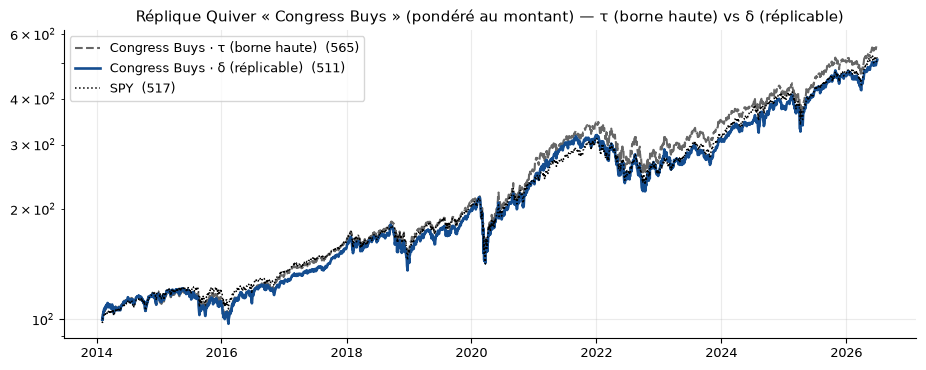

In [115]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(buys_t.index, buys_t, color=GRIS, lw=1.5, ls="--", label=f"Congress Buys · τ (borne haute)  ({buys_t.iloc[-1]:.0f})")
ax.plot(buys_d.index, buys_d, color=BLEU, lw=1.9,          label=f"Congress Buys · δ (réplicable)  ({buys_d.iloc[-1]:.0f})")
ax.plot(spyq.index,   spyq,   color="k",  lw=1.1, ls=":",  label=f"SPY  ({spyq.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique Quiver « Congress Buys » (pondéré au montant) — τ (borne haute) vs δ (réplicable)")
plt.savefig(f"{FIGS}/quiver.png", dpi=150, bbox_inches="tight"); plt.show()

### §14.1 — Leur page annonce +604 % / CAGR 36,2 % : est-ce une erreur chez nous ?

On teste, un par un, tous les leviers qui pourraient nous faire **sous-estimer** ; puis on regarde si
**leurs propres chiffres** (β, Sharpe) sont cohérents avec leur titre 36 %.

In [116]:
# levier 1 — la pondération. Quiver dit « pondéré à la taille du trade ($) ». On teste le VRAI 1/N (équipondéré).
buys_eq = run_livre({i: poids_taille(i, I0, ordre, "buy", mode="equal") for i in coupes[:-1]}, np.inf)[0]
print("Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :")
for nm, s in [("$-pondéré (ce qu'ON fait)", buys_t), ("équipondéré 1/N (contrôle)", buys_eq)]:
    print(f"  {nm:28s} CAGR 2020-26 {100*cagr(s, d20):5.1f} % · NAV {s.iloc[-1]:.0f} · β {bilan(s,'x')['β']:.2f}")
ceq, cdl = 100*cagr(buys_eq, d20), 100*cagr(buys_t, d20)
sens = "ne change pas l'ordre de grandeur" if abs(ceq-cdl) < 3 else ("fait un peu mieux" if ceq > cdl else "fait moins bien")
print(f"  => l'équipondération {sens} (équi {ceq:.1f} % vs $-pond {cdl:.1f} %) : les deux ≈ marché, aucune ne s'approche de 36 %.")

Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :
  $-pondéré (ce qu'ON fait)    CAGR 2020-26  22.6 % · NAV 565 · β 1.06
  équipondéré 1/N (contrôle)   CAGR 2020-26  19.5 % · NAV 412 · β 1.01
  => l'équipondération fait moins bien (équi 19.5 % vs $-pond 22.6 %) : les deux ≈ marché, aucune ne s'approche de 36 %.


In [117]:
# levier 2 — les ETF qu'on écarte (asset_class != stock). Combien de $ ? lesquels ?
etf = df0[df0.direction == "buy"].copy()
etf["tau"] = etf.transaction_date
etf = etf[etf.tau >= d20]
part_etf = etf[etf.asset_class.str.startswith("etf")].amount_midpoint.sum() / etf.amount_midpoint.sum()
top_etf = (etf[etf.asset_class.str.startswith("etf")].groupby("ticker_yahoo").amount_midpoint.sum()
             .sort_values(ascending=False).head(6))
print(f"ETF écartés depuis 2020 : {part_etf:.1%} du $ acheté.  Top-6 : " + ", ".join(top_etf.index))
print("  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.")

ETF écartés depuis 2020 : 2.5% du $ acheté.  Top-6 : VTI, SPY, VIG, IWD, BITB, IWN
  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.


In [118]:
# levier 3 — les 296 titres non cotés (6,5 % du $). Borne HAUTE : et s'ils avaient tous DOUBLÉ ?
part_manque = ach.A[~have].sum() / ach.A.sum()            # ach/have viennent de la cellule couverture ci-dessus
boost = (1 - part_manque) * 1.0 + part_manque * 2.0        # 93,5 % au rendement réel + 6,5 % ×2 (hypothèse absurde)
print(f"$ non couvert (fusions/radiations) : {part_manque:.1%}.")
print(f"Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×{boost:.3f} (≈ +{100*(boost-1):.1f} %).")
print("  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.")

$ non couvert (fusions/radiations) : 6.5%.
Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×1.065 (≈ +6.5 %).
  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.


In [119]:
# leurs propres chiffres sont-ils cohérents entre eux ? (β 1,14 · Sharpe 1,082 · vol affichée 4,63 %)
beta_q, sharpe_q, rf, rm = 1.14, 1.082, 3.0, 100*cagr(spyq, d20)   # rm = notre marché depuis 2020
capm = rf + beta_q * (rm - rf)                                     # rendement CAPM SANS alpha
vol_syst = beta_q * 17.0                                           # vol systématique (marché ~17 %/an) : la vol TOTALE est >= ça
print(f"Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β {beta_q}  ·  Sharpe {sharpe_q}  ·  vol affichée 4,63 %\n")
print(f"  • CAPM(β {beta_q}, marché {rm:.0f} %) SANS alpha => {capm:.0f} %/an. Atteindre 36 % exigerait α ≈ +{36-capm:.0f} %/an,")
print(f"    or notre réplique fidèle trouve α ≈ 0 (bilan §14).")
print(f"  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β {beta_q} : une position β {beta_q} a une vol >= {vol_syst:.0f} %/an")
print(f"    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).")
print(f"  • honnêteté : leur Sharpe {sharpe_q} n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)")
print(f"    — on ne s'en sert donc PAS comme preuve.")
print(f"  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.")

Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β 1.14  ·  Sharpe 1.082  ·  vol affichée 4,63 %

  • CAPM(β 1.14, marché 21 %) SANS alpha => 24 %/an. Atteindre 36 % exigerait α ≈ +12 %/an,
    or notre réplique fidèle trouve α ≈ 0 (bilan §14).
  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β 1.14 : une position β 1.14 a une vol >= 19 %/an
    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).
  • honnêteté : leur Sharpe 1.082 n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)
    — on ne s'en sert donc PAS comme preuve.
  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.


### §14.2 — Rebalancement hebdomadaire (le seul paramètre de fréquence que Quiver divulgue)

On faisait du **mensuel** ; leur page dit **hebdo**. On rebranche le moteur sur des coupes du vendredi
(`run_livre(·, cuts=coupes_h)`) — même fenêtre 63 j, même pondération. Si le CAGR ne bouge pas, on **matche
tout ce qu'ils divulguent** et l'écart au 36 % est entièrement dans leur boîte noire non divulguée.

In [120]:
coupes_h = sorted(set(cal.searchsorted(d, "right") - 1
                      for d in pd.date_range(cal[coupes[0]], cal[coupes[-1]], freq="W-FRI")))
coupes_h = [i for i in coupes_h if W <= i < len(cal) - 1]
print(f"{len(coupes_h)} coupes hebdomadaires (vs {len(coupes)} mensuelles) · "
      f"{cal[coupes_h[0]].date()} → {cal[coupes_h[-1]].date()}")

def book_h(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes_h[:-1]}, np.inf, cuts=coupes_h)[0]

buys_ht, buys_hd = book_h(I0, ordre, "buy"),  book_h(I_de, ordre_d, "buy")     # Congress Buys hebdo, τ et δ
sell_ht, sell_hd = book_h(I0, ordre, "sell"), book_h(I_de, ordre_d, "sell")
ls_ht,   ls_hd   = longshort(buys_ht, sell_ht), longshort(buys_hd, sell_hd)    # Long-Short hebdo, τ et δ
print("réplique Quiver hebdomadaire construite")

648 coupes hebdomadaires (vs 150 mensuelles) · 2014-01-31 → 2026-06-26


réplique Quiver hebdomadaire construite


In [121]:
def rowh(span, nom):
    return {"stratégie": nom, "CAGR 2020-26 %": 100*cagr(span, d20),
            "β": round(bilan(span, "x")["β"], 2), "NAV": round(span.iloc[-1])}
print("Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :\n")
pd.DataFrame([rowh(buys_t,  "Congress Buys · τ · mensuel"),
             rowh(buys_ht,  "Congress Buys · τ · HEBDO"),
             rowh(buys_d,   "Congress Buys · δ · mensuel"),
             rowh(buys_hd,  "Congress Buys · δ · HEBDO"),
             rowh(ls_t,     "Long-Short · τ · mensuel"),
             rowh(ls_ht,    "Long-Short · τ · HEBDO")]).set_index("stratégie").round(1)

Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :



,CAGR 2020-26 %,β,NAV
stratégie,,,
Congress Buys · τ · mensuel,22.6,1.1,565
Congress Buys · τ · HEBDO,22.3,1.1,573
Congress Buys · δ · mensuel,21.4,1.0,511
Congress Buys · δ · HEBDO,22.0,1.0,518
Long-Short · τ · mensuel,23.5,1.1,606
Long-Short · τ · HEBDO,23.5,1.1,618


In [122]:
# auto-contrôles : livres pleinement investis (Σw=1 à chaque coupe) + ancres inchangées (non-régression)
def sigma_max(WP): return max(abs(sum(w.values()) - 1) for w in WP.values() if w)
WPb = {i: poids_taille(i, I0, ordre, "buy") for i in coupes[:-1]}
print("Σw−1 max par coupe (doit être ≈ 0) : "
      f"NANC {sigma_max(WP_nanc):.1e} · GOP {sigma_max(WP_gop):.1e} · Quiver Buys {sigma_max(WPb):.1e}")
print("ancres inchangées : "
      f"NANC {span_nanc.iloc[-1]:.0f} (att. 672) · GOP {span_gop.iloc[-1]:.0f} (att. 612) · "
      f"Buys τ {buys_t.iloc[-1]:.0f} (565) · base δ {spanD.iloc[-1]:.0f} (530)")

Σw−1 max par coupe (doit être ≈ 0) : NANC 4.4e-16 · GOP 2.2e-16 · Quiver Buys 0.0e+00
ancres inchangées : NANC 672 (att. 672) · GOP 612 (att. 612) · Buys τ 565 (565) · base δ 530 (530)


## §15 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Rappel des limites assumées** :
- la sélection utilise la **date de transaction** → l'information n'était pas publique → **borne haute**, pas une stratégie réplicable
- **aucun coût** de transaction ; le turnover mensuel n'est pas facturé
- pas de plafond de poids, pas de filtre de liquidité *(l'ADV n'est que rapportée, §9)*